# TechMind v2.0 — Entrenamiento y comparación de modelos

## Notebook 03

Este notebook desarrolla la etapa de modelado supervisado del sistema TechMind
v2.0, cuyo objetivo es clasificar contenido tecnológico en cuatro categorías:

- Backend
- Cloud
- Data Science
- Frontend

El dataset utilizado fue preparado en el Notebook 02 mediante un proceso
reproducible de limpieza, normalización, resolución de etiquetas
contradictorias, eliminación de duplicados e ingeniería de características.

## Objetivos

- Cargar y validar el dataset procesado.
- Separar los datos en entrenamiento y prueba de forma estratificada.
- Definir una estrategia reproducible de validación cruzada.
- Construir un modelo baseline.
- Comparar diferentes representaciones textuales.
- Evaluar distintos algoritmos de clasificación.
- Optimizar los modelos con mejor rendimiento.
- Comparar modelos basados únicamente en texto con modelos híbridos.
- Seleccionar el mejor modelo utilizando F1-Score Macro.
- Preparar los resultados para la evaluación final y exportación.

## Estrategia de evaluación

La métrica principal será F1-Score Macro, ya que calcula el F1-Score de cada
clase de manera independiente y después obtiene su promedio, asignando la misma
importancia a Backend, Cloud, Data Science y Frontend.

También se analizarán:

- Accuracy
- Precision Macro
- Recall Macro
- F1-Score Weighted
- Tiempo de entrenamiento
- Estabilidad durante la validación cruzada

El conjunto de prueba permanecerá separado durante la comparación y
optimización de modelos. Se utilizará una sola vez para evaluar el modelo final
seleccionado.

In [9]:
# ==============================================================================
# CELDA 2
# IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================

import json
import platform
import time
import warnings

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display

# ------------------------------------------------------------------------------
# Preparación de datos y validación
# ------------------------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import MaxAbsScaler, StandardScaler

# ------------------------------------------------------------------------------
# Representación textual
# ------------------------------------------------------------------------------

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

# ------------------------------------------------------------------------------
# Modelos
# ------------------------------------------------------------------------------

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# ------------------------------------------------------------------------------
# Métricas
# ------------------------------------------------------------------------------

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [10]:
# ==============================================================================
# CELDA 3
# CONFIGURACIÓN GENERAL Y REPRODUCIBILIDAD
# ===============================================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS_CV = 5
N_JOBS = 1

# ------------------------------------------------------------------------------
# Configuración visual
# ------------------------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.float_format", lambda valor: f"{valor:,.4f}")

# ------------------------------------------------------------------------------
# Rutas
# ------------------------------------------------------------------------------

PROJECT_ROOT = Path("..")

DATA_PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
)

MODELS_DIR = (
    PROJECT_ROOT
    / "models"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DATA_PATH = (
    DATA_PROCESSED_DIR
    / "techmind_modelado.csv"
)

CONFIG_PATH = (
    REPORTS_DIR
    / "configuracion_features.json"
)

# ------------------------------------------------------------------------------
# Variable objetivo y variantes textuales
# ------------------------------------------------------------------------------

COLUMNA_OBJETIVO = "categoria"

VARIANTES_TEXTO_ESPERADAS = [
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

print("=" * 80)
print("CONFIGURACIÓN DEL NOTEBOOK 03")
print("=" * 80)

print(f"Semilla aleatoria:       {RANDOM_STATE}")
print(f"Proporción de prueba:    {TEST_SIZE:.0%}")
print(f"Divisiones de CV:        {N_SPLITS_CV}")
print(f"Procesadores utilizados: {N_JOBS}")
print(f"Dataset:                  {DATA_PATH.resolve()}")

CONFIGURACIÓN DEL NOTEBOOK 03
Semilla aleatoria:       42
Proporción de prueba:    20%
Divisiones de CV:        5
Procesadores utilizados: 1
Dataset:                  C:\Users\MAMÁ\Downloads\data\processed\techmind_modelado.csv


In [11]:
# ==============================================================================
# CELDA 4
# INFORMACIÓN DEL ENTORNO
# ==============================================================================

informacion_entorno = pd.DataFrame({
    "Componente": [
        "Python",
        "Pandas",
        "NumPy",
        "Scikit-learn",
        "Joblib",
        "Sistema operativo"
    ],
    "Version": [
        platform.python_version(),
        pd.__version__,
        np.__version__,
        sklearn.__version__,
        joblib.__version__,
        platform.platform()
    ]
})

display(informacion_entorno)

,Componente,Version
0,Python,3.11.9
1,Pandas,3.0.3
2,NumPy,1.26.4
3,Scikit-learn,1.9.0
4,Joblib,1.5.3
5,Sistema operativo,Windows-10-10.0.26200-SP0


In [12]:
# ==============================================================================
# CELDA 5
# CARGA DEL DATASET PROCESADO
# ==============================================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset procesado en:\n"
        f"{DATA_PATH.resolve()}\n\n"
        "Ejecuta primero la exportación del Notebook 02."
    )

try:
    df_modelos = pd.read_csv(
        DATA_PATH,
        encoding="utf-8-sig"
    )

except UnicodeDecodeError:
    df_modelos = pd.read_csv(
        DATA_PATH,
        encoding="utf-8"
    )

except pd.errors.EmptyDataError as error:
    raise ValueError(
        "El archivo techmind_modelado.csv se encuentra vacío."
    ) from error

except pd.errors.ParserError as error:
    raise ValueError(
        "No fue posible interpretar correctamente el archivo CSV."
    ) from error


print("=" * 80)
print("DATASET CARGADO CORRECTAMENTE")
print("=" * 80)

print(f"Filas:    {df_modelos.shape[0]:,}")
print(f"Columnas: {df_modelos.shape[1]:,}")

print("\nPrimeros registros:")

display(df_modelos.head())

DATASET CARGADO CORRECTAMENTE
Filas:    4,583
Columnas: 25

Primeros registros:


,id_documento,categoria,texto_modelo_base,texto_modelo_titulo,texto_combinado,texto_combinado_ponderado,titulo_num_caracteres,titulo_num_palabras,texto_num_caracteres,texto_num_palabras,combinado_num_caracteres,combinado_num_palabras,num_palabras_clave,longitud_promedio_palabra,proporcion_digitos,cantidad_versiones,cantidad_terminos_tecnicos,densidad_terminos_tecnicos,cantidad_urls,cantidad_simbolos_codigo,tiene_palabras_clave,tiene_version,tiene_url,tiene_codigo,tiene_terminos_tecnicos
0,1,frontend,geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,geeknews frontend weekly deep dive-2026-07-06 geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑,geeknews frontend weekly deep dive-2026-07-06 geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑 geeknews,geeknews frontend weekly deep dive-2026-07-06 geeknews frontend weekly deep dive-2026-07-06 geeknews 프론트엔드 이슈를 바탕으로 작성한 주간 브리핑 geeknews geeknews,45,5,34,1,89,7,1,8.1400,0.0899,0,1,0.1429,0,0,1,0,0,0,1
1,2,cloud,aws claude apps gateway gcp workbench vs code ai agent benchmarks today s.,aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude apps gateway gcp workbench vs code ai agent benchmarks today s.,aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude apps gateway gcp workbench vs code ai agent benchmarks today s. workb...,aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude apps gateway gcp workbench vs code ai agent benchmarks aws claude app...,65,11,74,13,203,35,4,4.8000,0.0000,0,3,0.0857,0,1,1,0,0,1,1
2,3,cloud,without rbac properly configured: a developer can accidentally delete production pods a compromised.,kubernetes rbac control who can do what in your cluster without rbac properly configured: a developer can accidentally delete production pods a co...,kubernetes rbac control who can do what in your cluster without rbac properly configured: a developer can accidentally delete production pods a co...,kubernetes rbac control who can do what in your cluster kubernetes rbac control who can do what in your cluster without rbac properly configured: ...,55,10,100,13,156,23,0,5.7400,0.0000,0,1,0.0435,0,0,0,0,0,0,1
3,4,backend,i spent this week actually benchmarking postgresql queries on a 500 000-row table instead of just.,1 820x faster: what i learned optimizing 500 000 postgresql rows i spent this week actually benchmarking postgresql queries on a 500 000-row table...,1 820x faster: what i learned optimizing 500 000 postgresql rows i spent this week actually benchmarking postgresql queries on a 500 000-row table...,1 820x faster: what i learned optimizing 500 000 postgresql rows 1 820x faster: what i learned optimizing 500 000 postgresql rows i spent this wee...,64,11,98,16,185,31,2,4.9400,0.1189,0,2,0.0645,0,0,1,0,0,0,1
4,5,backend,the challenge building scheduling systems that handle multiple users isn t trivial. you.,building multi-user scheduling systems: a technical guide the challenge building scheduling systems that handle multiple users isn t trivial. you.,building multi-user scheduling systems: a technical guide the challenge building scheduling systems that handle multiple users isn t trivial. you.,building multi-user scheduling systems: a technical guide building multi-user scheduling systems: a technical guide the challenge building schedul...,57,7,88,13,146,20,0,6.2000,0.0000,0,0,0.0000,0,0,0,0,0,0,0


In [13]:
# ==============================================================================
# CELDA 6
# CARGA DE LA CONFIGURACIÓN DEL NOTEBOOK 02
# ==============================================================================

if CONFIG_PATH.exists():

    with open(
        CONFIG_PATH,
        "r",
        encoding="utf-8"
    ) as archivo:
        configuracion = json.load(archivo)

    COLUMNA_OBJETIVO = configuracion.get(
        "variable_objetivo",
        "categoria"
    )

    COLUMNA_TEXTO_PRINCIPAL = configuracion.get(
        "variable_textual_principal",
        "texto_combinado"
    )

    COLUMNAS_VARIANTES_MODELO = configuracion.get(
        "variantes_textuales",
        VARIANTES_TEXTO_ESPERADAS
    )

    COLUMNAS_FEATURES_MODELO = configuracion.get(
        "caracteristicas_numericas",
        []
    )

    print(
        "Configuración del Notebook 02 cargada correctamente."
    )

else:

    print(
        "ADVERTENCIA: no se encontró configuracion_features.json. "
        "Se utilizará la configuración predeterminada."
    )

    COLUMNA_TEXTO_PRINCIPAL = "texto_combinado"

    COLUMNAS_VARIANTES_MODELO = (
        VARIANTES_TEXTO_ESPERADAS.copy()
    )

    COLUMNAS_FEATURES_MODELO = [
        "titulo_num_caracteres",
        "titulo_num_palabras",
        "texto_num_caracteres",
        "texto_num_palabras",
        "combinado_num_caracteres",
        "combinado_num_palabras",
        "num_palabras_clave",
        "longitud_promedio_palabra",
        "proporcion_digitos",
        "cantidad_versiones",
        "cantidad_terminos_tecnicos",
        "densidad_terminos_tecnicos",
        "cantidad_urls",
        "cantidad_simbolos_codigo",
        "tiene_palabras_clave",
        "tiene_version",
        "tiene_url",
        "tiene_codigo",
        "tiene_terminos_tecnicos"
    ]


print("\nConfiguración recuperada:")

print(
    f"Variable objetivo: "
    f"{COLUMNA_OBJETIVO}"
)

print(
    f"Variable textual principal: "
    f"{COLUMNA_TEXTO_PRINCIPAL}"
)

print(
    f"Variantes textuales: "
    f"{len(COLUMNAS_VARIANTES_MODELO)}"
)

print(
    f"Características numéricas: "
    f"{len(COLUMNAS_FEATURES_MODELO)}"
)

Configuración del Notebook 02 cargada correctamente.

Configuración recuperada:
Variable objetivo: categoria
Variable textual principal: texto_combinado
Variantes textuales: 4
Características numéricas: 19


In [14]:
# ==============================================================================
# CELDA 7
# VALIDACIÓN INICIAL DEL DATASET PARA MODELADO
# ==============================================================================

print("=" * 80)
print("VALIDACIÓN DEL DATASET PARA MODELADO")
print("=" * 80)

COLUMNAS_REQUERIDAS_MODELO = (
    [COLUMNA_OBJETIVO]
    + COLUMNAS_VARIANTES_MODELO
    + COLUMNAS_FEATURES_MODELO
)

columnas_faltantes = [
    columna
    for columna in COLUMNAS_REQUERIDAS_MODELO
    if columna not in df_modelos.columns
]

if columnas_faltantes:
    raise ValueError(
        "El dataset no contiene todas las columnas necesarias.\n"
        f"Columnas faltantes: {columnas_faltantes}"
    )

print(
    "Todas las columnas requeridas están presentes."
)

VALIDACIÓN DEL DATASET PARA MODELADO
Todas las columnas requeridas están presentes.


In [15]:
# ==============================================================================
# CELDA 8
# VALIDACIÓN DE CLASES
# ==============================================================================

categorias_esperadas = {
    "backend",
    "cloud",
    "datascience",
    "frontend"
}

categorias_encontradas = set(
    df_modelos[COLUMNA_OBJETIVO]
    .dropna()
    .unique()
)

categorias_desconocidas = (
    categorias_encontradas
    - categorias_esperadas
)

categorias_ausentes = (
    categorias_esperadas
    - categorias_encontradas
)

nulos_objetivo = int(
    df_modelos[COLUMNA_OBJETIVO]
    .isna()
    .sum()
)

print(
    f"Categorías encontradas: "
    f"{sorted(categorias_encontradas)}"
)

print(
    f"Valores nulos en objetivo: "
    f"{nulos_objetivo:,}"
)

if categorias_desconocidas:
    raise ValueError(
        f"Se encontraron categorías desconocidas: "
        f"{sorted(categorias_desconocidas)}"
    )

if categorias_ausentes:
    raise ValueError(
        f"Faltan categorías esperadas: "
        f"{sorted(categorias_ausentes)}"
    )

if nulos_objetivo > 0:
    raise ValueError(
        "La variable objetivo contiene valores nulos."
    )

Categorías encontradas: ['backend', 'cloud', 'datascience', 'frontend']
Valores nulos en objetivo: 0


In [16]:
# ==============================================================================
# CELDA 9
# VALIDACIÓN DE VARIANTES TEXTUALES
# ==============================================================================

resumen_textos_modelo = []

for columna in COLUMNAS_VARIANTES_MODELO:

    serie = (
        df_modelos[columna]
        .fillna("")
        .astype(str)
    )

    cantidad_vacios = int(
        serie.str.strip()
        .eq("")
        .sum()
    )

    resumen_textos_modelo.append({
        "Variable": columna,
        "Documentos_vacios": cantidad_vacios,
        "Textos_unicos": serie.nunique(),
        "Longitud_promedio": round(
            serie.str.len().mean(),
            2
        )
    })

df_resumen_textos_modelo = pd.DataFrame(
    resumen_textos_modelo
)

display(df_resumen_textos_modelo)

variantes_con_vacios = df_resumen_textos_modelo[
    df_resumen_textos_modelo["Documentos_vacios"] > 0
]

if not variantes_con_vacios.empty:

    print(
        "ADVERTENCIA: alguna variante contiene documentos vacíos."
    )

    display(variantes_con_vacios)

else:

    print(
        "Todas las variantes textuales contienen información."
    )

,Variable,Documentos_vacios,Textos_unicos,Longitud_promedio
0,texto_modelo_base,0,4525,98.5400
1,texto_modelo_titulo,0,4583,163.4800
2,texto_combinado,0,4583,174.9600
3,texto_combinado_ponderado,0,4583,251.3700


Todas las variantes textuales contienen información.


In [17]:
# ==============================================================================
# CELDA 10
# VALIDACIÓN DE CARACTERÍSTICAS NUMÉRICAS
# ==============================================================================

resumen_features_modelo = []

for columna in COLUMNAS_FEATURES_MODELO:

    serie = pd.to_numeric(
        df_modelos[columna],
        errors="coerce"
    )

    resumen_features_modelo.append({
        "Variable": columna,
        "Es_numerica": pd.api.types.is_numeric_dtype(
            df_modelos[columna]
        ),
        "Nulos": int(serie.isna().sum()),
        "Infinitos": int(np.isinf(serie).sum()),
        "Valores_unicos": int(serie.nunique())
    })

df_resumen_features_modelo = pd.DataFrame(
    resumen_features_modelo
)

display(df_resumen_features_modelo)

problemas_features = df_resumen_features_modelo[
    (~df_resumen_features_modelo["Es_numerica"])
    |
    (df_resumen_features_modelo["Nulos"] > 0)
    |
    (df_resumen_features_modelo["Infinitos"] > 0)
]

if not problemas_features.empty:
    raise ValueError(
        "Se detectaron problemas en las características numéricas."
    )

print(
    "Todas las características numéricas son válidas."
)

,Variable,Es_numerica,Nulos,Infinitos,Valores_unicos
0,titulo_num_caracteres,True,0,0,138
1,titulo_num_palabras,True,0,0,29
2,texto_num_caracteres,True,0,0,203
3,texto_num_palabras,True,0,0,52
4,combinado_num_caracteres,True,0,0,264
5,combinado_num_palabras,True,0,0,67
6,num_palabras_clave,True,0,0,8
7,longitud_promedio_palabra,True,0,0,450
8,proporcion_digitos,True,0,0,568
9,cantidad_versiones,True,0,0,7


Todas las características numéricas son válidas.


In [18]:
# ==============================================================================
# CELDA 11
# DUPLICADOS Y ETIQUETAS CONTRADICTORIAS
# ==============================================================================

duplicados_textuales = int(
    df_modelos.duplicated(
        subset=[
            COLUMNA_TEXTO_PRINCIPAL,
            COLUMNA_OBJETIVO
        ],
        keep=False
    ).sum()
)

conflictos_categoria = int(
    df_modelos
    .groupby(COLUMNA_TEXTO_PRINCIPAL)[COLUMNA_OBJETIVO]
    .nunique()
    .gt(1)
    .sum()
)

print(
    f"Registros en grupos duplicados: "
    f"{duplicados_textuales:,}"
)

print(
    f"Textos con etiquetas contradictorias: "
    f"{conflictos_categoria:,}"
)

if duplicados_textuales > 0:
    raise ValueError(
        "El dataset contiene duplicados textuales residuales."
    )

if conflictos_categoria > 0:
    raise ValueError(
        "El dataset contiene etiquetas contradictorias."
    )

Registros en grupos duplicados: 0
Textos con etiquetas contradictorias: 0


In [19]:
# ==============================================================================
# CELDA 12
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==============================================================================

distribucion_modelado = (
    df_modelos[COLUMNA_OBJETIVO]
    .value_counts()
    .sort_index()
    .rename_axis("Categoria")
    .reset_index(name="Cantidad")
)

distribucion_modelado["Porcentaje"] = (
    distribucion_modelado["Cantidad"]
    .div(len(df_modelos))
    .mul(100)
    .round(2)
)

display(distribucion_modelado)

clase_mayoritaria = int(
    distribucion_modelado["Cantidad"].max()
)

clase_minoritaria = int(
    distribucion_modelado["Cantidad"].min()
)

ratio_balance_modelado = (
    clase_minoritaria / clase_mayoritaria
)

print(
    f"Ratio de balance: "
    f"{ratio_balance_modelado:.3f}"
)

,Categoria,Cantidad,Porcentaje
0,backend,1159,25.2900
1,cloud,1157,25.2500
2,datascience,1102,24.0500
3,frontend,1165,25.4200


Ratio de balance: 0.946


In [20]:
# ==============================================================================
# CELDA 13
# CONCLUSIÓN DE LA VALIDACIÓN INICIAL
# ==============================================================================

documentos_vacios_principal = int(
    df_modelos[COLUMNA_TEXTO_PRINCIPAL]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("=" * 80)
print("CONCLUSIÓN DE LA VALIDACIÓN INICIAL")
print("=" * 80)

print(
    f"Registros disponibles: "
    f"{len(df_modelos):,}"
)

print(
    f"Clases disponibles: "
    f"{df_modelos[COLUMNA_OBJETIVO].nunique()}"
)

print(
    f"Características numéricas: "
    f"{len(COLUMNAS_FEATURES_MODELO)}"
)

print(
    f"Documentos vacíos en la entrada principal: "
    f"{documentos_vacios_principal}"
)

print(
    f"Ratio de balance: "
    f"{ratio_balance_modelado:.3f}"
)

if (
    documentos_vacios_principal == 0
    and duplicados_textuales == 0
    and conflictos_categoria == 0
    and ratio_balance_modelado >= 0.80
):

    print("""
El dataset procesado fue cargado y validado correctamente. Las variantes
textuales, la variable objetivo y las características numéricas presentan una
estructura válida para iniciar el entrenamiento.

El conjunto de datos puede avanzar a la división estratificada de entrenamiento
y prueba.
""")

else:

    print("""
El dataset contiene condiciones que deben revisarse antes de iniciar el
entrenamiento.
""")

CONCLUSIÓN DE LA VALIDACIÓN INICIAL
Registros disponibles: 4,583
Clases disponibles: 4
Características numéricas: 19
Documentos vacíos en la entrada principal: 0
Ratio de balance: 0.946

El dataset procesado fue cargado y validado correctamente. Las variantes
textuales, la variable objetivo y las características numéricas presentan una
estructura válida para iniciar el entrenamiento.

El conjunto de datos puede avanzar a la división estratificada de entrenamiento
y prueba.



In [21]:
# ==============================================================================
# CELDA 14
# DIVISIÓN ESTRATIFICADA EN ENTRENAMIENTO Y PRUEBA
# ==============================================================================

# Usamos únicamente los índices para dividir todo el dataset de forma consistente
indices = np.arange(
    len(df_modelos)
)

variable_objetivo = (
    df_modelos[COLUMNA_OBJETIVO]
    .astype(str)
    .copy()
)

indices_train, indices_test = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=variable_objetivo
)

print("=" * 80)
print("DIVISIÓN ESTRATIFICADA")
print("=" * 80)

print(
    f"Registros totales:       "
    f"{len(df_modelos):,}"
)

print(
    f"Registros entrenamiento: "
    f"{len(indices_train):,}"
)

print(
    f"Registros prueba:        "
    f"{len(indices_test):,}"
)

print(
    f"Proporción entrenamiento: "
    f"{len(indices_train) / len(df_modelos):.2%}"
)

print(
    f"Proporción prueba:        "
    f"{len(indices_test) / len(df_modelos):.2%}"
)

DIVISIÓN ESTRATIFICADA
Registros totales:       4,583
Registros entrenamiento: 3,666
Registros prueba:        917
Proporción entrenamiento: 79.99%
Proporción prueba:        20.01%


In [22]:
# ==============================================================================
# CELDA 15
# CREACIÓN DE DATASETS DE ENTRENAMIENTO Y PRUEBA
# ==============================================================================

df_train = (
    df_modelos
    .iloc[indices_train]
    .copy()
    .reset_index(drop=True)
)

df_test = (
    df_modelos
    .iloc[indices_test]
    .copy()
    .reset_index(drop=True)
)

y_train = (
    df_train[COLUMNA_OBJETIVO]
    .copy()
)

y_test = (
    df_test[COLUMNA_OBJETIVO]
    .copy()
)

print(
    f"df_train: "
    f"{df_train.shape[0]:,} filas × "
    f"{df_train.shape[1]:,} columnas"
)

print(
    f"df_test:  "
    f"{df_test.shape[0]:,} filas × "
    f"{df_test.shape[1]:,} columnas"
)

df_train: 3,666 filas × 25 columnas
df_test:  917 filas × 25 columnas


In [23]:
# ==============================================================================
# CELDA 16
# ENTRADAS TEXTUALES PRINCIPALES
# ==============================================================================

X_train_texto = (
    df_train[COLUMNA_TEXTO_PRINCIPAL]
    .fillna("")
    .astype(str)
    .copy()
)

X_test_texto = (
    df_test[COLUMNA_TEXTO_PRINCIPAL]
    .fillna("")
    .astype(str)
    .copy()
)

print(
    f"Entrada textual de entrenamiento: "
    f"{X_train_texto.shape}"
)

print(
    f"Entrada textual de prueba: "
    f"{X_test_texto.shape}"
)

print(
    f"Textos vacíos en entrenamiento: "
    f"{X_train_texto.str.strip().eq('').sum():,}"
)

print(
    f"Textos vacíos en prueba: "
    f"{X_test_texto.str.strip().eq('').sum():,}"
)

Entrada textual de entrenamiento: (3666,)
Entrada textual de prueba: (917,)
Textos vacíos en entrenamiento: 0
Textos vacíos en prueba: 0


In [24]:
# ==============================================================================
# CELDA 17
# CARACTERÍSTICAS NUMÉRICAS
# ==============================================================================

X_train_numerico = (
    df_train[COLUMNAS_FEATURES_MODELO]
    .copy()
)

X_test_numerico = (
    df_test[COLUMNAS_FEATURES_MODELO]
    .copy()
)

print(
    f"Características numéricas de entrenamiento: "
    f"{X_train_numerico.shape}"
)

print(
    f"Características numéricas de prueba: "
    f"{X_test_numerico.shape}"
)

print(
    f"Valores nulos en entrenamiento: "
    f"{X_train_numerico.isna().sum().sum():,}"
)

print(
    f"Valores nulos en prueba: "
    f"{X_test_numerico.isna().sum().sum():,}"
)

Características numéricas de entrenamiento: (3666, 19)
Características numéricas de prueba: (917, 19)
Valores nulos en entrenamiento: 0
Valores nulos en prueba: 0


In [25]:
# ==============================================================================
# CELDA 18
# COMPARACIÓN DE LA DISTRIBUCIÓN DE CLASES
# ==============================================================================

def calcular_distribucion_clases(serie, conjunto):
    """
    Calcula la cantidad y proporción de cada clase.
    """

    distribucion = (
        serie
        .value_counts()
        .sort_index()
        .rename_axis("Categoria")
        .reset_index(name="Cantidad")
    )

    distribucion["Proporcion"] = (
        distribucion["Cantidad"]
        .div(len(serie))
    )

    distribucion["Porcentaje"] = (
        distribucion["Proporcion"]
        .mul(100)
        .round(2)
    )

    distribucion["Conjunto"] = conjunto

    return distribucion


distribucion_total = calcular_distribucion_clases(
    df_modelos[COLUMNA_OBJETIVO],
    "Total"
)

distribucion_train = calcular_distribucion_clases(
    y_train,
    "Entrenamiento"
)

distribucion_test = calcular_distribucion_clases(
    y_test,
    "Prueba"
)

df_distribucion_division = pd.concat(
    [
        distribucion_total,
        distribucion_train,
        distribucion_test
    ],
    ignore_index=True
)

display(
    df_distribucion_division[
        [
            "Conjunto",
            "Categoria",
            "Cantidad",
            "Porcentaje"
        ]
    ]
)

,Conjunto,Categoria,Cantidad,Porcentaje
0,Total,backend,1159,25.2900
1,Total,cloud,1157,25.2500
2,Total,datascience,1102,24.0500
3,Total,frontend,1165,25.4200
4,Entrenamiento,backend,927,25.2900
5,Entrenamiento,cloud,925,25.2300
6,Entrenamiento,datascience,882,24.0600
7,Entrenamiento,frontend,932,25.4200
8,Prueba,backend,232,25.3000
9,Prueba,cloud,232,25.3000


In [26]:
# ==============================================================================
# CELDA 19
# DIFERENCIAS DE PROPORCIÓN ENTRE CONJUNTOS
# ==============================================================================

tabla_proporciones = (
    df_distribucion_division
    .pivot(
        index="Categoria",
        columns="Conjunto",
        values="Porcentaje"
    )
    .reset_index()
)

tabla_proporciones["Diferencia_train_total"] = (
    tabla_proporciones["Entrenamiento"]
    - tabla_proporciones["Total"]
).abs()

tabla_proporciones["Diferencia_test_total"] = (
    tabla_proporciones["Prueba"]
    - tabla_proporciones["Total"]
).abs()

display(tabla_proporciones)

max_diferencia_train = (
    tabla_proporciones["Diferencia_train_total"]
    .max()
)

max_diferencia_test = (
    tabla_proporciones["Diferencia_test_total"]
    .max()
)

print(
    f"Máxima diferencia entrenamiento-total: "
    f"{max_diferencia_train:.2f} puntos porcentuales"
)

print(
    f"Máxima diferencia prueba-total: "
    f"{max_diferencia_test:.2f} puntos porcentuales"
)

Conjunto,Categoria,Entrenamiento,Prueba,Total,Diferencia_train_total,Diferencia_test_total
0,backend,25.2900,25.3000,25.2900,0.0000,0.0100
1,cloud,25.2300,25.3000,25.2500,0.0200,0.0500
2,datascience,24.0600,23.9900,24.0500,0.0100,0.0600
3,frontend,25.4200,25.4100,25.4200,0.0000,0.0100


Máxima diferencia entrenamiento-total: 0.02 puntos porcentuales
Máxima diferencia prueba-total: 0.06 puntos porcentuales


In [27]:
# ==============================================================================
# CELDA 20
# VALIDACIÓN DE INDEPENDENCIA ENTRE CONJUNTOS
# ==============================================================================

solapamiento_indices = set(
    indices_train
).intersection(
    set(indices_test)
)

print(
    f"Índices compartidos entre entrenamiento y prueba: "
    f"{len(solapamiento_indices)}"
)

if solapamiento_indices:
    raise RuntimeError(
        "Se detectó solapamiento entre entrenamiento y prueba."
    )

Índices compartidos entre entrenamiento y prueba: 0


In [28]:
# ==============================================================================
# CELDA 21
# VALIDACIÓN DE IDENTIFICADORES
# ==============================================================================

if "id_documento" in df_modelos.columns:

    ids_train = set(
        df_train["id_documento"]
    )

    ids_test = set(
        df_test["id_documento"]
    )

    ids_compartidos = (
        ids_train
        .intersection(ids_test)
    )

    print(
        f"Identificadores compartidos: "
        f"{len(ids_compartidos)}"
    )

    if ids_compartidos:
        raise RuntimeError(
            "Se detectaron documentos compartidos entre los conjuntos."
        )

else:

    print(
        "El dataset no contiene id_documento. "
        "La independencia fue validada mediante los índices."
    )

Identificadores compartidos: 0


In [29]:
# ==============================================================================
# CELDA 22
# VALIDACIÓN DE CLASES EN AMBOS CONJUNTOS
# ==============================================================================

clases_train = set(
    y_train.unique()
)

clases_test = set(
    y_test.unique()
)

clases_totales = set(
    variable_objetivo.unique()
)

print(
    f"Clases en entrenamiento: "
    f"{sorted(clases_train)}"
)

print(
    f"Clases en prueba: "
    f"{sorted(clases_test)}"
)

if clases_train != clases_totales:
    raise ValueError(
        "El conjunto de entrenamiento no contiene todas las clases."
    )

if clases_test != clases_totales:
    raise ValueError(
        "El conjunto de prueba no contiene todas las clases."
    )

Clases en entrenamiento: ['backend', 'cloud', 'datascience', 'frontend']
Clases en prueba: ['backend', 'cloud', 'datascience', 'frontend']


In [30]:
# ==============================================================================
# CELDA 23
# EXPORTACIÓN DE LA DIVISIÓN
# ==============================================================================

columna_identificador = (
    "id_documento"
    if "id_documento" in df_modelos.columns
    else None
)

if columna_identificador:

    df_asignacion_split = pd.concat(
        [
            df_train[
                [
                    columna_identificador,
                    COLUMNA_OBJETIVO
                ]
            ].assign(
                conjunto="entrenamiento"
            ),

            df_test[
                [
                    columna_identificador,
                    COLUMNA_OBJETIVO
                ]
            ].assign(
                conjunto="prueba"
            )
        ],
        ignore_index=True
    )

else:

    df_asignacion_split = pd.DataFrame({
        "indice_original": np.concatenate(
            [
                indices_train,
                indices_test
            ]
        ),
        "conjunto": (
            ["entrenamiento"] * len(indices_train)
            +
            ["prueba"] * len(indices_test)
        )
    })


PATH_ASIGNACION_SPLIT = (
    RESULTS_DIR
    / "asignacion_train_test.csv"
)

df_asignacion_split.to_csv(
    PATH_ASIGNACION_SPLIT,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Asignación exportada en:\n"
    f"{PATH_ASIGNACION_SPLIT.resolve()}"
)

Asignación exportada en:
C:\Users\MAMÁ\Downloads\results\asignacion_train_test.csv


In [31]:
# ==============================================================================
# CELDA 24
# CONCLUSIÓN DE LA DIVISIÓN
# ==============================================================================

division_aprobada = (
    len(solapamiento_indices) == 0
    and clases_train == clases_totales
    and clases_test == clases_totales
    and X_train_texto.str.strip().ne("").all()
    and X_test_texto.str.strip().ne("").all()
    and X_train_numerico.isna().sum().sum() == 0
    and X_test_numerico.isna().sum().sum() == 0
)

print("=" * 80)
print("CONCLUSIÓN DE LA DIVISIÓN ESTRATIFICADA")
print("=" * 80)

print(
    f"Entrenamiento: "
    f"{len(df_train):,} registros"
)

print(
    f"Prueba: "
    f"{len(df_test):,} registros"
)

print(
    f"Clases en entrenamiento: "
    f"{len(clases_train)}"
)

print(
    f"Clases en prueba: "
    f"{len(clases_test)}"
)

print(
    f"Solapamiento: "
    f"{len(solapamiento_indices)}"
)

print(
    f"División aprobada: "
    f"{division_aprobada}"
)

if not division_aprobada:
    raise RuntimeError(
        "La división de los datos no superó las validaciones."
    )

print("""
La división estratificada fue realizada correctamente. Los conjuntos de
entrenamiento y prueba conservan las cuatro categorías y una distribución
equivalente a la del dataset completo.

El conjunto de prueba permanecerá reservado hasta la evaluación final del
modelo seleccionado.
""")

CONCLUSIÓN DE LA DIVISIÓN ESTRATIFICADA
Entrenamiento: 3,666 registros
Prueba: 917 registros
Clases en entrenamiento: 4
Clases en prueba: 4
Solapamiento: 0
División aprobada: True

La división estratificada fue realizada correctamente. Los conjuntos de
entrenamiento y prueba conservan las cuatro categorías y una distribución
equivalente a la del dataset completo.

El conjunto de prueba permanecerá reservado hasta la evaluación final del
modelo seleccionado.



In [32]:
# ==============================================================================
# CELDA 25
# ESTRATEGIA DE VALIDACIÓN CRUZADA
# ==============================================================================

cv_estratificada = StratifiedKFold(
    n_splits=N_SPLITS_CV,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("=" * 80)
print("ESTRATEGIA DE VALIDACIÓN CRUZADA")
print("=" * 80)

print(
    f"Tipo de validación: "
    f"{cv_estratificada.__class__.__name__}"
)

print(
    f"Número de particiones: "
    f"{cv_estratificada.n_splits}"
)

print(
    f"Mezcla aleatoria: "
    f"{cv_estratificada.shuffle}"
)

print(
    f"Semilla aleatoria: "
    f"{cv_estratificada.random_state}"
)

ESTRATEGIA DE VALIDACIÓN CRUZADA
Tipo de validación: StratifiedKFold
Número de particiones: 5
Mezcla aleatoria: True
Semilla aleatoria: 42


In [33]:
# ==============================================================================
# CELDA 26
# DEFINICIÓN DE MÉTRICAS
# ==============================================================================

scoring_modelos = {
    "accuracy": make_scorer(
        accuracy_score
    ),

    "precision_macro": make_scorer(
        precision_score,
        average="macro",
        zero_division=0
    ),

    "recall_macro": make_scorer(
        recall_score,
        average="macro",
        zero_division=0
    ),

    "f1_macro": make_scorer(
        f1_score,
        average="macro",
        zero_division=0
    ),

    "f1_weighted": make_scorer(
        f1_score,
        average="weighted",
        zero_division=0
    )
}

METRICA_PRINCIPAL = "f1_macro"

print(
    "Métricas configuradas:"
)

for nombre_metrica in scoring_modelos:
    print(
        f"- {nombre_metrica}"
    )

print(
    f"\nMétrica principal: "
    f"{METRICA_PRINCIPAL}"
)

Métricas configuradas:
- accuracy
- precision_macro
- recall_macro
- f1_macro
- f1_weighted

Métrica principal: f1_macro


In [34]:
# ==============================================================================
# CELDA 27
# VALIDACIÓN DE LAS PARTICIONES ESTRATIFICADAS
# ==============================================================================

resumen_particiones = []

for numero_fold, (
    indices_fold_train,
    indices_fold_validacion
) in enumerate(
    cv_estratificada.split(
        X_train_texto,
        y_train
    ),
    start=1
):

    y_fold_train = y_train.iloc[
        indices_fold_train
    ]

    y_fold_validacion = y_train.iloc[
        indices_fold_validacion
    ]

    resumen_particiones.append({
        "Fold": numero_fold,
        "Registros_entrenamiento": len(
            indices_fold_train
        ),
        "Registros_validacion": len(
            indices_fold_validacion
        ),
        "Clases_entrenamiento": y_fold_train.nunique(),
        "Clases_validacion": y_fold_validacion.nunique(),
        "Clase_min_train": int(
            y_fold_train.value_counts().min()
        ),
        "Clase_max_train": int(
            y_fold_train.value_counts().max()
        ),
        "Clase_min_validacion": int(
            y_fold_validacion.value_counts().min()
        ),
        "Clase_max_validacion": int(
            y_fold_validacion.value_counts().max()
        )
    })

df_resumen_particiones = pd.DataFrame(
    resumen_particiones
)

display(df_resumen_particiones)

,Fold,Registros_entrenamiento,Registros_validacion,Clases_entrenamiento,Clases_validacion,Clase_min_train,Clase_max_train,Clase_min_validacion,Clase_max_validacion
0,1,2932,734,4,4,706,745,176,187
1,2,2933,733,4,4,706,746,176,186
2,3,2933,733,4,4,705,746,177,186
3,4,2933,733,4,4,705,746,177,186
4,5,2933,733,4,4,706,745,176,187


In [35]:
# ==============================================================================
# CELDA 28
# CONTROL DE CALIDAD DE LA VALIDACIÓN CRUZADA
# ==============================================================================

particiones_validas = (
    df_resumen_particiones[
        "Clases_entrenamiento"
    ].eq(
        y_train.nunique()
    ).all()
    and
    df_resumen_particiones[
        "Clases_validacion"
    ].eq(
        y_train.nunique()
    ).all()
)

registros_validacion_totales = int(
    df_resumen_particiones[
        "Registros_validacion"
    ].sum()
)

print(
    f"Todas las clases presentes en cada fold: "
    f"{particiones_validas}"
)

print(
    f"Registros acumulados en validación: "
    f"{registros_validacion_totales:,}"
)

print(
    f"Registros disponibles en entrenamiento: "
    f"{len(y_train):,}"
)

if not particiones_validas:
    raise RuntimeError(
        "Alguna partición no contiene todas las categorías."
    )

if registros_validacion_totales != len(y_train):
    raise RuntimeError(
        "La cobertura de validación cruzada es incorrecta."
    )

Todas las clases presentes en cada fold: True
Registros acumulados en validación: 3,666
Registros disponibles en entrenamiento: 3,666


In [36]:
# ==============================================================================
# CELDA 29
# TABLA ACUMULATIVA DE RESULTADOS
# ==============================================================================

resultados_modelos = []

COLUMNAS_RESULTADOS_MODELOS = [
    "Modelo",
    "Variante_textual",
    "Accuracy_media",
    "Accuracy_std",
    "Precision_macro_media",
    "Recall_macro_media",
    "F1_macro_media",
    "F1_macro_std",
    "F1_weighted_media",
    "Tiempo_entrenamiento_medio",
    "Tiempo_evaluacion_medio"
]

df_resultados_modelos = pd.DataFrame(
    columns=COLUMNAS_RESULTADOS_MODELOS
)

print(
    "Tabla de resultados inicializada correctamente."
)

display(df_resultados_modelos)

Tabla de resultados inicializada correctamente.


,Modelo,Variante_textual,Accuracy_media,Accuracy_std,Precision_macro_media,Recall_macro_media,F1_macro_media,F1_macro_std,F1_weighted_media,Tiempo_entrenamiento_medio,Tiempo_evaluacion_medio


In [37]:
# ==============================================================================
# CELDA 30
# FUNCIÓN GENERAL PARA EVALUAR MODELOS
# ==============================================================================

def evaluar_modelo_cv(
    nombre_modelo,
    modelo,
    X,
    y,
    variante_textual,
    cv=cv_estratificada,
    scoring=scoring_modelos,
    n_jobs=N_JOBS,
    mostrar_resultado=True
):
    """
    Evalúa un modelo mediante validación cruzada estratificada.

    Parámetros
    ----------
    nombre_modelo : str
        Nombre identificador del algoritmo o pipeline.

    modelo : estimador compatible con scikit-learn
        Pipeline o clasificador que será evaluado.

    X : array-like
        Variables de entrada.

    y : array-like
        Variable objetivo.

    variante_textual : str
        Nombre de la representación textual evaluada.

    cv : objeto de validación cruzada
        Estrategia para generar las particiones.

    scoring : dict
        Métricas utilizadas durante la evaluación.

    n_jobs : int
        Número de procesos utilizados.

    mostrar_resultado : bool
        Indica si se imprime el resumen.

    Retorna
    -------
    dict
        Resumen de métricas y tiempos.
    """

    inicio = time.perf_counter()

    resultados_cv = cross_validate(
        estimator=modelo,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        return_train_score=False,
        error_score="raise"
    )

    tiempo_total = (
        time.perf_counter()
        - inicio
    )

    resumen = {
        "Modelo": nombre_modelo,
        "Variante_textual": variante_textual,

        "Accuracy_media": float(
            np.mean(
                resultados_cv["test_accuracy"]
            )
        ),

        "Accuracy_std": float(
            np.std(
                resultados_cv["test_accuracy"]
            )
        ),

        "Precision_macro_media": float(
            np.mean(
                resultados_cv[
                    "test_precision_macro"
                ]
            )
        ),

        "Recall_macro_media": float(
            np.mean(
                resultados_cv[
                    "test_recall_macro"
                ]
            )
        ),

        "F1_macro_media": float(
            np.mean(
                resultados_cv["test_f1_macro"]
            )
        ),

        "F1_macro_std": float(
            np.std(
                resultados_cv["test_f1_macro"]
            )
        ),

        "F1_weighted_media": float(
            np.mean(
                resultados_cv[
                    "test_f1_weighted"
                ]
            )
        ),

        "Tiempo_entrenamiento_medio": float(
            np.mean(
                resultados_cv["fit_time"]
            )
        ),

        "Tiempo_evaluacion_medio": float(
            np.mean(
                resultados_cv["score_time"]
            )
        )
    }

    resultados_modelos.append(
        resumen
    )

    if mostrar_resultado:

        print("=" * 80)
        print(
            f"MODELO: {nombre_modelo}"
        )
        print("=" * 80)

        print(
            f"Variante textual: "
            f"{variante_textual}"
        )

        print(
            f"Accuracy: "
            f"{resumen['Accuracy_media']:.4f} "
            f"± {resumen['Accuracy_std']:.4f}"
        )

        print(
            f"Precision Macro: "
            f"{resumen['Precision_macro_media']:.4f}"
        )

        print(
            f"Recall Macro: "
            f"{resumen['Recall_macro_media']:.4f}"
        )

        print(
            f"F1 Macro: "
            f"{resumen['F1_macro_media']:.4f} "
            f"± {resumen['F1_macro_std']:.4f}"
        )

        print(
            f"F1 Weighted: "
            f"{resumen['F1_weighted_media']:.4f}"
        )

        print(
            f"Tiempo medio de entrenamiento: "
            f"{resumen['Tiempo_entrenamiento_medio']:.4f} s"
        )

        print(
            f"Tiempo total de validación: "
            f"{tiempo_total:.2f} s"
        )

    return resumen

In [38]:
# ==============================================================================
# CELDA 31
# ACTUALIZACIÓN DE LA TABLA DE RESULTADOS
# ==============================================================================

def actualizar_tabla_resultados():
    """
    Convierte los resultados acumulados en un DataFrame ordenado
    según F1 Macro.
    """

    if not resultados_modelos:
        return pd.DataFrame(
            columns=COLUMNAS_RESULTADOS_MODELOS
        )

    dataframe_resultados = pd.DataFrame(
        resultados_modelos
    )

    dataframe_resultados = (
        dataframe_resultados
        .drop_duplicates(
            subset=[
                "Modelo",
                "Variante_textual"
            ],
            keep="last"
        )
        .sort_values(
            by="F1_macro_media",
            ascending=False
        )
        .reset_index(drop=True)
    )

    dataframe_resultados.insert(
        0,
        "Posicion",
        np.arange(
            1,
            len(dataframe_resultados) + 1
        )
    )

    return dataframe_resultados

In [39]:
# ==============================================================================
# CELDA 32
# FUNCIÓN PARA DETALLAR RESULTADOS POR FOLD
# ==============================================================================

def obtener_resultados_por_fold(
    modelo,
    X,
    y,
    cv=cv_estratificada
):
    """
    Ejecuta la validación cruzada y devuelve las métricas de cada fold.
    """

    resultados = cross_validate(
        estimator=modelo,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring_modelos,
        n_jobs=N_JOBS,
        return_train_score=False,
        error_score="raise"
    )

    df_folds = pd.DataFrame({
        "Fold": np.arange(
            1,
            cv.get_n_splits() + 1
        ),
        "Accuracy": resultados[
            "test_accuracy"
        ],
        "Precision_macro": resultados[
            "test_precision_macro"
        ],
        "Recall_macro": resultados[
            "test_recall_macro"
        ],
        "F1_macro": resultados[
            "test_f1_macro"
        ],
        "F1_weighted": resultados[
            "test_f1_weighted"
        ],
        "Tiempo_entrenamiento": resultados[
            "fit_time"
        ],
        "Tiempo_evaluacion": resultados[
            "score_time"
        ]
    })

    return df_folds

In [40]:
# ==============================================================================
# CELDA 33
# CONCLUSIÓN DE LA ESTRATEGIA DE EVALUACIÓN
# ==============================================================================

configuracion_cv_aprobada = (
    particiones_validas
    and
    METRICA_PRINCIPAL in scoring_modelos
    and
    len(scoring_modelos) == 5
    and
    cv_estratificada.n_splits == N_SPLITS_CV
)

print("=" * 80)
print("CONCLUSIÓN DE LA ESTRATEGIA DE EVALUACIÓN")
print("=" * 80)

print(
    f"Particiones estratificadas: "
    f"{cv_estratificada.n_splits}"
)

print(
    f"Métricas configuradas: "
    f"{len(scoring_modelos)}"
)

print(
    f"Métrica principal: "
    f"{METRICA_PRINCIPAL}"
)

print(
    f"Clases presentes en todos los folds: "
    f"{particiones_validas}"
)

print(
    f"Configuración aprobada: "
    f"{configuracion_cv_aprobada}"
)

if not configuracion_cv_aprobada:
    raise RuntimeError(
        "La estrategia de evaluación no superó las validaciones."
    )

print("""
La estrategia de evaluación quedó configurada correctamente. Todos los modelos
serán comparados mediante las mismas cinco particiones estratificadas y las
mismas métricas.

El conjunto de prueba continúa reservado y no participará en la validación
cruzada ni en la selección inicial de modelos.
""")

CONCLUSIÓN DE LA ESTRATEGIA DE EVALUACIÓN
Particiones estratificadas: 5
Métricas configuradas: 5
Métrica principal: f1_macro
Clases presentes en todos los folds: True
Configuración aprobada: True

La estrategia de evaluación quedó configurada correctamente. Todos los modelos
serán comparados mediante las mismas cinco particiones estratificadas y las
mismas métricas.

El conjunto de prueba continúa reservado y no participará en la validación
cruzada ni en la selección inicial de modelos.



In [41]:
# ==============================================================================
# CELDA 34
# CONSTRUCCIÓN DEL BASELINE
# ==============================================================================

X_train_dummy = pd.DataFrame({
    "variable_auxiliar": np.zeros(
        len(y_train),
        dtype=np.int8
    )
})

print("=" * 80)
print("ENTRADA AUXILIAR PARA EL BASELINE")
print("=" * 80)

print(
    f"Registros: "
    f"{X_train_dummy.shape[0]:,}"
)

print(
    f"Columnas: "
    f"{X_train_dummy.shape[1]}"
)

display(X_train_dummy.head())

ENTRADA AUXILIAR PARA EL BASELINE
Registros: 3,666
Columnas: 1


,variable_auxiliar
0,0
1,0
2,0
3,0
4,0


In [42]:
# ==============================================================================
# CELDA 35
# DISTRIBUCIÓN DE CLASES EN ENTRENAMIENTO
# ==============================================================================

distribucion_baseline = (
    y_train
    .value_counts()
    .sort_values(
        ascending=False
    )
    .rename_axis("Categoria")
    .reset_index(name="Cantidad")
)

distribucion_baseline["Porcentaje"] = (
    distribucion_baseline["Cantidad"]
    .div(len(y_train))
    .mul(100)
    .round(2)
)

display(distribucion_baseline)

clase_mayoritaria_train = (
    distribucion_baseline
    .iloc[0]["Categoria"]
)

proporcion_mayoritaria = (
    distribucion_baseline
    .iloc[0]["Cantidad"]
    / len(y_train)
)

print(
    f"Clase mayoritaria: "
    f"{clase_mayoritaria_train}"
)

print(
    f"Proporción de la clase mayoritaria: "
    f"{proporcion_mayoritaria:.4f}"
)

print(
    f"Accuracy teórica del baseline mayoritario: "
    f"{proporcion_mayoritaria:.4f}"
)

,Categoria,Cantidad,Porcentaje
0,frontend,932,25.4200
1,backend,927,25.2900
2,cloud,925,25.2300
3,datascience,882,24.0600


Clase mayoritaria: frontend
Proporción de la clase mayoritaria: 0.2542
Accuracy teórica del baseline mayoritario: 0.2542


In [43]:
# ==============================================================================
# CELDA 36
# BASELINE 1
# DUMMY CLASSIFIER — CLASE MAYORITARIA
# ==============================================================================

baseline_mayoritario = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

resultado_baseline_mayoritario = evaluar_modelo_cv(
    nombre_modelo="DummyClassifier - Mayoritaria",
    modelo=baseline_mayoritario,
    X=X_train_dummy,
    y=y_train,
    variante_textual="Sin texto"
)

MODELO: DummyClassifier - Mayoritaria
Variante textual: Sin texto
Accuracy: 0.2542 ± 0.0006
Precision Macro: 0.0636
Recall Macro: 0.2500
F1 Macro: 0.1013 ± 0.0002
F1 Weighted: 0.1031
Tiempo medio de entrenamiento: 0.0017 s
Tiempo total de validación: 0.12 s


In [44]:
# ==============================================================================
# CELDA 37
# BASELINE 2
# DUMMY CLASSIFIER — ESTRATIFICADO
# ==============================================================================

baseline_estratificado = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_STATE
)

resultado_baseline_estratificado = evaluar_modelo_cv(
    nombre_modelo="DummyClassifier - Estratificado",
    modelo=baseline_estratificado,
    X=X_train_dummy,
    y=y_train,
    variante_textual="Sin texto"
)

MODELO: DummyClassifier - Estratificado
Variante textual: Sin texto
Accuracy: 0.2520 ± 0.0063
Precision Macro: 0.2511
Recall Macro: 0.2516
F1 Macro: 0.2512 ± 0.0066
F1 Weighted: 0.2515
Tiempo medio de entrenamiento: 0.0019 s
Tiempo total de validación: 0.13 s


In [45]:
# ==============================================================================
# CELDA 38
# ACTUALIZACIÓN DE RESULTADOS
# ==============================================================================

df_resultados_modelos = (
    actualizar_tabla_resultados()
)

display(
    df_resultados_modelos.style.format({
        "Accuracy_media": "{:.4f}",
        "Accuracy_std": "{:.4f}",
        "Precision_macro_media": "{:.4f}",
        "Recall_macro_media": "{:.4f}",
        "F1_macro_media": "{:.4f}",
        "F1_macro_std": "{:.4f}",
        "F1_weighted_media": "{:.4f}",
        "Tiempo_entrenamiento_medio": "{:.4f}",
        "Tiempo_evaluacion_medio": "{:.4f}"
    })
)

,Posicion,Modelo,Variante_textual,Accuracy_media,Accuracy_std,Precision_macro_media,Recall_macro_media,F1_macro_media,F1_macro_std,F1_weighted_media,Tiempo_entrenamiento_medio,Tiempo_evaluacion_medio
0,1,DummyClassifier - Estratificado,Sin texto,0.2520,0.0063,0.2511,0.2516,0.2512,0.0066,0.2515,0.0019,0.0230
1,2,DummyClassifier - Mayoritaria,Sin texto,0.2542,0.0006,0.0636,0.2500,0.1013,0.0002,0.1031,0.0017,0.0205


In [46]:
# ==============================================================================
# CELDA 39
# RESULTADOS POR FOLD DEL BASELINE MAYORITARIO
# ==============================================================================

df_folds_baseline_mayoritario = (
    obtener_resultados_por_fold(
        modelo=baseline_mayoritario,
        X=X_train_dummy,
        y=y_train
    )
)

display(
    df_folds_baseline_mayoritario.style.format({
        "Accuracy": "{:.4f}",
        "Precision_macro": "{:.4f}",
        "Recall_macro": "{:.4f}",
        "F1_macro": "{:.4f}",
        "F1_weighted": "{:.4f}",
        "Tiempo_entrenamiento": "{:.4f}",
        "Tiempo_evaluacion": "{:.4f}"
    })
)

,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Tiempo_entrenamiento,Tiempo_evaluacion
0,1,0.2548,0.0637,0.2500,0.1015,0.1035,0.0024,0.0243
1,2,0.2538,0.0634,0.2500,0.1012,0.1027,0.0021,0.0172
2,3,0.2538,0.0634,0.2500,0.1012,0.1027,0.0025,0.0183
3,4,0.2538,0.0634,0.2500,0.1012,0.1027,0.0020,0.0162
4,5,0.2551,0.0638,0.2500,0.1016,0.1037,0.0022,0.0156


In [47]:
# ==============================================================================
# CELDA 40
# ESTABILIDAD DEL BASELINE
# ==============================================================================

resumen_estabilidad_baseline = (
    df_folds_baseline_mayoritario[
        [
            "Accuracy",
            "Precision_macro",
            "Recall_macro",
            "F1_macro",
            "F1_weighted"
        ]
    ]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max"
        ]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "Metrica",
            "mean": "Media",
            "std": "Desviacion_estandar",
            "min": "Minimo",
            "max": "Maximo"
        }
    )
)

display(
    resumen_estabilidad_baseline.style.format({
        "Media": "{:.4f}",
        "Desviacion_estandar": "{:.4f}",
        "Minimo": "{:.4f}",
        "Maximo": "{:.4f}"
    })
)

,Metrica,Media,Desviacion_estandar,Minimo,Maximo
0,Accuracy,0.2542,0.0007,0.2538,0.2551
1,Precision_macro,0.0636,0.0002,0.0634,0.0638
2,Recall_macro,0.2500,0.0000,0.2500,0.2500
3,F1_macro,0.1013,0.0002,0.1012,0.1016
4,F1_weighted,0.1031,0.0005,0.1027,0.1037


In [48]:
# ==============================================================================
# CELDA 41
# AJUSTE DEL BASELINE SOBRE TODO EL CONJUNTO DE ENTRENAMIENTO
# ==============================================================================

baseline_mayoritario_entrenado = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

baseline_mayoritario_entrenado.fit(
    X_train_dummy,
    y_train
)

predicciones_train_baseline = (
    baseline_mayoritario_entrenado.predict(
        X_train_dummy
    )
)

clases_predichas_baseline = pd.Series(
    predicciones_train_baseline
).value_counts()

print(
    "Clases predichas por el baseline mayoritario:"
)

display(
    clases_predichas_baseline
    .rename_axis("Categoria")
    .reset_index(name="Predicciones")
)

Clases predichas por el baseline mayoritario:


,Categoria,Predicciones
0,frontend,3666


In [49]:
# ==============================================================================
# CELDA 42
# CONTROL DE CALIDAD DEL BASELINE
# ==============================================================================

numero_clases_predichas = int(
    pd.Series(
        predicciones_train_baseline
    ).nunique()
)

accuracy_baseline_cv = (
    resultado_baseline_mayoritario[
        "Accuracy_media"
    ]
)

f1_macro_baseline_cv = (
    resultado_baseline_mayoritario[
        "F1_macro_media"
    ]
)

diferencia_accuracy_teorica = abs(
    accuracy_baseline_cv
    - proporcion_mayoritaria
)

baseline_valido = (
    numero_clases_predichas == 1
    and
    diferencia_accuracy_teorica < 0.02
    and
    0 <= f1_macro_baseline_cv <= 1
)

print("=" * 80)
print("VALIDACIÓN DEL BASELINE")
print("=" * 80)

print(
    f"Clases diferentes predichas: "
    f"{numero_clases_predichas}"
)

print(
    f"Accuracy teórica: "
    f"{proporcion_mayoritaria:.4f}"
)

print(
    f"Accuracy promedio en CV: "
    f"{accuracy_baseline_cv:.4f}"
)

print(
    f"Diferencia respecto a la teoría: "
    f"{diferencia_accuracy_teorica:.4f}"
)

print(
    f"F1 Macro promedio: "
    f"{f1_macro_baseline_cv:.4f}"
)

print(
    f"Baseline válido: "
    f"{baseline_valido}"
)

if not baseline_valido:
    raise RuntimeError(
        "El baseline no presentó el comportamiento esperado."
    )

VALIDACIÓN DEL BASELINE
Clases diferentes predichas: 1
Accuracy teórica: 0.2542
Accuracy promedio en CV: 0.2542
Diferencia respecto a la teoría: 0.0000
F1 Macro promedio: 0.1013
Baseline válido: True


In [50]:
# ==============================================================================
# CELDA 43
# UMBRAL MÍNIMO DE RENDIMIENTO
# ==============================================================================

UMBRAL_BASELINE_F1_MACRO = float(
    resultado_baseline_mayoritario[
        "F1_macro_media"
    ]
)

UMBRAL_BASELINE_ACCURACY = float(
    resultado_baseline_mayoritario[
        "Accuracy_media"
    ]
)

print(
    f"Umbral baseline F1 Macro: "
    f"{UMBRAL_BASELINE_F1_MACRO:.4f}"
)

print(
    f"Umbral baseline Accuracy: "
    f"{UMBRAL_BASELINE_ACCURACY:.4f}"
)

Umbral baseline F1 Macro: 0.1013
Umbral baseline Accuracy: 0.2542


In [51]:
# ==============================================================================
# CELDA 44
# EXPORTACIÓN DE RESULTADOS DEL BASELINE
# ==============================================================================

PATH_RESULTADOS_MODELOS = (
    RESULTS_DIR
    / "comparacion_modelos_cv.csv"
)

PATH_FOLDS_BASELINE = (
    RESULTS_DIR
    / "baseline_resultados_por_fold.csv"
)

df_resultados_modelos.to_csv(
    PATH_RESULTADOS_MODELOS,
    index=False,
    encoding="utf-8-sig"
)

df_folds_baseline_mayoritario.to_csv(
    PATH_FOLDS_BASELINE,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Resultados del baseline exportados correctamente."
)

print(
    f"\nComparación de modelos:\n"
    f"{PATH_RESULTADOS_MODELOS.resolve()}"
)

print(
    f"\nResultados por fold:\n"
    f"{PATH_FOLDS_BASELINE.resolve()}"
)

Resultados del baseline exportados correctamente.

Comparación de modelos:
C:\Users\MAMÁ\Downloads\results\comparacion_modelos_cv.csv

Resultados por fold:
C:\Users\MAMÁ\Downloads\results\baseline_resultados_por_fold.csv


In [52]:
# ==============================================================================
# CELDA 45
# CONCLUSIÓN DEL BASELINE
# ==============================================================================

print("=" * 80)
print("CONCLUSIÓN DEL BASELINE")
print("=" * 80)

print(
    f"Clase mayoritaria: "
    f"{clase_mayoritaria_train}"
)

print(
    f"Accuracy baseline mayoritario: "
    f"{resultado_baseline_mayoritario['Accuracy_media']:.4f}"
)

print(
    f"F1 Macro baseline mayoritario: "
    f"{resultado_baseline_mayoritario['F1_macro_media']:.4f}"
)

print(
    f"Accuracy baseline estratificado: "
    f"{resultado_baseline_estratificado['Accuracy_media']:.4f}"
)

print(
    f"F1 Macro baseline estratificado: "
    f"{resultado_baseline_estratificado['F1_macro_media']:.4f}"
)

print(
    f"Baseline validado: "
    f"{baseline_valido}"
)

print("""
Los modelos DummyClassifier establecieron el rendimiento mínimo del proyecto.

El baseline mayoritario representa una estrategia sin capacidad predictiva,
mientras que el baseline estratificado representa una clasificación aleatoria
que respeta la distribución de las clases.

Los modelos de procesamiento de lenguaje natural deberán superar ampliamente
estos resultados para demostrar que están aprendiendo patrones relevantes del
contenido tecnológico.

El conjunto de prueba continúa reservado y no fue utilizado durante esta etapa.
""")

CONCLUSIÓN DEL BASELINE
Clase mayoritaria: frontend
Accuracy baseline mayoritario: 0.2542
F1 Macro baseline mayoritario: 0.1013
Accuracy baseline estratificado: 0.2520
F1 Macro baseline estratificado: 0.2512
Baseline validado: True

Los modelos DummyClassifier establecieron el rendimiento mínimo del proyecto.

El baseline mayoritario representa una estrategia sin capacidad predictiva,
mientras que el baseline estratificado representa una clasificación aleatoria
que respeta la distribución de las clases.

Los modelos de procesamiento de lenguaje natural deberán superar ampliamente
estos resultados para demostrar que están aprendiendo patrones relevantes del
contenido tecnológico.

El conjunto de prueba continúa reservado y no fue utilizado durante esta etapa.



In [53]:
# ==============================================================================
# CELDA 46
# PIPELINE BASE TF-IDF + REGRESIÓN LOGÍSTICA
# ==============================================================================

PATRON_TOKEN_TECNICO = (
    r"(?u)(?:"
    r"\b\w[\w.-]*\+\+"
    r"|"
    r"\b\w[\w.-]*#"
    r"|"
    r"\b\w+(?:/\w+)+\b"
    r"|"
    r"\.net\b"
    r"|"
    r"\b\w[\w.-]*\b"
    r")"
)

print(
    "Patrón técnico de tokenización configurado."
)

Patrón técnico de tokenización configurado.


In [54]:
# ==============================================================================
# CELDA 47
# COMPROBACIÓN DEL TOKENIZADOR
# ==============================================================================

vectorizador_prueba = TfidfVectorizer(
    lowercase=False,
    token_pattern=PATRON_TOKEN_TECNICO
)

analizador_prueba = (
    vectorizador_prueba.build_analyzer()
)

texto_prueba = (
    "c++ c# .net node.js ci/cd "
    "scikit-learn python 3.11 backend cloud"
)

tokens_prueba = analizador_prueba(
    texto_prueba
)

print(
    "Texto de prueba:"
)

print(
    texto_prueba
)

print(
    "\nTokens detectados:"
)

print(
    tokens_prueba
)

Texto de prueba:
c++ c# .net node.js ci/cd scikit-learn python 3.11 backend cloud

Tokens detectados:
['c++', 'c#', '.net', 'node.js', 'ci/cd', 'scikit-learn', 'python', '3.11', 'backend', 'cloud']


In [55]:
# ==============================================================================
# CELDA 48
# PIPELINE BASE
# ==============================================================================

pipeline_logistica_base = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=False,
                token_pattern=PATRON_TOKEN_TECNICO,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=30_000,
                sublinear_tf=True,
                norm="l2"
            )
        ),
        (
            "clasificador",
            LogisticRegression(
                C=1.0,
                solver="lbfgs",
                max_iter=2_000,
                class_weight=None,
                tol=1e-4
            )
        )
    ]
)

print("=" * 80)
print("PIPELINE BASE")
print("=" * 80)

print(
    pipeline_logistica_base
)

PIPELINE BASE
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.95,
                                 max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True,
                                 token_pattern='(?u)(?:\\b\\w[\\w.-]*\\+\\+|\\b\\w[\\w.-]*#|\\b\\w+(?:/\\w+)+\\b|\\.net\\b|\\b\\w[\\w.-]*\\b)')),
                ('clasificador', LogisticRegression(max_iter=2000))])


In [56]:
# ==============================================================================
# CELDA 49
# VALIDACIÓN CRUZADA DEL MODELO BASE
# ==============================================================================

resultado_logistica_base = evaluar_modelo_cv(
    nombre_modelo="TF-IDF + Regresión Logística",
    modelo=pipeline_logistica_base,
    X=X_train_texto,
    y=y_train,
    variante_textual=COLUMNA_TEXTO_PRINCIPAL
)

MODELO: TF-IDF + Regresión Logística
Variante textual: texto_combinado
Accuracy: 0.8148 ± 0.0178
Precision Macro: 0.8249
Recall Macro: 0.8143
F1 Macro: 0.8167 ± 0.0167
F1 Weighted: 0.8163
Tiempo medio de entrenamiento: 0.4994 s
Tiempo total de validación: 2.80 s


In [57]:
# ==============================================================================
# CELDA 50
# ACTUALIZACIÓN DE LA TABLA COMPARATIVA
# ==============================================================================

df_resultados_modelos = (
    actualizar_tabla_resultados()
)

display(
    df_resultados_modelos.style.format({
        "Accuracy_media": "{:.4f}",
        "Accuracy_std": "{:.4f}",
        "Precision_macro_media": "{:.4f}",
        "Recall_macro_media": "{:.4f}",
        "F1_macro_media": "{:.4f}",
        "F1_macro_std": "{:.4f}",
        "F1_weighted_media": "{:.4f}",
        "Tiempo_entrenamiento_medio": "{:.4f}",
        "Tiempo_evaluacion_medio": "{:.4f}"
    })
)

,Posicion,Modelo,Variante_textual,Accuracy_media,Accuracy_std,Precision_macro_media,Recall_macro_media,F1_macro_media,F1_macro_std,F1_weighted_media,Tiempo_entrenamiento_medio,Tiempo_evaluacion_medio
0,1,TF-IDF + Regresión Logística,texto_combinado,0.8148,0.0178,0.8249,0.8143,0.8167,0.0167,0.8163,0.4994,0.0583
1,2,DummyClassifier - Estratificado,Sin texto,0.2520,0.0063,0.2511,0.2516,0.2512,0.0066,0.2515,0.0019,0.0230
2,3,DummyClassifier - Mayoritaria,Sin texto,0.2542,0.0006,0.0636,0.2500,0.1013,0.0002,0.1031,0.0017,0.0205


In [58]:
# ==============================================================================
# CELDA 51
# COMPARACIÓN CONTRA LOS BASELINES
# ==============================================================================

f1_logistica_base = float(
    resultado_logistica_base[
        "F1_macro_media"
    ]
)

f1_baseline_mayoritario = float(
    resultado_baseline_mayoritario[
        "F1_macro_media"
    ]
)

f1_baseline_estratificado = float(
    resultado_baseline_estratificado[
        "F1_macro_media"
    ]
)

mejora_mayoritario_absoluta = (
    f1_logistica_base
    - f1_baseline_mayoritario
)

mejora_estratificado_absoluta = (
    f1_logistica_base
    - f1_baseline_estratificado
)

mejora_mayoritario_relativa = (
    mejora_mayoritario_absoluta
    / f1_baseline_mayoritario
    * 100
    if f1_baseline_mayoritario > 0
    else np.nan
)

mejora_estratificado_relativa = (
    mejora_estratificado_absoluta
    / f1_baseline_estratificado
    * 100
    if f1_baseline_estratificado > 0
    else np.nan
)

df_comparacion_baseline = pd.DataFrame({
    "Comparacion": [
        "Logística vs. mayoritario",
        "Logística vs. estratificado"
    ],
    "F1_modelo": [
        f1_logistica_base,
        f1_logistica_base
    ],
    "F1_baseline": [
        f1_baseline_mayoritario,
        f1_baseline_estratificado
    ],
    "Mejora_absoluta": [
        mejora_mayoritario_absoluta,
        mejora_estratificado_absoluta
    ],
    "Mejora_relativa_porcentaje": [
        mejora_mayoritario_relativa,
        mejora_estratificado_relativa
    ]
})

display(
    df_comparacion_baseline.style.format({
        "F1_modelo": "{:.4f}",
        "F1_baseline": "{:.4f}",
        "Mejora_absoluta": "{:.4f}",
        "Mejora_relativa_porcentaje": "{:.2f}%"
    })
)

,Comparacion,F1_modelo,F1_baseline,Mejora_absoluta,Mejora_relativa_porcentaje
0,Logística vs. mayoritario,0.8167,0.1013,0.7153,705.79%
1,Logística vs. estratificado,0.8167,0.2512,0.5655,225.14%


In [59]:
# ==============================================================================
# CELDA 52
# CONTROL DE SUPERACIÓN DEL BASELINE
# ==============================================================================

supera_baseline_mayoritario = (
    f1_logistica_base
    > f1_baseline_mayoritario
)

supera_baseline_estratificado = (
    f1_logistica_base
    > f1_baseline_estratificado
)

print(
    f"Supera baseline mayoritario: "
    f"{supera_baseline_mayoritario}"
)

print(
    f"Supera baseline estratificado: "
    f"{supera_baseline_estratificado}"
)

if not supera_baseline_mayoritario:
    raise RuntimeError(
        "La Regresión Logística no superó el baseline mayoritario."
    )

if not supera_baseline_estratificado:
    raise RuntimeError(
        "La Regresión Logística no superó el baseline estratificado."
    )

Supera baseline mayoritario: True
Supera baseline estratificado: True


In [60]:
# ==============================================================================
# CELDA 53
# RESULTADOS POR FOLD
# ==============================================================================

df_folds_logistica_base = (
    obtener_resultados_por_fold(
        modelo=pipeline_logistica_base,
        X=X_train_texto,
        y=y_train
    )
)

display(
    df_folds_logistica_base.style.format({
        "Accuracy": "{:.4f}",
        "Precision_macro": "{:.4f}",
        "Recall_macro": "{:.4f}",
        "F1_macro": "{:.4f}",
        "F1_weighted": "{:.4f}",
        "Tiempo_entrenamiento": "{:.4f}",
        "Tiempo_evaluacion": "{:.4f}"
    })
)

,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Tiempo_entrenamiento,Tiempo_evaluacion
0,1,0.8161,0.8239,0.8155,0.8173,0.8172,0.5638,0.0526
1,2,0.8336,0.8426,0.8328,0.8347,0.8345,0.5006,0.0487
2,3,0.8158,0.8217,0.8158,0.8174,0.8169,0.4490,0.0482
3,4,0.8267,0.8339,0.8262,0.8278,0.8276,0.5040,0.0490
4,5,0.7817,0.8020,0.7812,0.7860,0.7854,0.4841,0.0499


In [61]:
# ==============================================================================
# CELDA 54
# RESUMEN DE ESTABILIDAD
# ==============================================================================

resumen_estabilidad_logistica = (
    df_folds_logistica_base[
        [
            "Accuracy",
            "Precision_macro",
            "Recall_macro",
            "F1_macro",
            "F1_weighted"
        ]
    ]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max"
        ]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "Metrica",
            "mean": "Media",
            "std": "Desviacion_estandar",
            "min": "Minimo",
            "max": "Maximo"
        }
    )
)

display(
    resumen_estabilidad_logistica.style.format({
        "Media": "{:.4f}",
        "Desviacion_estandar": "{:.4f}",
        "Minimo": "{:.4f}",
        "Maximo": "{:.4f}"
    })
)

,Metrica,Media,Desviacion_estandar,Minimo,Maximo
0,Accuracy,0.8148,0.0199,0.7817,0.8336
1,Precision_macro,0.8249,0.0153,0.8020,0.8426
2,Recall_macro,0.8143,0.0199,0.7812,0.8328
3,F1_macro,0.8167,0.0187,0.7860,0.8347
4,F1_weighted,0.8163,0.0188,0.7854,0.8345


In [62]:
# ==============================================================================
# CELDA 55
# ENTRENAMIENTO SOBRE TODO EL CONJUNTO TRAIN
# ==============================================================================

inicio_entrenamiento = time.perf_counter()

pipeline_logistica_base.fit(
    X_train_texto,
    y_train
)

tiempo_entrenamiento_completo = (
    time.perf_counter()
    - inicio_entrenamiento
)

print(
    "Pipeline base entrenado sobre todo "
    "el conjunto de entrenamiento."
)

print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_completo:.2f} segundos"
)

Pipeline base entrenado sobre todo el conjunto de entrenamiento.
Tiempo de entrenamiento: 0.50 segundos


In [63]:
# ==============================================================================
# CELDA 56
# DIAGNÓSTICO DE LA REPRESENTACIÓN TF-IDF
# ==============================================================================

vectorizador_logistica_base = (
    pipeline_logistica_base
    .named_steps["tfidf"]
)

clasificador_logistica_base = (
    pipeline_logistica_base
    .named_steps["clasificador"]
)

matriz_tfidf_train = (
    vectorizador_logistica_base
    .transform(X_train_texto)
)

numero_documentos_tfidf = (
    matriz_tfidf_train.shape[0]
)

numero_features_tfidf = (
    matriz_tfidf_train.shape[1]
)

numero_valores_no_cero = int(
    matriz_tfidf_train.nnz
)

total_posiciones = (
    numero_documentos_tfidf
    * numero_features_tfidf
)

densidad_tfidf = (
    numero_valores_no_cero
    / total_posiciones
    if total_posiciones > 0
    else 0
)

esparsidad_tfidf = (
    1 - densidad_tfidf
)

print("=" * 80)
print("REPRESENTACIÓN TF-IDF")
print("=" * 80)

print(
    f"Documentos: "
    f"{numero_documentos_tfidf:,}"
)

print(
    f"Características TF-IDF: "
    f"{numero_features_tfidf:,}"
)

print(
    f"Valores distintos de cero: "
    f"{numero_valores_no_cero:,}"
)

print(
    f"Densidad: "
    f"{densidad_tfidf:.6f}"
)

print(
    f"Esparsidad: "
    f"{esparsidad_tfidf:.2%}"
)

REPRESENTACIÓN TF-IDF
Documentos: 3,666
Características TF-IDF: 13,609
Valores distintos de cero: 109,286
Densidad: 0.002191
Esparsidad: 99.78%


In [64]:
# ==============================================================================
# CELDA 57
# CONVERGENCIA DE REGRESIÓN LOGÍSTICA
# ==============================================================================

iteraciones_realizadas = (
    clasificador_logistica_base
    .n_iter_
)

max_iter_configurado = (
    clasificador_logistica_base
    .max_iter
)

convergencia_alcanzada = bool(
    np.all(
        iteraciones_realizadas
        < max_iter_configurado
    )
)

print(
    f"Iteraciones realizadas: "
    f"{iteraciones_realizadas}"
)

print(
    f"Máximo configurado: "
    f"{max_iter_configurado}"
)

print(
    f"Convergencia alcanzada: "
    f"{convergencia_alcanzada}"
)

if not convergencia_alcanzada:

    print(
        "ADVERTENCIA: el modelo alcanzó max_iter. "
        "Será necesario aumentar las iteraciones "
        "o revisar la configuración."
    )

Iteraciones realizadas: [28]
Máximo configurado: 2000
Convergencia alcanzada: True


In [65]:
# ==============================================================================
# CELDA 58
# DIAGNÓSTICO DE AJUSTE
# ==============================================================================

predicciones_train_logistica = (
    pipeline_logistica_base
    .predict(X_train_texto)
)

f1_macro_train_logistica = f1_score(
    y_train,
    predicciones_train_logistica,
    average="macro",
    zero_division=0
)

brecha_train_cv = (
    f1_macro_train_logistica
    - f1_logistica_base
)

print(
    f"F1 Macro entrenamiento: "
    f"{f1_macro_train_logistica:.4f}"
)

print(
    f"F1 Macro validación cruzada: "
    f"{f1_logistica_base:.4f}"
)

print(
    f"Brecha train-CV: "
    f"{brecha_train_cv:.4f}"
)

if brecha_train_cv > 0.10:

    print(
        "ADVERTENCIA: existe una brecha considerable "
        "entre entrenamiento y validación."
    )

else:

    print(
        "La brecha entre entrenamiento y validación "
        "se encuentra en un rango razonable."
    )

F1 Macro entrenamiento: 0.9707
F1 Macro validación cruzada: 0.8167
Brecha train-CV: 0.1540
ADVERTENCIA: existe una brecha considerable entre entrenamiento y validación.


In [66]:
# ==============================================================================
# CELDA 59
# TÉRMINOS CON MAYOR PESO POR CATEGORÍA
# ==============================================================================

nombres_features_tfidf = np.array(
    vectorizador_logistica_base
    .get_feature_names_out()
)

coeficientes_logistica = (
    clasificador_logistica_base
    .coef_
)

clases_logistica = (
    clasificador_logistica_base
    .classes_
)

TOP_TERMINOS = 15

resultados_terminos_clase = []

for indice_clase, clase in enumerate(
    clases_logistica
):

    indices_top = np.argsort(
        coeficientes_logistica[
            indice_clase
        ]
    )[-TOP_TERMINOS:][::-1]

    for posicion, indice_feature in enumerate(
        indices_top,
        start=1
    ):

        resultados_terminos_clase.append({
            "Categoria": clase,
            "Posicion": posicion,
            "Termino": nombres_features_tfidf[
                indice_feature
            ],
            "Coeficiente": float(
                coeficientes_logistica[
                    indice_clase,
                    indice_feature
                ]
            )
        })


df_top_terminos_logistica = pd.DataFrame(
    resultados_terminos_clase
)

display(
    df_top_terminos_logistica.style.format({
        "Coeficiente": "{:.4f}"
    })
)

,Categoria,Posicion,Termino,Coeficiente
0,backend,1,backend,4.2305
1,backend,2,go,3.0722
2,backend,3,api,2.2124
3,backend,4,that,1.8320
4,backend,5,http,1.7666
5,backend,6,database,1.7496
6,backend,7,system,1.6192
7,backend,8,spring,1.5707
8,backend,9,php,1.5523
9,backend,10,apis,1.5155


In [67]:
for categoria in clases_logistica:

    print("=" * 80)
    print(
        f"CATEGORÍA: {categoria.upper()}"
    )
    print("=" * 80)

    display(
        df_top_terminos_logistica[
            df_top_terminos_logistica[
                "Categoria"
            ].eq(categoria)
        ][
            [
                "Posicion",
                "Termino",
                "Coeficiente"
            ]
        ]
        .reset_index(drop=True)
        .style.format({
            "Coeficiente": "{:.4f}"
        })
    )

CATEGORÍA: BACKEND


,Posicion,Termino,Coeficiente
0,1,backend,4.2305
1,2,go,3.0722
2,3,api,2.2124
3,4,that,1.8320
4,5,http,1.7666
5,6,database,1.7496
6,7,system,1.6192
7,8,spring,1.5707
8,9,php,1.5523
9,10,apis,1.5155


CATEGORÍA: CLOUD


,Posicion,Termino,Coeficiente
0,1,cloud,7.5526
1,2,aws,4.7575
2,3,kubernetes,2.7734
3,4,azure,2.6666
4,5,terraform,2.0870
5,6,ai,1.8586
6,7,infrastructure,1.8482
7,8,devops,1.6915
8,9,claude,1.6496
9,10,hosting,1.5890


CATEGORÍA: DATASCIENCE


,Posicion,Termino,Coeficiente
0,1,data,5.4042
1,2,analysis,1.8951
2,3,leads,1.7907
3,4,your pipeline,1.7449
4,5,data science,1.6796
5,6,model,1.6673
6,7,science,1.6600
7,8,sentiment,1.6562
8,9,excel,1.6198
9,10,leads with,1.6157


CATEGORÍA: FRONTEND


,Posicion,Termino,Coeficiente
0,1,frontend,4.8361
1,2,react,4.1483
2,3,css,3.7635
3,4,javascript,2.8099
4,5,ui,2.3663
5,6,angular,2.3570
6,7,building,1.9318
7,8,web,1.7977
8,9,component,1.6285
9,10,components,1.6207


In [68]:
# ==============================================================================
# CELDA 61
# RESUMEN TÉCNICO DEL MODELO BASE
# ==============================================================================

resumen_logistica_base = {
    "modelo": "TF-IDF + Regresión Logística",
    "variante_textual": COLUMNA_TEXTO_PRINCIPAL,
    "parametros_tfidf": {
        "ngram_range": [1, 2],
        "min_df": 2,
        "max_df": 0.95,
        "max_features": 30_000,
        "sublinear_tf": True,
        "norm": "l2",
        "token_pattern": PATRON_TOKEN_TECNICO
    },
    "parametros_clasificador": {
        "C": 1.0,
        "solver": "lbfgs",
        "max_iter": 2_000,
        "class_weight": None,
        "tol": 1e-4
    },
    "resultados_cv": {
        "accuracy_media": float(
            resultado_logistica_base[
                "Accuracy_media"
            ]
        ),
        "f1_macro_media": float(
            resultado_logistica_base[
                "F1_macro_media"
            ]
        ),
        "f1_macro_std": float(
            resultado_logistica_base[
                "F1_macro_std"
            ]
        ),
        "f1_weighted_media": float(
            resultado_logistica_base[
                "F1_weighted_media"
            ]
        )
    },
    "diagnostico": {
        "numero_features_tfidf": int(
            numero_features_tfidf
        ),
        "densidad_tfidf": float(
            densidad_tfidf
        ),
        "esparsidad_tfidf": float(
            esparsidad_tfidf
        ),
        "convergencia_alcanzada": bool(
            convergencia_alcanzada
        ),
        "f1_macro_train": float(
            f1_macro_train_logistica
        ),
        "brecha_train_cv": float(
            brecha_train_cv
        )
    }
}

display(
    pd.DataFrame({
        "Indicador": [
            "F1 Macro CV",
            "Desviación F1 Macro",
            "Accuracy CV",
            "F1 Macro entrenamiento",
            "Brecha train-CV",
            "Características TF-IDF",
            "Esparsidad",
            "Convergencia"
        ],
        "Resultado": [
            f"{f1_logistica_base:.4f}",
            (
                f"{resultado_logistica_base['F1_macro_std']:.4f}"
            ),
            (
                f"{resultado_logistica_base['Accuracy_media']:.4f}"
            ),
            f"{f1_macro_train_logistica:.4f}",
            f"{brecha_train_cv:.4f}",
            f"{numero_features_tfidf:,}",
            f"{esparsidad_tfidf:.2%}",
            str(convergencia_alcanzada)
        ]
    })
)

,Indicador,Resultado
0,F1 Macro CV,0.8167
1,Desviación F1 Macro,0.0167
2,Accuracy CV,0.8148
3,F1 Macro entrenamiento,0.9707
4,Brecha train-CV,0.1540
5,Características TF-IDF,"13,609"
6,Esparsidad,99.78%
7,Convergencia,True


In [69]:
# ==============================================================================
# CELDA 62
# EXPORTACIÓN DE RESULTADOS
# ==============================================================================

PATH_FOLDS_LOGISTICA_BASE = (
    RESULTS_DIR
    / "logistica_base_resultados_por_fold.csv"
)

PATH_TOP_TERMINOS_LOGISTICA = (
    RESULTS_DIR
    / "logistica_base_top_terminos.csv"
)

PATH_RESUMEN_LOGISTICA_BASE = (
    RESULTS_DIR
    / "logistica_base_resumen.json"
)

PATH_RESULTADOS_MODELOS = (
    RESULTS_DIR
    / "comparacion_modelos_cv.csv"
)

df_folds_logistica_base.to_csv(
    PATH_FOLDS_LOGISTICA_BASE,
    index=False,
    encoding="utf-8-sig"
)

df_top_terminos_logistica.to_csv(
    PATH_TOP_TERMINOS_LOGISTICA,
    index=False,
    encoding="utf-8-sig"
)

df_resultados_modelos.to_csv(
    PATH_RESULTADOS_MODELOS,
    index=False,
    encoding="utf-8-sig"
)

with open(
    PATH_RESUMEN_LOGISTICA_BASE,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen_logistica_base,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print(
    "Resultados de la Regresión Logística "
    "exportados correctamente."
)

print(
    f"\nResultados por fold:\n"
    f"{PATH_FOLDS_LOGISTICA_BASE.resolve()}"
)

print(
    f"\nTérminos principales:\n"
    f"{PATH_TOP_TERMINOS_LOGISTICA.resolve()}"
)

print(
    f"\nResumen técnico:\n"
    f"{PATH_RESUMEN_LOGISTICA_BASE.resolve()}"
)

Resultados de la Regresión Logística exportados correctamente.

Resultados por fold:
C:\Users\MAMÁ\Downloads\results\logistica_base_resultados_por_fold.csv

Términos principales:
C:\Users\MAMÁ\Downloads\results\logistica_base_top_terminos.csv

Resumen técnico:
C:\Users\MAMÁ\Downloads\results\logistica_base_resumen.json


In [70]:
# ==============================================================================
# CELDA 63
# CONCLUSIÓN DEL MODELO BASE
# ==============================================================================

modelo_base_aprobado = (
    supera_baseline_mayoritario
    and
    supera_baseline_estratificado
    and
    numero_features_tfidf > 0
    and
    0 <= f1_logistica_base <= 1
)

print("=" * 80)
print("CONCLUSIÓN DEL MODELO BASE")
print("=" * 80)

print(
    f"Modelo: "
    f"TF-IDF + Regresión Logística"
)

print(
    f"Variante textual: "
    f"{COLUMNA_TEXTO_PRINCIPAL}"
)

print(
    f"Características TF-IDF: "
    f"{numero_features_tfidf:,}"
)

print(
    f"Accuracy CV: "
    f"{resultado_logistica_base['Accuracy_media']:.4f}"
)

print(
    f"F1 Macro CV: "
    f"{f1_logistica_base:.4f}"
)

print(
    f"Desviación F1 Macro: "
    f"{resultado_logistica_base['F1_macro_std']:.4f}"
)

print(
    f"F1 Macro entrenamiento: "
    f"{f1_macro_train_logistica:.4f}"
)

print(
    f"Brecha train-CV: "
    f"{brecha_train_cv:.4f}"
)

print(
    f"Convergencia alcanzada: "
    f"{convergencia_alcanzada}"
)

print(
    f"Supera ambos baselines: "
    f"{supera_baseline_mayoritario and supera_baseline_estratificado}"
)

print(
    f"Modelo base aprobado: "
    f"{modelo_base_aprobado}"
)

if not modelo_base_aprobado:
    raise RuntimeError(
        "El modelo base no superó las validaciones mínimas."
    )

print("""
El pipeline TF-IDF + Regresión Logística aprendió patrones relevantes del
contenido tecnológico y superó los modelos baseline.

El resultado obtenido establece el primer punto de referencia real para
TechMind v2.0. El conjunto de prueba permaneció completamente reservado y no
participó en el entrenamiento, la validación ni la selección del modelo.

La siguiente etapa comparará las cuatro variantes textuales utilizando el mismo
algoritmo y la misma estrategia de validación cruzada.
""")

CONCLUSIÓN DEL MODELO BASE
Modelo: TF-IDF + Regresión Logística
Variante textual: texto_combinado
Características TF-IDF: 13,609
Accuracy CV: 0.8148
F1 Macro CV: 0.8167
Desviación F1 Macro: 0.0167
F1 Macro entrenamiento: 0.9707
Brecha train-CV: 0.1540
Convergencia alcanzada: True
Supera ambos baselines: True
Modelo base aprobado: True

El pipeline TF-IDF + Regresión Logística aprendió patrones relevantes del
contenido tecnológico y superó los modelos baseline.

El resultado obtenido establece el primer punto de referencia real para
TechMind v2.0. El conjunto de prueba permaneció completamente reservado y no
participó en el entrenamiento, la validación ni la selección del modelo.

La siguiente etapa comparará las cuatro variantes textuales utilizando el mismo
algoritmo y la misma estrategia de validación cruzada.



In [71]:
# ==============================================================================
# CELDA 64
# COMPARACIÓN DE VARIANTES TEXTUALES
# ==============================================================================

VARIANTES_TEXTO_COMPARACION = [
    "texto_modelo_base",
    "texto_modelo_titulo",
    "texto_combinado",
    "texto_combinado_ponderado"
]

columnas_variantes_faltantes = [
    columna
    for columna in VARIANTES_TEXTO_COMPARACION
    if columna not in df_train.columns
]

if columnas_variantes_faltantes:
    raise ValueError(
        "Faltan variantes textuales en df_train: "
        f"{columnas_variantes_faltantes}"
    )

print("=" * 80)
print("VARIANTES TEXTUALES PARA COMPARACIÓN")
print("=" * 80)

for variante in VARIANTES_TEXTO_COMPARACION:

    cantidad_vacios = int(
        df_train[variante]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(
        f"{variante:<30} "
        f"Vacíos: {cantidad_vacios:,}"
    )

VARIANTES TEXTUALES PARA COMPARACIÓN
texto_modelo_base              Vacíos: 0
texto_modelo_titulo            Vacíos: 0
texto_combinado                Vacíos: 0
texto_combinado_ponderado      Vacíos: 0


In [72]:
# ==============================================================================
# CELDA 65
# FUNCIÓN PARA CREAR EL PIPELINE BASE
# ==============================================================================

def crear_pipeline_logistica_base():
    """
    Crea una nueva instancia del pipeline TF-IDF +
    Regresión Logística.

    Se genera una instancia independiente para evitar
    reutilizar estimadores previamente entrenados.
    """

    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=False,
                    token_pattern=PATRON_TOKEN_TECNICO,
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.95,
                    max_features=30_000,
                    sublinear_tf=True,
                    norm="l2"
                )
            ),
            (
                "clasificador",
                LogisticRegression(
                    C=1.0,
                    solver="lbfgs",
                    max_iter=2_000,
                    class_weight=None,
                    tol=1e-4
                )
            )
        ]
    )

In [73]:
# ==============================================================================
# CELDA 66
# IDENTIFICAR VARIANTES YA EVALUADAS
# ==============================================================================

variantes_ya_evaluadas = {
    resultado["Variante_textual"]
    for resultado in resultados_modelos
    if resultado["Modelo"] == "TF-IDF + Regresión Logística"
}

print(
    "Variantes ya evaluadas:"
)

print(
    sorted(variantes_ya_evaluadas)
)

Variantes ya evaluadas:
['texto_combinado']


In [74]:
# ==============================================================================
# CELDA 67
# EVALUACIÓN DE VARIANTES TEXTUALES
# ==============================================================================

resultados_variantes_textuales = []

for variante in VARIANTES_TEXTO_COMPARACION:

    X_variante_train = (
        df_train[variante]
        .fillna("")
        .astype(str)
    )

    if variante in variantes_ya_evaluadas:

        print("=" * 80)
        print(
            f"{variante}: resultado reutilizado de la Celda 9"
        )

        resultado_variante = next(
            resultado
            for resultado in resultados_modelos
            if (
                resultado["Modelo"]
                == "TF-IDF + Regresión Logística"
                and
                resultado["Variante_textual"]
                == variante
            )
        )

    else:

        print("=" * 80)
        print(
            f"Evaluando variante: {variante}"
        )

        pipeline_variante = (
            crear_pipeline_logistica_base()
        )

        resultado_variante = evaluar_modelo_cv(
            nombre_modelo=(
                "TF-IDF + Regresión Logística"
            ),
            modelo=pipeline_variante,
            X=X_variante_train,
            y=y_train,
            variante_textual=variante
        )

    resultados_variantes_textuales.append(
        resultado_variante
    )

Evaluando variante: texto_modelo_base
MODELO: TF-IDF + Regresión Logística
Variante textual: texto_modelo_base
Accuracy: 0.7436 ± 0.0263
Precision Macro: 0.7579
Recall Macro: 0.7429
F1 Macro: 0.7458 ± 0.0250
F1 Weighted: 0.7454
Tiempo medio de entrenamiento: 0.3875 s
Tiempo total de validación: 2.16 s
Evaluando variante: texto_modelo_titulo
MODELO: TF-IDF + Regresión Logística
Variante textual: texto_modelo_titulo
Accuracy: 0.8178 ± 0.0180
Precision Macro: 0.8279
Recall Macro: 0.8173
F1 Macro: 0.8197 ± 0.0168
F1 Weighted: 0.8193
Tiempo medio de entrenamiento: 0.4785 s
Tiempo total de validación: 2.67 s
texto_combinado: resultado reutilizado de la Celda 9
Evaluando variante: texto_combinado_ponderado
MODELO: TF-IDF + Regresión Logística
Variante textual: texto_combinado_ponderado
Accuracy: 0.8241 ± 0.0167
Precision Macro: 0.8343
Recall Macro: 0.8236
F1 Macro: 0.8260 ± 0.0159
F1 Weighted: 0.8256
Tiempo medio de entrenamiento: 0.5905 s
Tiempo total de validación: 3.31 s


In [75]:
# ==============================================================================
# CELDA 68
# TABLA COMPARATIVA DE VARIANTES
# ==============================================================================

df_comparacion_variantes = (
    pd.DataFrame(
        resultados_variantes_textuales
    )
    .sort_values(
        by="F1_macro_media",
        ascending=False
    )
    .reset_index(drop=True)
)

df_comparacion_variantes.insert(
    0,
    "Posicion",
    np.arange(
        1,
        len(df_comparacion_variantes) + 1
    )
)

display(
    df_comparacion_variantes[
        [
            "Posicion",
            "Variante_textual",
            "Accuracy_media",
            "Accuracy_std",
            "Precision_macro_media",
            "Recall_macro_media",
            "F1_macro_media",
            "F1_macro_std",
            "F1_weighted_media",
            "Tiempo_entrenamiento_medio"
        ]
    ].style.format({
        "Accuracy_media": "{:.4f}",
        "Accuracy_std": "{:.4f}",
        "Precision_macro_media": "{:.4f}",
        "Recall_macro_media": "{:.4f}",
        "F1_macro_media": "{:.4f}",
        "F1_macro_std": "{:.4f}",
        "F1_weighted_media": "{:.4f}",
        "Tiempo_entrenamiento_medio": "{:.4f}"
    })
)

,Posicion,Variante_textual,Accuracy_media,Accuracy_std,Precision_macro_media,Recall_macro_media,F1_macro_media,F1_macro_std,F1_weighted_media,Tiempo_entrenamiento_medio
0,1,texto_combinado_ponderado,0.8241,0.0167,0.8343,0.8236,0.8260,0.0159,0.8256,0.5905
1,2,texto_modelo_titulo,0.8178,0.0180,0.8279,0.8173,0.8197,0.0168,0.8193,0.4785
2,3,texto_combinado,0.8148,0.0178,0.8249,0.8143,0.8167,0.0167,0.8163,0.4994
3,4,texto_modelo_base,0.7436,0.0263,0.7579,0.7429,0.7458,0.0250,0.7454,0.3875


In [76]:
# ==============================================================================
# CELDA 69
# SELECCIÓN DE LA MEJOR VARIANTE TEXTUAL
# ==============================================================================

mejor_fila_variante = (
    df_comparacion_variantes
    .iloc[0]
)

MEJOR_VARIANTE_TEXTO = (
    mejor_fila_variante[
        "Variante_textual"
    ]
)

MEJOR_F1_VARIANTE = float(
    mejor_fila_variante[
        "F1_macro_media"
    ]
)

MEJOR_STD_VARIANTE = float(
    mejor_fila_variante[
        "F1_macro_std"
    ]
)

print("=" * 80)
print("MEJOR VARIANTE TEXTUAL")
print("=" * 80)

print(
    f"Variante: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"F1 Macro medio: "
    f"{MEJOR_F1_VARIANTE:.4f}"
)

print(
    f"Desviación estándar: "
    f"{MEJOR_STD_VARIANTE:.4f}"
)

MEJOR VARIANTE TEXTUAL
Variante: texto_combinado_ponderado
F1 Macro medio: 0.8260
Desviación estándar: 0.0159


In [77]:
# ==============================================================================
# CELDA 70
# COMPARACIÓN CONTRA LA VARIANTE BASE
# ==============================================================================

f1_referencia_texto_combinado = float(
    df_comparacion_variantes.loc[
        df_comparacion_variantes[
            "Variante_textual"
        ].eq("texto_combinado"),
        "F1_macro_media"
    ].iloc[0]
)

df_comparacion_variantes[
    "Diferencia_vs_texto_combinado"
] = (
    df_comparacion_variantes[
        "F1_macro_media"
    ]
    - f1_referencia_texto_combinado
)

display(
    df_comparacion_variantes[
        [
            "Posicion",
            "Variante_textual",
            "F1_macro_media",
            "F1_macro_std",
            "Diferencia_vs_texto_combinado"
        ]
    ].style.format({
        "F1_macro_media": "{:.4f}",
        "F1_macro_std": "{:.4f}",
        "Diferencia_vs_texto_combinado": "{:+.4f}"
    })
)

,Posicion,Variante_textual,F1_macro_media,F1_macro_std,Diferencia_vs_texto_combinado
0,1,texto_combinado_ponderado,0.8260,0.0159,+0.0093
1,2,texto_modelo_titulo,0.8197,0.0168,+0.0031
2,3,texto_combinado,0.8167,0.0167,+0.0000
3,4,texto_modelo_base,0.7458,0.0250,-0.0709


In [78]:
# ==============================================================================
# CELDA 71
# LONGITUD DE LAS VARIANTES TEXTUALES
# ==============================================================================

resumen_longitud_variantes = []

for variante in VARIANTES_TEXTO_COMPARACION:

    serie_variante = (
        df_train[variante]
        .fillna("")
        .astype(str)
    )

    resumen_longitud_variantes.append({
        "Variante_textual": variante,
        "Caracteres_promedio": (
            serie_variante
            .str.len()
            .mean()
        ),
        "Palabras_promedio": (
            serie_variante
            .str.split()
            .str.len()
            .mean()
        ),
        "Textos_unicos": (
            serie_variante
            .nunique()
        )
    })

df_longitud_variantes = pd.DataFrame(
    resumen_longitud_variantes
)

df_longitud_variantes = (
    df_longitud_variantes
    .merge(
        df_comparacion_variantes[
            [
                "Variante_textual",
                "F1_macro_media"
            ]
        ],
        on="Variante_textual",
        how="left"
    )
    .sort_values(
        "F1_macro_media",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    df_longitud_variantes.style.format({
        "Caracteres_promedio": "{:.2f}",
        "Palabras_promedio": "{:.2f}",
        "F1_macro_media": "{:.4f}"
    })
)

,Variante_textual,Caracteres_promedio,Palabras_promedio,Textos_unicos,F1_macro_media
0,texto_combinado_ponderado,251.49,39.45,3666,0.8260
1,texto_modelo_titulo,163.36,25.92,3666,0.8197
2,texto_combinado,174.93,27.68,3666,0.8167
3,texto_modelo_base,98.38,15.91,3620,0.7458


In [79]:
# ==============================================================================
# CELDA 72
# DIFERENCIA ENTRE LAS DOS MEJORES VARIANTES
# ==============================================================================

if len(df_comparacion_variantes) >= 2:

    mejor_resultado = (
        df_comparacion_variantes
        .iloc[0]
    )

    segundo_resultado = (
        df_comparacion_variantes
        .iloc[1]
    )

    diferencia_top_2 = (
        mejor_resultado["F1_macro_media"]
        - segundo_resultado["F1_macro_media"]
    )

    variabilidad_combinada = (
        mejor_resultado["F1_macro_std"]
        + segundo_resultado["F1_macro_std"]
    ) / 2

    diferencia_clara = (
        diferencia_top_2
        > variabilidad_combinada
    )

    print(
        f"Mejor variante: "
        f"{mejor_resultado['Variante_textual']}"
    )

    print(
        f"Segunda variante: "
        f"{segundo_resultado['Variante_textual']}"
    )

    print(
        f"Diferencia de F1 Macro: "
        f"{diferencia_top_2:.4f}"
    )

    print(
        f"Variabilidad media: "
        f"{variabilidad_combinada:.4f}"
    )

    print(
        f"Diferencia claramente superior: "
        f"{diferencia_clara}"
    )

Mejor variante: texto_combinado_ponderado
Segunda variante: texto_modelo_titulo
Diferencia de F1 Macro: 0.0063
Variabilidad media: 0.0164
Diferencia claramente superior: False


In [80]:
# ==============================================================================
# CELDA 73
# EXPORTACIÓN DE LA COMPARACIÓN
# ==============================================================================

df_resultados_modelos = (
    actualizar_tabla_resultados()
)

PATH_COMPARACION_VARIANTES = (
    RESULTS_DIR
    / "comparacion_variantes_textuales.csv"
)

PATH_RESULTADOS_MODELOS = (
    RESULTS_DIR
    / "comparacion_modelos_cv.csv"
)

df_comparacion_variantes.to_csv(
    PATH_COMPARACION_VARIANTES,
    index=False,
    encoding="utf-8-sig"
)

df_resultados_modelos.to_csv(
    PATH_RESULTADOS_MODELOS,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Comparación de variantes exportada correctamente."
)

print(
    f"\nArchivo:\n"
    f"{PATH_COMPARACION_VARIANTES.resolve()}"
)

Comparación de variantes exportada correctamente.

Archivo:
C:\Users\MAMÁ\Downloads\results\comparacion_variantes_textuales.csv


In [81]:
# ==============================================================================
# CElDA 74
# CONCLUSIÓN DE LA COMPARACIÓN TEXTUAL
# ==============================================================================

variantes_evaluadas_correctamente = (
    len(df_comparacion_variantes)
    == len(VARIANTES_TEXTO_COMPARACION)
)

mejor_variante_supera_baseline = (
    MEJOR_F1_VARIANTE
    > f1_baseline_estratificado
)

print("=" * 80)
print("CONCLUSIÓN DE LA COMPARACIÓN TEXTUAL")
print("=" * 80)

print(
    f"Variantes evaluadas: "
    f"{len(df_comparacion_variantes)}"
)

print(
    f"Mejor variante: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Mejor F1 Macro: "
    f"{MEJOR_F1_VARIANTE:.4f}"
)

print(
    f"Desviación estándar: "
    f"{MEJOR_STD_VARIANTE:.4f}"
)

print(
    f"Supera baseline estratificado: "
    f"{mejor_variante_supera_baseline}"
)

print(
    f"Comparación aprobada: "
    f"{variantes_evaluadas_correctamente}"
)

if not variantes_evaluadas_correctamente:
    raise RuntimeError(
        "No se evaluaron todas las variantes textuales."
    )

print(f"""
Se compararon las cuatro variantes textuales mediante la misma configuración
TF-IDF, el mismo clasificador y las mismas particiones estratificadas.

La variante seleccionada fue '{MEJOR_VARIANTE_TEXTO}', con un F1 Macro promedio
de {MEJOR_F1_VARIANTE:.4f}. Esta representación será utilizada en la siguiente
etapa para comparar distintos algoritmos de clasificación.

El conjunto de prueba continúa reservado.
""")

CONCLUSIÓN DE LA COMPARACIÓN TEXTUAL
Variantes evaluadas: 4
Mejor variante: texto_combinado_ponderado
Mejor F1 Macro: 0.8260
Desviación estándar: 0.0159
Supera baseline estratificado: True
Comparación aprobada: True

Se compararon las cuatro variantes textuales mediante la misma configuración
TF-IDF, el mismo clasificador y las mismas particiones estratificadas.

La variante seleccionada fue 'texto_combinado_ponderado', con un F1 Macro promedio
de 0.8260. Esta representación será utilizada en la siguiente
etapa para comparar distintos algoritmos de clasificación.

El conjunto de prueba continúa reservado.



In [82]:
# ==============================================================================
# CELDA 75
# COMPARACIÓN DE ALGORITMOS
# ==============================================================================

X_train_mejor_texto = (
    df_train[MEJOR_VARIANTE_TEXTO]
    .fillna("")
    .astype(str)
    .copy()
)

documentos_vacios_mejor_variante = int(
    X_train_mejor_texto
    .str.strip()
    .eq("")
    .sum()
)

print("=" * 80)
print("ENTRADA TEXTUAL SELECCIONADA")
print("=" * 80)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Registros de entrenamiento: "
    f"{len(X_train_mejor_texto):,}"
)

print(
    f"Documentos vacíos: "
    f"{documentos_vacios_mejor_variante:,}"
)

if documentos_vacios_mejor_variante > 0:
    raise ValueError(
        "La variante seleccionada contiene documentos vacíos."
    )

ENTRADA TEXTUAL SELECCIONADA
Variante textual: texto_combinado_ponderado
Registros de entrenamiento: 3,666
Documentos vacíos: 0


In [83]:
# ==============================================================================
# CELDA 76
# FUNCIÓN PARA CONSTRUIR PIPELINES COMPARABLES
# ==============================================================================

def crear_pipeline_texto(clasificador):
    """
    Construye un pipeline con la configuración TF-IDF base
    y el clasificador recibido.

    Todos los algoritmos utilizarán exactamente la misma
    representación textual.
    """

    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=False,
                    token_pattern=PATRON_TOKEN_TECNICO,
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.95,
                    max_features=30_000,
                    sublinear_tf=True,
                    norm="l2"
                )
            ),
            (
                "clasificador",
                clasificador
            )
        ]
    )

In [84]:
# ==============================================================================
# CELDA 77
# CONFIGURACIÓN DE ALGORITMOS
# ==============================================================================

CONSTRUCTORES_CLASIFICADORES = {
    "TF-IDF + Regresión Logística": lambda: LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=2_000,
        class_weight=None,
        tol=1e-4
    ),

    "TF-IDF + LinearSVC": lambda: LinearSVC(
        C=1.0,
        class_weight=None,
        max_iter=5_000,
        tol=1e-4
    ),

    "TF-IDF + MultinomialNB": lambda: MultinomialNB(
        alpha=1.0,
        fit_prior=True
    ),

    "TF-IDF + SGDClassifier": lambda: SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-4,
        max_iter=2_000,
        tol=1e-3,
        random_state=RANDOM_STATE,
        class_weight=None,
        early_stopping=False
    )
}

print("=" * 80)
print("ALGORITMOS CONFIGURADOS")
print("=" * 80)

for nombre_modelo in CONSTRUCTORES_CLASIFICADORES:
    print(
        f"- {nombre_modelo}"
    )

ALGORITMOS CONFIGURADOS
- TF-IDF + Regresión Logística
- TF-IDF + LinearSVC
- TF-IDF + MultinomialNB
- TF-IDF + SGDClassifier


In [85]:
# ==============================================================================
# CELDA 78
# BÚSQUEDA DE RESULTADOS PREVIOS
# ==============================================================================

def buscar_resultado_modelo(
    nombre_modelo,
    variante_textual
):
    """
    Busca el resultado más reciente de un modelo y una variante.
    Retorna None cuando todavía no fue evaluado.
    """

    coincidencias = [
        resultado
        for resultado in resultados_modelos
        if (
            resultado.get("Modelo") == nombre_modelo
            and
            resultado.get("Variante_textual")
            == variante_textual
        )
    ]

    if not coincidencias:
        return None

    return coincidencias[-1]

In [86]:
# ==============================================================================
# CELDA 79
# VALIDACIÓN CRUZADA DE LOS ALGORITMOS
# ==============================================================================

resultados_algoritmos = []

for (
    nombre_modelo,
    constructor_clasificador
) in CONSTRUCTORES_CLASIFICADORES.items():

    resultado_existente = buscar_resultado_modelo(
        nombre_modelo=nombre_modelo,
        variante_textual=MEJOR_VARIANTE_TEXTO
    )

    if resultado_existente is not None:

        print("=" * 80)
        print(
            f"Resultado reutilizado: {nombre_modelo}"
        )

        resultado_modelo = resultado_existente

    else:

        print("=" * 80)
        print(
            f"Evaluando: {nombre_modelo}"
        )

        pipeline_modelo = crear_pipeline_texto(
            constructor_clasificador()
        )

        resultado_modelo = evaluar_modelo_cv(
            nombre_modelo=nombre_modelo,
            modelo=pipeline_modelo,
            X=X_train_mejor_texto,
            y=y_train,
            variante_textual=MEJOR_VARIANTE_TEXTO
        )

    resultados_algoritmos.append(
        resultado_modelo
    )

Resultado reutilizado: TF-IDF + Regresión Logística
Evaluando: TF-IDF + LinearSVC
MODELO: TF-IDF + LinearSVC
Variante textual: texto_combinado_ponderado
Accuracy: 0.8344 ± 0.0113
Precision Macro: 0.8381
Recall Macro: 0.8346
F1 Macro: 0.8357 ± 0.0110
F1 Weighted: 0.8352
Tiempo medio de entrenamiento: 0.3246 s
Tiempo total de validación: 1.98 s
Evaluando: TF-IDF + MultinomialNB
MODELO: TF-IDF + MultinomialNB
Variante textual: texto_combinado_ponderado
Accuracy: 0.8033 ± 0.0085
Precision Macro: 0.8206
Recall Macro: 0.8024
F1 Macro: 0.8053 ± 0.0082
F1 Weighted: 0.8050
Tiempo medio de entrenamiento: 0.2874 s
Tiempo total de validación: 1.77 s
Evaluando: TF-IDF + SGDClassifier
MODELO: TF-IDF + SGDClassifier
Variante textual: texto_combinado_ponderado
Accuracy: 0.8312 ± 0.0114
Precision Macro: 0.8375
Recall Macro: 0.8309
F1 Macro: 0.8327 ± 0.0109
F1 Weighted: 0.8323
Tiempo medio de entrenamiento: 0.3306 s
Tiempo total de validación: 1.98 s


In [87]:
# ==============================================================================
# CELDA 80
# TABLA COMPARATIVA DE ALGORITMOS
# ==============================================================================

df_comparacion_algoritmos = (
    pd.DataFrame(
        resultados_algoritmos
    )
    .drop_duplicates(
        subset=[
            "Modelo",
            "Variante_textual"
        ],
        keep="last"
    )
    .sort_values(
        by="F1_macro_media",
        ascending=False
    )
    .reset_index(drop=True)
)

df_comparacion_algoritmos.insert(
    0,
    "Posicion",
    np.arange(
        1,
        len(df_comparacion_algoritmos) + 1
    )
)

mejor_f1_algoritmos = float(
    df_comparacion_algoritmos[
        "F1_macro_media"
    ].max()
)

df_comparacion_algoritmos[
    "Diferencia_con_mejor"
] = (
    mejor_f1_algoritmos
    - df_comparacion_algoritmos[
        "F1_macro_media"
    ]
)

display(
    df_comparacion_algoritmos[
        [
            "Posicion",
            "Modelo",
            "Accuracy_media",
            "Accuracy_std",
            "Precision_macro_media",
            "Recall_macro_media",
            "F1_macro_media",
            "F1_macro_std",
            "F1_weighted_media",
            "Tiempo_entrenamiento_medio",
            "Tiempo_evaluacion_medio",
            "Diferencia_con_mejor"
        ]
    ].style.format({
        "Accuracy_media": "{:.4f}",
        "Accuracy_std": "{:.4f}",
        "Precision_macro_media": "{:.4f}",
        "Recall_macro_media": "{:.4f}",
        "F1_macro_media": "{:.4f}",
        "F1_macro_std": "{:.4f}",
        "F1_weighted_media": "{:.4f}",
        "Tiempo_entrenamiento_medio": "{:.4f}",
        "Tiempo_evaluacion_medio": "{:.4f}",
        "Diferencia_con_mejor": "{:.4f}"
    })
)

,Posicion,Modelo,Accuracy_media,Accuracy_std,Precision_macro_media,Recall_macro_media,F1_macro_media,F1_macro_std,F1_weighted_media,Tiempo_entrenamiento_medio,Tiempo_evaluacion_medio,Diferencia_con_mejor
0,1,TF-IDF + LinearSVC,0.8344,0.0113,0.8381,0.8346,0.8357,0.0110,0.8352,0.3246,0.0688,0.0000
1,2,TF-IDF + SGDClassifier,0.8312,0.0114,0.8375,0.8309,0.8327,0.0109,0.8323,0.3306,0.0636,0.0030
2,3,TF-IDF + Regresión Logística,0.8241,0.0167,0.8343,0.8236,0.8260,0.0159,0.8256,0.5905,0.0687,0.0097
3,4,TF-IDF + MultinomialNB,0.8033,0.0085,0.8206,0.8024,0.8053,0.0082,0.8050,0.2874,0.0644,0.0303


In [88]:
# ==============================================================================
# CELDA 81
# SELECCIÓN DEL MEJOR ALGORITMO
# ==============================================================================

mejor_resultado_algoritmo = (
    df_comparacion_algoritmos
    .iloc[0]
)

MEJOR_MODELO_NOMBRE = (
    mejor_resultado_algoritmo[
        "Modelo"
    ]
)

MEJOR_F1_ALGORITMO = float(
    mejor_resultado_algoritmo[
        "F1_macro_media"
    ]
)

MEJOR_STD_ALGORITMO = float(
    mejor_resultado_algoritmo[
        "F1_macro_std"
    ]
)

MEJOR_ACCURACY_ALGORITMO = float(
    mejor_resultado_algoritmo[
        "Accuracy_media"
    ]
)

print("=" * 80)
print("MEJOR ALGORITMO")
print("=" * 80)

print(
    f"Modelo: "
    f"{MEJOR_MODELO_NOMBRE}"
)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Accuracy media: "
    f"{MEJOR_ACCURACY_ALGORITMO:.4f}"
)

print(
    f"F1 Macro medio: "
    f"{MEJOR_F1_ALGORITMO:.4f}"
)

print(
    f"Desviación estándar: "
    f"{MEJOR_STD_ALGORITMO:.4f}"
)

MEJOR ALGORITMO
Modelo: TF-IDF + LinearSVC
Variante textual: texto_combinado_ponderado
Accuracy media: 0.8344
F1 Macro medio: 0.8357
Desviación estándar: 0.0110


In [89]:
# ==============================================================================
# CELDA 82
# COMPARACIÓN ENTRE LOS DOS MEJORES MODELOS
# ==============================================================================

if len(df_comparacion_algoritmos) >= 2:

    primer_modelo = (
        df_comparacion_algoritmos
        .iloc[0]
    )

    segundo_modelo = (
        df_comparacion_algoritmos
        .iloc[1]
    )

    diferencia_top_2_algoritmos = float(
        primer_modelo["F1_macro_media"]
        - segundo_modelo["F1_macro_media"]
    )

    variabilidad_media_top_2 = float(
        (
            primer_modelo["F1_macro_std"]
            + segundo_modelo["F1_macro_std"]
        ) / 2
    )

    diferencia_supera_variabilidad = (
        diferencia_top_2_algoritmos
        > variabilidad_media_top_2
    )

    print(
        f"Primer modelo: "
        f"{primer_modelo['Modelo']}"
    )

    print(
        f"Segundo modelo: "
        f"{segundo_modelo['Modelo']}"
    )

    print(
        f"Diferencia de F1 Macro: "
        f"{diferencia_top_2_algoritmos:.4f}"
    )

    print(
        f"Variabilidad media: "
        f"{variabilidad_media_top_2:.4f}"
    )

    print(
        f"Diferencia mayor que la variabilidad: "
        f"{diferencia_supera_variabilidad}"
    )

Primer modelo: TF-IDF + LinearSVC
Segundo modelo: TF-IDF + SGDClassifier
Diferencia de F1 Macro: 0.0030
Variabilidad media: 0.0109
Diferencia mayor que la variabilidad: False


In [90]:
# ==============================================================================
# CELDA 83
# RESUMEN DE EFICIENCIA
# ==============================================================================

df_eficiencia_algoritmos = (
    df_comparacion_algoritmos[
        [
            "Modelo",
            "F1_macro_media",
            "F1_macro_std",
            "Tiempo_entrenamiento_medio",
            "Tiempo_evaluacion_medio"
        ]
    ]
    .copy()
)

tiempo_minimo_entrenamiento = (
    df_eficiencia_algoritmos[
        "Tiempo_entrenamiento_medio"
    ].min()
)

df_eficiencia_algoritmos[
    "Factor_tiempo_entrenamiento"
] = (
    df_eficiencia_algoritmos[
        "Tiempo_entrenamiento_medio"
    ]
    / tiempo_minimo_entrenamiento
)

display(
    df_eficiencia_algoritmos.style.format({
        "F1_macro_media": "{:.4f}",
        "F1_macro_std": "{:.4f}",
        "Tiempo_entrenamiento_medio": "{:.4f}",
        "Tiempo_evaluacion_medio": "{:.4f}",
        "Factor_tiempo_entrenamiento": "{:.2f}x"
    })
)

,Modelo,F1_macro_media,F1_macro_std,Tiempo_entrenamiento_medio,Tiempo_evaluacion_medio,Factor_tiempo_entrenamiento
0,TF-IDF + LinearSVC,0.8357,0.0110,0.3246,0.0688,1.13x
1,TF-IDF + SGDClassifier,0.8327,0.0109,0.3306,0.0636,1.15x
2,TF-IDF + Regresión Logística,0.8260,0.0159,0.5905,0.0687,2.05x
3,TF-IDF + MultinomialNB,0.8053,0.0082,0.2874,0.0644,1.00x


In [91]:
# ==============================================================================
# CELDA 84
# PIPELINE DEL MEJOR ALGORITMO
# ==============================================================================

pipeline_mejor_algoritmo = crear_pipeline_texto(
    CONSTRUCTORES_CLASIFICADORES[
        MEJOR_MODELO_NOMBRE
    ]()
)

print(
    "Pipeline del mejor algoritmo creado correctamente."
)

print(
    pipeline_mejor_algoritmo
)

Pipeline del mejor algoritmo creado correctamente.
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.95,
                                 max_features=30000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True,
                                 token_pattern='(?u)(?:\\b\\w[\\w.-]*\\+\\+|\\b\\w[\\w.-]*#|\\b\\w+(?:/\\w+)+\\b|\\.net\\b|\\b\\w[\\w.-]*\\b)')),
                ('clasificador', LinearSVC(max_iter=5000))])


In [92]:
# ==============================================================================
# CELDA 85
# RESULTADOS POR FOLD DEL MEJOR ALGORITMO
# ==============================================================================

df_folds_mejor_algoritmo = (
    obtener_resultados_por_fold(
        modelo=pipeline_mejor_algoritmo,
        X=X_train_mejor_texto,
        y=y_train
    )
)

display(
    df_folds_mejor_algoritmo.style.format({
        "Accuracy": "{:.4f}",
        "Precision_macro": "{:.4f}",
        "Recall_macro": "{:.4f}",
        "F1_macro": "{:.4f}",
        "F1_weighted": "{:.4f}",
        "Tiempo_entrenamiento": "{:.4f}",
        "Tiempo_evaluacion": "{:.4f}"
    })
)

,Fold,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Tiempo_entrenamiento,Tiempo_evaluacion
0,1,0.8365,0.8401,0.8365,0.8375,0.8371,0.3004,0.0590
1,2,0.8486,0.8517,0.8489,0.8498,0.8493,0.2780,0.0586
2,3,0.8267,0.8292,0.8271,0.8277,0.8272,0.2978,0.0645
3,4,0.8431,0.8457,0.8431,0.8439,0.8437,0.2808,0.0591
4,5,0.8172,0.8241,0.8173,0.8193,0.8187,0.2773,0.0612


In [93]:
# ==============================================================================
# CELDA 86
# ENTRENAMIENTO COMPLETO DEL MEJOR ALGORITMO
# ==============================================================================

inicio_mejor_algoritmo = (
    time.perf_counter()
)

pipeline_mejor_algoritmo.fit(
    X_train_mejor_texto,
    y_train
)

tiempo_ajuste_mejor_algoritmo = (
    time.perf_counter()
    - inicio_mejor_algoritmo
)

predicciones_train_mejor_algoritmo = (
    pipeline_mejor_algoritmo
    .predict(X_train_mejor_texto)
)

f1_train_mejor_algoritmo = f1_score(
    y_train,
    predicciones_train_mejor_algoritmo,
    average="macro",
    zero_division=0
)

brecha_train_cv_mejor_algoritmo = (
    f1_train_mejor_algoritmo
    - MEJOR_F1_ALGORITMO
)

print("=" * 80)
print("DIAGNÓSTICO DEL MEJOR ALGORITMO")
print("=" * 80)

print(
    f"Modelo: "
    f"{MEJOR_MODELO_NOMBRE}"
)

print(
    f"Tiempo de entrenamiento completo: "
    f"{tiempo_ajuste_mejor_algoritmo:.2f} segundos"
)

print(
    f"F1 Macro entrenamiento: "
    f"{f1_train_mejor_algoritmo:.4f}"
)

print(
    f"F1 Macro CV: "
    f"{MEJOR_F1_ALGORITMO:.4f}"
)

print(
    f"Brecha train-CV: "
    f"{brecha_train_cv_mejor_algoritmo:.4f}"
)

DIAGNÓSTICO DEL MEJOR ALGORITMO
Modelo: TF-IDF + LinearSVC
Tiempo de entrenamiento completo: 0.36 segundos
F1 Macro entrenamiento: 0.9995
F1 Macro CV: 0.8357
Brecha train-CV: 0.1638


In [94]:
# ==============================================================================
# CELDA 87
# CLASIFICACIÓN DE LA BRECHA TRAIN-CV
# ==============================================================================

if brecha_train_cv_mejor_algoritmo < 0.05:

    diagnostico_brecha = (
        "Brecha reducida"
    )

elif brecha_train_cv_mejor_algoritmo < 0.10:

    diagnostico_brecha = (
        "Sobreajuste ligero"
    )

elif brecha_train_cv_mejor_algoritmo < 0.20:

    diagnostico_brecha = (
        "Sobreajuste moderado"
    )

else:

    diagnostico_brecha = (
        "Sobreajuste elevado"
    )

print(
    f"Diagnóstico: "
    f"{diagnostico_brecha}"
)

Diagnóstico: Sobreajuste moderado


In [95]:
# ==============================================================================
# CELDA 88
# ACTUALIZACIÓN GLOBAL
# ==============================================================================

df_resultados_modelos = (
    actualizar_tabla_resultados()
)

display(
    df_resultados_modelos.head(10).style.format({
        "Accuracy_media": "{:.4f}",
        "Accuracy_std": "{:.4f}",
        "Precision_macro_media": "{:.4f}",
        "Recall_macro_media": "{:.4f}",
        "F1_macro_media": "{:.4f}",
        "F1_macro_std": "{:.4f}",
        "F1_weighted_media": "{:.4f}",
        "Tiempo_entrenamiento_medio": "{:.4f}",
        "Tiempo_evaluacion_medio": "{:.4f}"
    })
)

,Posicion,Modelo,Variante_textual,Accuracy_media,Accuracy_std,Precision_macro_media,Recall_macro_media,F1_macro_media,F1_macro_std,F1_weighted_media,Tiempo_entrenamiento_medio,Tiempo_evaluacion_medio
0,1,TF-IDF + LinearSVC,texto_combinado_ponderado,0.8344,0.0113,0.8381,0.8346,0.8357,0.0110,0.8352,0.3246,0.0688
1,2,TF-IDF + SGDClassifier,texto_combinado_ponderado,0.8312,0.0114,0.8375,0.8309,0.8327,0.0109,0.8323,0.3306,0.0636
2,3,TF-IDF + Regresión Logística,texto_combinado_ponderado,0.8241,0.0167,0.8343,0.8236,0.8260,0.0159,0.8256,0.5905,0.0687
3,4,TF-IDF + Regresión Logística,texto_modelo_titulo,0.8178,0.0180,0.8279,0.8173,0.8197,0.0168,0.8193,0.4785,0.0544
4,5,TF-IDF + Regresión Logística,texto_combinado,0.8148,0.0178,0.8249,0.8143,0.8167,0.0167,0.8163,0.4994,0.0583
5,6,TF-IDF + MultinomialNB,texto_combinado_ponderado,0.8033,0.0085,0.8206,0.8024,0.8053,0.0082,0.8050,0.2874,0.0644
6,7,TF-IDF + Regresión Logística,texto_modelo_base,0.7436,0.0263,0.7579,0.7429,0.7458,0.0250,0.7454,0.3875,0.0419
7,8,DummyClassifier - Estratificado,Sin texto,0.2520,0.0063,0.2511,0.2516,0.2512,0.0066,0.2515,0.0019,0.0230
8,9,DummyClassifier - Mayoritaria,Sin texto,0.2542,0.0006,0.0636,0.2500,0.1013,0.0002,0.1031,0.0017,0.0205


In [96]:
# ==============================================================================
# CELDA 89
# EXPORTACIÓN DE RESULTADOS
# ==============================================================================

PATH_COMPARACION_ALGORITMOS = (
    RESULTS_DIR
    / "comparacion_algoritmos.csv"
)

PATH_FOLDS_MEJOR_ALGORITMO = (
    RESULTS_DIR
    / "mejor_algoritmo_resultados_por_fold.csv"
)

PATH_RESULTADOS_MODELOS = (
    RESULTS_DIR
    / "comparacion_modelos_cv.csv"
)

PATH_RESUMEN_ALGORITMOS = (
    RESULTS_DIR
    / "resumen_comparacion_algoritmos.json"
)

df_comparacion_algoritmos.to_csv(
    PATH_COMPARACION_ALGORITMOS,
    index=False,
    encoding="utf-8-sig"
)

df_folds_mejor_algoritmo.to_csv(
    PATH_FOLDS_MEJOR_ALGORITMO,
    index=False,
    encoding="utf-8-sig"
)

df_resultados_modelos.to_csv(
    PATH_RESULTADOS_MODELOS,
    index=False,
    encoding="utf-8-sig"
)

resumen_comparacion_algoritmos = {
    "variante_textual": MEJOR_VARIANTE_TEXTO,
    "numero_algoritmos": int(
        len(df_comparacion_algoritmos)
    ),
    "mejor_modelo": MEJOR_MODELO_NOMBRE,
    "mejor_accuracy_cv": float(
        MEJOR_ACCURACY_ALGORITMO
    ),
    "mejor_f1_macro_cv": float(
        MEJOR_F1_ALGORITMO
    ),
    "desviacion_f1_macro": float(
        MEJOR_STD_ALGORITMO
    ),
    "f1_macro_entrenamiento": float(
        f1_train_mejor_algoritmo
    ),
    "brecha_train_cv": float(
        brecha_train_cv_mejor_algoritmo
    ),
    "diagnostico_brecha": diagnostico_brecha,
    "conjunto_prueba_utilizado": False
}

with open(
    PATH_RESUMEN_ALGORITMOS,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen_comparacion_algoritmos,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print(
    "Resultados de los algoritmos exportados correctamente."
)

print(
    f"\nComparación:\n"
    f"{PATH_COMPARACION_ALGORITMOS.resolve()}"
)

print(
    f"\nResultados por fold:\n"
    f"{PATH_FOLDS_MEJOR_ALGORITMO.resolve()}"
)

print(
    f"\nResumen:\n"
    f"{PATH_RESUMEN_ALGORITMOS.resolve()}"
)

Resultados de los algoritmos exportados correctamente.

Comparación:
C:\Users\MAMÁ\Downloads\results\comparacion_algoritmos.csv

Resultados por fold:
C:\Users\MAMÁ\Downloads\results\mejor_algoritmo_resultados_por_fold.csv

Resumen:
C:\Users\MAMÁ\Downloads\results\resumen_comparacion_algoritmos.json


In [97]:
# ==============================================================================
# CELDA 90
# CONCLUSIÓN DE LA COMPARACIÓN DE ALGORITMOS
# ==============================================================================

algoritmos_evaluados_correctamente = (
    len(df_comparacion_algoritmos)
    == len(CONSTRUCTORES_CLASIFICADORES)
)

mejor_algoritmo_supera_referencia = (
    MEJOR_F1_ALGORITMO
    >= MEJOR_F1_VARIANTE
)

print("=" * 80)
print("CONCLUSIÓN DE LA COMPARACIÓN DE ALGORITMOS")
print("=" * 80)

print(
    f"Algoritmos evaluados: "
    f"{len(df_comparacion_algoritmos)}"
)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Mejor algoritmo: "
    f"{MEJOR_MODELO_NOMBRE}"
)

print(
    f"Accuracy CV: "
    f"{MEJOR_ACCURACY_ALGORITMO:.4f}"
)

print(
    f"F1 Macro CV: "
    f"{MEJOR_F1_ALGORITMO:.4f}"
)

print(
    f"Desviación estándar: "
    f"{MEJOR_STD_ALGORITMO:.4f}"
)

print(
    f"F1 Macro entrenamiento: "
    f"{f1_train_mejor_algoritmo:.4f}"
)

print(
    f"Brecha train-CV: "
    f"{brecha_train_cv_mejor_algoritmo:.4f}"
)

print(
    f"Diagnóstico: "
    f"{diagnostico_brecha}"
)

print(
    f"Comparación aprobada: "
    f"{algoritmos_evaluados_correctamente}"
)

if not algoritmos_evaluados_correctamente:
    raise RuntimeError(
        "No se evaluaron todos los algoritmos configurados."
    )

print(f"""
Se evaluaron cuatro algoritmos utilizando la variante
'{MEJOR_VARIANTE_TEXTO}', la misma representación TF-IDF y las mismas
particiones estratificadas.

El algoritmo con mejor desempeño fue '{MEJOR_MODELO_NOMBRE}', con un F1 Macro
promedio de {MEJOR_F1_ALGORITMO:.4f} y una desviación estándar de
{MEJOR_STD_ALGORITMO:.4f}.

El conjunto de prueba continúa reservado. El siguiente paso será optimizar los
hiperparámetros de los modelos más competitivos.
""")

CONCLUSIÓN DE LA COMPARACIÓN DE ALGORITMOS
Algoritmos evaluados: 4
Variante textual: texto_combinado_ponderado
Mejor algoritmo: TF-IDF + LinearSVC
Accuracy CV: 0.8344
F1 Macro CV: 0.8357
Desviación estándar: 0.0110
F1 Macro entrenamiento: 0.9995
Brecha train-CV: 0.1638
Diagnóstico: Sobreajuste moderado
Comparación aprobada: True

Se evaluaron cuatro algoritmos utilizando la variante
'texto_combinado_ponderado', la misma representación TF-IDF y las mismas
particiones estratificadas.

El algoritmo con mejor desempeño fue 'TF-IDF + LinearSVC', con un F1 Macro
promedio de 0.8357 y una desviación estándar de
0.0110.

El conjunto de prueba continúa reservado. El siguiente paso será optimizar los
hiperparámetros de los modelos más competitivos.



In [98]:
# ==============================================================================
# CELDA 91
# OPTIMIZACIÓN DE HIPERPARÁMETROS
# ==============================================================================

TOP_MODELOS_OPTIMIZACION = 2

modelos_candidatos_optimizacion = (
    df_comparacion_algoritmos
    .head(TOP_MODELOS_OPTIMIZACION)
    ["Modelo"]
    .tolist()
)

print("=" * 80)
print("MODELOS SELECCIONADOS PARA OPTIMIZACIÓN")
print("=" * 80)

for posicion, modelo in enumerate(
    modelos_candidatos_optimizacion,
    start=1
):
    print(
        f"{posicion}. {modelo}"
    )

MODELOS SELECCIONADOS PARA OPTIMIZACIÓN
1. TF-IDF + LinearSVC
2. TF-IDF + SGDClassifier


In [99]:
# ==============================================================================
# CELDA 92
# PIPELINES PARA OPTIMIZACIÓN
# ==============================================================================

pipeline_grid_linearsvc = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=False,
                token_pattern=PATRON_TOKEN_TECNICO,
                max_df=0.95,
                max_features=30_000,
                norm="l2"
            )
        ),
        (
            "clasificador",
            LinearSVC(
                class_weight=None,
                max_iter=10_000,
                tol=1e-4
            )
        )
    ]
)


pipeline_grid_sgd = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=False,
                token_pattern=PATRON_TOKEN_TECNICO,
                max_df=0.95,
                max_features=30_000,
                norm="l2"
            )
        ),
        (
            "clasificador",
            SGDClassifier(
                penalty="l2",
                max_iter=3_000,
                tol=1e-3,
                random_state=RANDOM_STATE,
                class_weight=None,
                early_stopping=False
            )
        )
    ]
)

print(
    "Pipelines de optimización creados correctamente."
)

Pipelines de optimización creados correctamente.


In [100]:
# ==============================================================================
# CELDA 93
# ESPACIOS DE HIPERPARÁMETROS
# ==============================================================================

param_grid_linearsvc = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        1,
        2,
        3
    ],

    "tfidf__sublinear_tf": [
        False,
        True
    ],

    "clasificador__C": [
        0.10,
        0.25,
        0.50,
        1.00,
        2.00
    ]
}


param_grid_sgd = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        1,
        2
    ],

    "tfidf__sublinear_tf": [
        True
    ],

    "clasificador__loss": [
        "hinge",
        "modified_huber",
        "log_loss"
    ],

    "clasificador__alpha": [
        1e-5,
        3e-5,
        1e-4,
        3e-4,
        1e-3
    ]
}

In [101]:
# ==============================================================================
# CELDA 94
# CANTIDAD DE CONFIGURACIONES
# ==============================================================================

def contar_combinaciones(param_grid):
    """
    Calcula la cantidad de combinaciones de una cuadrícula.
    """

    return int(
        np.prod([
            len(valores)
            for valores in param_grid.values()
        ])
    )


combinaciones_linearsvc = contar_combinaciones(
    param_grid_linearsvc
)

combinaciones_sgd = contar_combinaciones(
    param_grid_sgd
)

print(
    f"Combinaciones LinearSVC: "
    f"{combinaciones_linearsvc}"
)

print(
    f"Ajustes totales LinearSVC: "
    f"{combinaciones_linearsvc * N_SPLITS_CV}"
)

print(
    f"Combinaciones SGDClassifier: "
    f"{combinaciones_sgd}"
)

print(
    f"Ajustes totales SGDClassifier: "
    f"{combinaciones_sgd * N_SPLITS_CV}"
)

Combinaciones LinearSVC: 60
Ajustes totales LinearSVC: 300
Combinaciones SGDClassifier: 60
Ajustes totales SGDClassifier: 300


In [102]:
# ==============================================================================
# CELDA 95
# CONFIGURACIÓN DE MODELOS CANDIDATOS
# ==============================================================================

CONFIGURACIONES_OPTIMIZACION = {
    "TF-IDF + LinearSVC": {
        "nombre_optimizado": (
            "TF-IDF + LinearSVC optimizado"
        ),
        "pipeline": pipeline_grid_linearsvc,
        "param_grid": param_grid_linearsvc
    },

    "TF-IDF + SGDClassifier": {
        "nombre_optimizado": (
            "TF-IDF + SGDClassifier optimizado"
        ),
        "pipeline": pipeline_grid_sgd,
        "param_grid": param_grid_sgd
    }
}


modelos_sin_configuracion = [
    modelo
    for modelo in modelos_candidatos_optimizacion
    if modelo not in CONFIGURACIONES_OPTIMIZACION
]

if modelos_sin_configuracion:
    raise ValueError(
        "No existe configuración de optimización para: "
        f"{modelos_sin_configuracion}"
    )

print(
    "Todos los modelos candidatos tienen una "
    "configuración de optimización."
)

Todos los modelos candidatos tienen una configuración de optimización.


In [103]:
# ==============================================================================
# CELDA 96
# FUNCIÓN DE OPTIMIZACIÓN
# ==============================================================================

def ejecutar_grid_search(
    nombre_modelo,
    pipeline,
    param_grid,
    X,
    y
):
    """
    Ejecuta GridSearchCV utilizando F1 Macro como métrica
    principal y conserva las métricas secundarias.
    """

    print("=" * 80)
    print(
        f"OPTIMIZACIÓN: {nombre_modelo}"
    )
    print("=" * 80)

    busqueda = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring_modelos,
        refit=METRICA_PRINCIPAL,
        cv=cv_estratificada,
        n_jobs=N_JOBS,
        verbose=1,
        return_train_score=True,
        error_score="raise"
    )

    inicio = time.perf_counter()

    busqueda.fit(
        X,
        y
    )

    tiempo_total = (
        time.perf_counter()
        - inicio
    )

    indice_mejor = busqueda.best_index_

    resumen = {
        "Modelo": nombre_modelo,

        "Mejor_F1_macro_CV": float(
            busqueda.best_score_
        ),

        "Desviacion_F1_macro": float(
            busqueda.cv_results_[
                "std_test_f1_macro"
            ][indice_mejor]
        ),

        "Accuracy_CV": float(
            busqueda.cv_results_[
                "mean_test_accuracy"
            ][indice_mejor]
        ),

        "Precision_macro_CV": float(
            busqueda.cv_results_[
                "mean_test_precision_macro"
            ][indice_mejor]
        ),

        "Recall_macro_CV": float(
            busqueda.cv_results_[
                "mean_test_recall_macro"
            ][indice_mejor]
        ),

        "F1_weighted_CV": float(
            busqueda.cv_results_[
                "mean_test_f1_weighted"
            ][indice_mejor]
        ),

        "F1_macro_train": float(
            busqueda.cv_results_[
                "mean_train_f1_macro"
            ][indice_mejor]
        ),

        "Brecha_train_CV": float(
            busqueda.cv_results_[
                "mean_train_f1_macro"
            ][indice_mejor]
            -
            busqueda.best_score_
        ),

        "Tiempo_ajuste_medio": float(
            busqueda.cv_results_[
                "mean_fit_time"
            ][indice_mejor]
        ),

        "Tiempo_busqueda_total": float(
            tiempo_total
        ),

        "Mejores_parametros": (
            busqueda.best_params_
        )
    }

    print(
        f"Mejor F1 Macro: "
        f"{resumen['Mejor_F1_macro_CV']:.4f}"
    )

    print(
        f"Desviación estándar: "
        f"{resumen['Desviacion_F1_macro']:.4f}"
    )

    print(
        f"F1 Macro entrenamiento: "
        f"{resumen['F1_macro_train']:.4f}"
    )

    print(
        f"Brecha train-CV: "
        f"{resumen['Brecha_train_CV']:.4f}"
    )

    print("\nMejores parámetros:")

    for parametro, valor in (
        busqueda.best_params_.items()
    ):
        print(
            f"- {parametro}: {valor}"
        )

    return busqueda, resumen

In [104]:
# ==============================================================================
# CELDA 97
# EJECUCIÓN DE LAS BÚSQUEDAS
# ==============================================================================

busquedas_optimizacion = {}
resumenes_optimizacion = []

for modelo_base in modelos_candidatos_optimizacion:

    configuracion_modelo = (
        CONFIGURACIONES_OPTIMIZACION[
            modelo_base
        ]
    )

    busqueda, resumen = ejecutar_grid_search(
        nombre_modelo=(
            configuracion_modelo[
                "nombre_optimizado"
            ]
        ),
        pipeline=(
            configuracion_modelo[
                "pipeline"
            ]
        ),
        param_grid=(
            configuracion_modelo[
                "param_grid"
            ]
        ),
        X=X_train_mejor_texto,
        y=y_train
    )

    resumen["Modelo_base"] = modelo_base

    busquedas_optimizacion[
        modelo_base
    ] = busqueda

    resumenes_optimizacion.append(
        resumen
    )

OPTIMIZACIÓN: TF-IDF + LinearSVC optimizado
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejor F1 Macro: 0.8411
Desviación estándar: 0.0131
F1 Macro entrenamiento: 1.0000
Brecha train-CV: 0.1589

Mejores parámetros:
- clasificador__C: 2.0
- tfidf__min_df: 1
- tfidf__ngram_range: (1, 2)
- tfidf__sublinear_tf: True
OPTIMIZACIÓN: TF-IDF + SGDClassifier optimizado
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejor F1 Macro: 0.8432
Desviación estándar: 0.0116
F1 Macro entrenamiento: 1.0000
Brecha train-CV: 0.1568

Mejores parámetros:
- clasificador__alpha: 3e-05
- clasificador__loss: hinge
- tfidf__min_df: 1
- tfidf__ngram_range: (1, 2)
- tfidf__sublinear_tf: True


In [105]:
# ==============================================================================
# CELDA 98
# COMPARACIÓN DE MODELOS OPTIMIZADOS
# ==============================================================================

df_resultados_optimizacion = (
    pd.DataFrame(
        resumenes_optimizacion
    )
    .sort_values(
        by="Mejor_F1_macro_CV",
        ascending=False
    )
    .reset_index(drop=True)
)

df_resultados_optimizacion.insert(
    0,
    "Posicion",
    np.arange(
        1,
        len(df_resultados_optimizacion) + 1
    )
)

display(
    df_resultados_optimizacion[
        [
            "Posicion",
            "Modelo",
            "Modelo_base",
            "Accuracy_CV",
            "Precision_macro_CV",
            "Recall_macro_CV",
            "Mejor_F1_macro_CV",
            "Desviacion_F1_macro",
            "F1_weighted_CV",
            "F1_macro_train",
            "Brecha_train_CV",
            "Tiempo_ajuste_medio"
        ]
    ].style.format({
        "Accuracy_CV": "{:.4f}",
        "Precision_macro_CV": "{:.4f}",
        "Recall_macro_CV": "{:.4f}",
        "Mejor_F1_macro_CV": "{:.4f}",
        "Desviacion_F1_macro": "{:.4f}",
        "F1_weighted_CV": "{:.4f}",
        "F1_macro_train": "{:.4f}",
        "Brecha_train_CV": "{:.4f}",
        "Tiempo_ajuste_medio": "{:.4f}"
    })
)

,Posicion,Modelo,Modelo_base,Accuracy_CV,Precision_macro_CV,Recall_macro_CV,Mejor_F1_macro_CV,Desviacion_F1_macro,F1_weighted_CV,F1_macro_train,Brecha_train_CV,Tiempo_ajuste_medio
0,1,TF-IDF + SGDClassifier optimizado,TF-IDF + SGDClassifier,0.8418,0.8467,0.8419,0.8432,0.0116,0.8428,1.0000,0.1568,0.2821
1,2,TF-IDF + LinearSVC optimizado,TF-IDF + LinearSVC,0.8399,0.8446,0.8399,0.8411,0.0131,0.8408,1.0000,0.1589,0.3310


In [106]:
# ==============================================================================
# CELDA 99
# MEJORA RESPECTO A LOS MODELOS SIN OPTIMIZAR
# ==============================================================================

f1_base_por_modelo = (
    df_comparacion_algoritmos
    .set_index("Modelo")[
        "F1_macro_media"
    ]
    .to_dict()
)

df_mejora_optimizacion = (
    df_resultados_optimizacion[
        [
            "Modelo",
            "Modelo_base",
            "Mejor_F1_macro_CV",
            "Brecha_train_CV"
        ]
    ]
    .copy()
)

df_mejora_optimizacion["F1_base"] = (
    df_mejora_optimizacion[
        "Modelo_base"
    ]
    .map(f1_base_por_modelo)
)

df_mejora_optimizacion.rename(
    columns={
        "Mejor_F1_macro_CV": (
            "F1_optimizado"
        )
    },
    inplace=True
)

df_mejora_optimizacion[
    "Mejora_absoluta"
] = (
    df_mejora_optimizacion[
        "F1_optimizado"
    ]
    -
    df_mejora_optimizacion[
        "F1_base"
    ]
)

df_mejora_optimizacion[
    "Mejora_relativa_porcentaje"
] = (
    df_mejora_optimizacion[
        "Mejora_absoluta"
    ]
    .div(
        df_mejora_optimizacion[
            "F1_base"
        ]
    )
    .mul(100)
)

display(
    df_mejora_optimizacion.style.format({
        "F1_base": "{:.4f}",
        "F1_optimizado": "{:.4f}",
        "Mejora_absoluta": "{:+.4f}",
        "Mejora_relativa_porcentaje": "{:+.2f}%",
        "Brecha_train_CV": "{:.4f}"
    })
)

,Modelo,Modelo_base,F1_optimizado,Brecha_train_CV,F1_base,Mejora_absoluta,Mejora_relativa_porcentaje
0,TF-IDF + SGDClassifier optimizado,TF-IDF + SGDClassifier,0.8432,0.1568,0.8327,+0.0106,+1.27%
1,TF-IDF + LinearSVC optimizado,TF-IDF + LinearSVC,0.8411,0.1589,0.8357,+0.0055,+0.65%


In [107]:
# ==============================================================================
# CELDA 100
# SELECCIÓN DEL MEJOR MODELO OPTIMIZADO
# ==============================================================================

mejor_optimizacion = (
    df_resultados_optimizacion
    .iloc[0]
)

MEJOR_MODELO_OPTIMIZADO_NOMBRE = (
    mejor_optimizacion["Modelo"]
)

MEJOR_MODELO_BASE_NOMBRE = (
    mejor_optimizacion["Modelo_base"]
)

MEJOR_F1_OPTIMIZADO = float(
    mejor_optimizacion[
        "Mejor_F1_macro_CV"
    ]
)

MEJOR_STD_OPTIMIZADO = float(
    mejor_optimizacion[
        "Desviacion_F1_macro"
    ]
)

MEJOR_BRECHA_OPTIMIZADO = float(
    mejor_optimizacion[
        "Brecha_train_CV"
    ]
)

mejor_busqueda = (
    busquedas_optimizacion[
        MEJOR_MODELO_BASE_NOMBRE
    ]
)

MEJOR_ESTIMADOR_OPTIMIZADO = (
    mejor_busqueda.best_estimator_
)

MEJORES_PARAMETROS_OPTIMIZADOS = (
    mejor_busqueda.best_params_
)

print("=" * 80)
print("MEJOR MODELO OPTIMIZADO")
print("=" * 80)

print(
    f"Modelo: "
    f"{MEJOR_MODELO_OPTIMIZADO_NOMBRE}"
)

print(
    f"Modelo base: "
    f"{MEJOR_MODELO_BASE_NOMBRE}"
)

print(
    f"F1 Macro CV: "
    f"{MEJOR_F1_OPTIMIZADO:.4f}"
)

print(
    f"Desviación estándar: "
    f"{MEJOR_STD_OPTIMIZADO:.4f}"
)

print(
    f"Brecha train-CV: "
    f"{MEJOR_BRECHA_OPTIMIZADO:.4f}"
)

print("\nMejores parámetros:")

for parametro, valor in (
    MEJORES_PARAMETROS_OPTIMIZADOS.items()
):
    print(
        f"- {parametro}: {valor}"
    )

MEJOR MODELO OPTIMIZADO
Modelo: TF-IDF + SGDClassifier optimizado
Modelo base: TF-IDF + SGDClassifier
F1 Macro CV: 0.8432
Desviación estándar: 0.0116
Brecha train-CV: 0.1568

Mejores parámetros:
- clasificador__alpha: 3e-05
- clasificador__loss: hinge
- tfidf__min_df: 1
- tfidf__ngram_range: (1, 2)
- tfidf__sublinear_tf: True


In [108]:
# ==============================================================================
# CELDA 101
# CONCLUSIÓN DE LA OPTIMIZACIÓN
# ==============================================================================

f1_modelo_base_ganador = float(
    f1_base_por_modelo[
        MEJOR_MODELO_BASE_NOMBRE
    ]
)

mejora_sobre_modelo_base = (
    MEJOR_F1_OPTIMIZADO
    - f1_modelo_base_ganador
)

optimizacion_aprobada = (
    len(df_resultados_optimizacion)
    == len(modelos_candidatos_optimizacion)
    and
    0 <= MEJOR_F1_OPTIMIZADO <= 1
    and
    MEJOR_ESTIMADOR_OPTIMIZADO is not None
)

print("=" * 80)
print("CONCLUSIÓN DE LA OPTIMIZACIÓN")
print("=" * 80)

print(
    f"Modelos optimizados: "
    f"{len(df_resultados_optimizacion)}"
)

print(
    f"Mejor modelo: "
    f"{MEJOR_MODELO_OPTIMIZADO_NOMBRE}"
)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"F1 Macro modelo base: "
    f"{f1_modelo_base_ganador:.4f}"
)

print(
    f"F1 Macro modelo optimizado: "
    f"{MEJOR_F1_OPTIMIZADO:.4f}"
)

print(
    f"Mejora absoluta: "
    f"{mejora_sobre_modelo_base:+.4f}"
)

print(
    f"Desviación estándar: "
    f"{MEJOR_STD_OPTIMIZADO:.4f}"
)

print(
    f"Brecha train-CV: "
    f"{MEJOR_BRECHA_OPTIMIZADO:.4f}"
)

print(
    f"Optimización aprobada: "
    f"{optimizacion_aprobada}"
)

if not optimizacion_aprobada:
    raise RuntimeError(
        "La optimización no superó las validaciones."
    )

print(f"""
Se optimizaron los dos algoritmos con mejor rendimiento:
'{modelos_candidatos_optimizacion[0]}' y
'{modelos_candidatos_optimizacion[1]}'.

El mejor resultado fue obtenido por
'{MEJOR_MODELO_OPTIMIZADO_NOMBRE}', con un F1 Macro promedio de
{MEJOR_F1_OPTIMIZADO:.4f}.

El conjunto de prueba permaneció reservado durante toda la búsqueda.
""")

CONCLUSIÓN DE LA OPTIMIZACIÓN
Modelos optimizados: 2
Mejor modelo: TF-IDF + SGDClassifier optimizado
Variante textual: texto_combinado_ponderado
F1 Macro modelo base: 0.8327
F1 Macro modelo optimizado: 0.8432
Mejora absoluta: +0.0106
Desviación estándar: 0.0116
Brecha train-CV: 0.1568
Optimización aprobada: True

Se optimizaron los dos algoritmos con mejor rendimiento:
'TF-IDF + LinearSVC' y
'TF-IDF + SGDClassifier'.

El mejor resultado fue obtenido por
'TF-IDF + SGDClassifier optimizado', con un F1 Macro promedio de
0.8432.

El conjunto de prueba permaneció reservado durante toda la búsqueda.



In [109]:
# ==============================================================================
# CELDA 102
# MODELO HÍBRIDO: TF-IDF + CARACTERÍSTICAS NUMÉRICAS
# ==============================================================================

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from scipy import sparse

print(
    "Importaciones para el modelo híbrido completadas."
)

Importaciones para el modelo híbrido completadas.


In [110]:
# ==============================================================================
# CELDA 103
# VALIDACIÓN DE VARIABLES DEL MODELO HÍBRIDO
# ==============================================================================

COLUMNAS_MODELO_HIBRIDO = (
    [MEJOR_VARIANTE_TEXTO]
    + COLUMNAS_FEATURES_MODELO
)

columnas_hibridas_faltantes = [
    columna
    for columna in COLUMNAS_MODELO_HIBRIDO
    if columna not in df_train.columns
]

if columnas_hibridas_faltantes:
    raise ValueError(
        "Faltan columnas necesarias para el modelo híbrido: "
        f"{columnas_hibridas_faltantes}"
    )

X_train_hibrido = (
    df_train[COLUMNAS_MODELO_HIBRIDO]
    .copy()
)

print("=" * 80)
print("ENTRADA DEL MODELO HÍBRIDO")
print("=" * 80)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Características numéricas: "
    f"{len(COLUMNAS_FEATURES_MODELO)}"
)

print(
    f"Registros: "
    f"{X_train_hibrido.shape[0]:,}"
)

print(
    f"Columnas de entrada: "
    f"{X_train_hibrido.shape[1]:,}"
)

ENTRADA DEL MODELO HÍBRIDO
Variante textual: texto_combinado_ponderado
Características numéricas: 19
Registros: 3,666
Columnas de entrada: 20


In [111]:
# ==============================================================================
# CELDA 104
# CONTROL DE CALIDAD DE LAS ENTRADAS
# ==============================================================================

documentos_vacios_hibrido = int(
    X_train_hibrido[
        MEJOR_VARIANTE_TEXTO
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

nulos_numericos_hibrido = int(
    X_train_hibrido[
        COLUMNAS_FEATURES_MODELO
    ]
    .isna()
    .sum()
    .sum()
)

valores_infinitos_hibrido = int(
    np.isinf(
        X_train_hibrido[
            COLUMNAS_FEATURES_MODELO
        ]
        .to_numpy(
            dtype=float
        )
    ).sum()
)

print(
    f"Documentos vacíos: "
    f"{documentos_vacios_hibrido:,}"
)

print(
    f"Valores nulos numéricos: "
    f"{nulos_numericos_hibrido:,}"
)

print(
    f"Valores infinitos numéricos: "
    f"{valores_infinitos_hibrido:,}"
)

if documentos_vacios_hibrido > 0:
    raise ValueError(
        "La entrada textual contiene documentos vacíos."
    )

if valores_infinitos_hibrido > 0:
    raise ValueError(
        "Las características numéricas contienen valores infinitos."
    )

Documentos vacíos: 0
Valores nulos numéricos: 0
Valores infinitos numéricos: 0


In [112]:
# ==============================================================================
# CELDA 105
# COMPONENTES DEL MEJOR MODELO TEXTUAL
# ==============================================================================

if not isinstance(
    MEJOR_ESTIMADOR_OPTIMIZADO,
    Pipeline
):
    raise TypeError(
        "MEJOR_ESTIMADOR_OPTIMIZADO debe ser un Pipeline."
    )

if (
    "tfidf"
    not in MEJOR_ESTIMADOR_OPTIMIZADO.named_steps
):
    raise ValueError(
        "El mejor estimador no contiene el paso 'tfidf'."
    )

if (
    "clasificador"
    not in MEJOR_ESTIMADOR_OPTIMIZADO.named_steps
):
    raise ValueError(
        "El mejor estimador no contiene el paso 'clasificador'."
    )

tfidf_optimizado = clone(
    MEJOR_ESTIMADOR_OPTIMIZADO
    .named_steps["tfidf"]
)

clasificador_optimizado = clone(
    MEJOR_ESTIMADOR_OPTIMIZADO
    .named_steps["clasificador"]
)

print("=" * 80)
print("COMPONENTES OPTIMIZADOS")
print("=" * 80)

print(
    f"Vectorizador: "
    f"{tfidf_optimizado.__class__.__name__}"
)

print(
    f"Clasificador: "
    f"{clasificador_optimizado.__class__.__name__}"
)

print("\nParámetros optimizados:")

for parametro, valor in (
    MEJORES_PARAMETROS_OPTIMIZADOS.items()
):
    print(
        f"- {parametro}: {valor}"
    )

COMPONENTES OPTIMIZADOS
Vectorizador: TfidfVectorizer
Clasificador: SGDClassifier

Parámetros optimizados:
- clasificador__alpha: 3e-05
- clasificador__loss: hinge
- tfidf__min_df: 1
- tfidf__ngram_range: (1, 2)
- tfidf__sublinear_tf: True


In [113]:
# ==============================================================================
# CELDA 106
# PREPROCESADOR HÍBRIDO
# ==============================================================================

pipeline_numerico = Pipeline(
    steps=[
        (
            "imputador",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "escalador",
            MaxAbsScaler()
        )
    ]
)


preprocesador_hibrido = ColumnTransformer(
    transformers=[
        (
            "texto",
            tfidf_optimizado,
            MEJOR_VARIANTE_TEXTO
        ),
        (
            "numericas",
            pipeline_numerico,
            COLUMNAS_FEATURES_MODELO
        )
    ],

    remainder="drop",

    sparse_threshold=1.0,

    verbose_feature_names_out=True
)

print(
    "Preprocesador híbrido creado correctamente."
)

Preprocesador híbrido creado correctamente.


In [114]:
# ==============================================================================
# CELDA 107
# PIPELINE HÍBRIDO
# ==============================================================================

pipeline_hibrido = Pipeline(
    steps=[
        (
            "features",
            preprocesador_hibrido
        ),
        (
            "clasificador",
            clasificador_optimizado
        )
    ]
)

NOMBRE_MODELO_HIBRIDO = (
    MEJOR_MODELO_OPTIMIZADO_NOMBRE
    .replace(
        "TF-IDF + ",
        "TF-IDF + numéricas + "
    )
)

print("=" * 80)
print("PIPELINE HÍBRIDO")
print("=" * 80)

print(
    f"Nombre: "
    f"{NOMBRE_MODELO_HIBRIDO}"
)

print(
    f"Entrada textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Características numéricas: "
    f"{len(COLUMNAS_FEATURES_MODELO)}"
)

print(
    f"Clasificador: "
    f"{clasificador_optimizado.__class__.__name__}"
)

PIPELINE HÍBRIDO
Nombre: TF-IDF + numéricas + SGDClassifier optimizado
Entrada textual: texto_combinado_ponderado
Características numéricas: 19
Clasificador: SGDClassifier


In [115]:
# ==============================================================================
# CELDA 108
# VALIDACIÓN CRUZADA DEL MODELO HÍBRIDO
# ==============================================================================

resultado_modelo_hibrido = evaluar_modelo_cv(
    nombre_modelo=NOMBRE_MODELO_HIBRIDO,
    modelo=pipeline_hibrido,
    X=X_train_hibrido,
    y=y_train,
    variante_textual=(
        f"{MEJOR_VARIANTE_TEXTO} "
        f"+ {len(COLUMNAS_FEATURES_MODELO)} features numéricas"
    )
)

MODELO: TF-IDF + numéricas + SGDClassifier optimizado
Variante textual: texto_combinado_ponderado + 19 features numéricas
Accuracy: 0.8271 ± 0.0205
Precision Macro: 0.8330
Recall Macro: 0.8274
F1 Macro: 0.8282 ± 0.0197
F1 Weighted: 0.8278
Tiempo medio de entrenamiento: 0.3153 s
Tiempo total de validación: 1.91 s


In [116]:
# ==============================================================================
# CELDA 109
# COMPARACIÓN TEXTO VS. HÍBRIDO
# ==============================================================================

f1_textual_optimizado = float(
    MEJOR_F1_OPTIMIZADO
)

std_textual_optimizado = float(
    MEJOR_STD_OPTIMIZADO
)

f1_hibrido = float(
    resultado_modelo_hibrido[
        "F1_macro_media"
    ]
)

std_hibrido = float(
    resultado_modelo_hibrido[
        "F1_macro_std"
    ]
)

accuracy_hibrido = float(
    resultado_modelo_hibrido[
        "Accuracy_media"
    ]
)

mejora_hibrido_absoluta = (
    f1_hibrido
    - f1_textual_optimizado
)

mejora_hibrido_relativa = (
    mejora_hibrido_absoluta
    / f1_textual_optimizado
    * 100
)

df_comparacion_hibrida = pd.DataFrame({
    "Modelo": [
        MEJOR_MODELO_OPTIMIZADO_NOMBRE,
        NOMBRE_MODELO_HIBRIDO
    ],

    "Tipo_entrada": [
        "Solo texto",
        "Texto + características numéricas"
    ],

    "Accuracy_CV": [
        float(
            mejor_optimizacion[
                "Accuracy_CV"
            ]
        ),
        accuracy_hibrido
    ],

    "F1_macro_CV": [
        f1_textual_optimizado,
        f1_hibrido
    ],

    "Desviacion_F1": [
        std_textual_optimizado,
        std_hibrido
    ]
})

df_comparacion_hibrida[
    "Diferencia_vs_textual"
] = (
    df_comparacion_hibrida[
        "F1_macro_CV"
    ]
    - f1_textual_optimizado
)

display(
    df_comparacion_hibrida.style.format({
        "Accuracy_CV": "{:.4f}",
        "F1_macro_CV": "{:.4f}",
        "Desviacion_F1": "{:.4f}",
        "Diferencia_vs_textual": "{:+.4f}"
    })
)

print(
    f"Mejora absoluta del modelo híbrido: "
    f"{mejora_hibrido_absoluta:+.4f}"
)

print(
    f"Mejora relativa: "
    f"{mejora_hibrido_relativa:+.2f}%"
)

,Modelo,Tipo_entrada,Accuracy_CV,F1_macro_CV,Desviacion_F1,Diferencia_vs_textual
0,TF-IDF + SGDClassifier optimizado,Solo texto,0.8418,0.8432,0.0116,+0.0000
1,TF-IDF + numéricas + SGDClassifier optimizado,Texto + características numéricas,0.8271,0.8282,0.0197,-0.0150


Mejora absoluta del modelo híbrido: -0.0150
Mejora relativa: -1.78%


In [117]:
# ==============================================================================
# CELDA 110
# RESULTADOS POR FOLD: TEXTO VS. HÍBRIDO
# ==============================================================================

modelo_textual_para_folds = clone(
    MEJOR_ESTIMADOR_OPTIMIZADO
)

modelo_hibrido_para_folds = clone(
    pipeline_hibrido
)

df_folds_textual_optimizado = (
    obtener_resultados_por_fold(
        modelo=modelo_textual_para_folds,
        X=X_train_mejor_texto,
        y=y_train
    )
)

df_folds_hibrido = (
    obtener_resultados_por_fold(
        modelo=modelo_hibrido_para_folds,
        X=X_train_hibrido,
        y=y_train
    )
)

df_comparacion_folds_hibrido = pd.DataFrame({
    "Fold": (
        df_folds_hibrido["Fold"]
    ),

    "F1_textual": (
        df_folds_textual_optimizado[
            "F1_macro"
        ]
    ),

    "F1_hibrido": (
        df_folds_hibrido[
            "F1_macro"
        ]
    )
})

df_comparacion_folds_hibrido[
    "Diferencia"
] = (
    df_comparacion_folds_hibrido[
        "F1_hibrido"
    ]
    -
    df_comparacion_folds_hibrido[
        "F1_textual"
    ]
)

display(
    df_comparacion_folds_hibrido.style.format({
        "F1_textual": "{:.4f}",
        "F1_hibrido": "{:.4f}",
        "Diferencia": "{:+.4f}"
    })
)

,Fold,F1_textual,F1_hibrido,Diferencia
0,1,0.8487,0.8334,-0.0153
1,2,0.8526,0.8434,-0.0093
2,3,0.8387,0.8240,-0.0146
3,4,0.8535,0.8479,-0.0057
4,5,0.8226,0.7923,-0.0303


In [118]:
# ==============================================================================
# CELDA 111
# ESTABILIDAD DE LA MEJORA
# ==============================================================================

folds_ganados_hibrido = int(
    df_comparacion_folds_hibrido[
        "Diferencia"
    ]
    .gt(0)
    .sum()
)

folds_empatados_hibrido = int(
    np.isclose(
        df_comparacion_folds_hibrido[
            "Diferencia"
        ],
        0,
        atol=1e-6
    ).sum()
)

folds_perdidos_hibrido = (
    N_SPLITS_CV
    - folds_ganados_hibrido
    - folds_empatados_hibrido
)

print(
    f"Folds ganados por el híbrido: "
    f"{folds_ganados_hibrido}"
)

print(
    f"Folds empatados: "
    f"{folds_empatados_hibrido}"
)

print(
    f"Folds perdidos por el híbrido: "
    f"{folds_perdidos_hibrido}"
)

print(
    f"Diferencia media por fold: "
    f"{df_comparacion_folds_hibrido['Diferencia'].mean():+.4f}"
)

Folds ganados por el híbrido: 0
Folds empatados: 0
Folds perdidos por el híbrido: 5
Diferencia media por fold: -0.0150


In [119]:
# ==============================================================================
# CELDA 112
# ENTRENAMIENTO COMPLETO DEL MODELO HÍBRIDO
# ==============================================================================

def clasificar_brecha(brecha):
    """Clasifica la diferencia entre F1 de entrenamiento y F1 de CV."""
    if brecha < 0.05:
        return "Brecha baja: no se observa sobreajuste relevante"
    if brecha < 0.10:
        return "Brecha moderada: posible sobreajuste"
    return "Brecha alta: evidencia de sobreajuste"

inicio_entrenamiento_hibrido = (
    time.perf_counter()
)

pipeline_hibrido.fit(
    X_train_hibrido,
    y_train
)

tiempo_entrenamiento_hibrido = (
    time.perf_counter()
    - inicio_entrenamiento_hibrido
)

predicciones_train_hibrido = (
    pipeline_hibrido.predict(
        X_train_hibrido
    )
)

f1_train_hibrido = f1_score(
    y_train,
    predicciones_train_hibrido,
    average="macro",
    zero_division=0
)

brecha_train_cv_hibrido = (
    f1_train_hibrido
    - f1_hibrido
)

print("=" * 80)
print("DIAGNÓSTICO DEL MODELO HÍBRIDO")
print("=" * 80)

print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_hibrido:.2f} segundos"
)

print(
    f"F1 Macro entrenamiento: "
    f"{f1_train_hibrido:.4f}"
)

print(
    f"F1 Macro CV: "
    f"{f1_hibrido:.4f}"
)

print(
    f"Brecha train-CV: "
    f"{brecha_train_cv_hibrido:.4f}"
)

print(
    f"Diagnóstico: "
    f"{clasificar_brecha(brecha_train_cv_hibrido)}"
)

DIAGNÓSTICO DEL MODELO HÍBRIDO
Tiempo de entrenamiento: 0.42 segundos
F1 Macro entrenamiento: 1.0000
F1 Macro CV: 0.8282
Brecha train-CV: 0.1718
Diagnóstico: Brecha alta: evidencia de sobreajuste


In [124]:
# ==============================================================================
# CELDA 114
# COEFICIENTES DE LAS CARACTERÍSTICAS NUMÉRICAS
# ==============================================================================

clasificador_hibrido_entrenado = (
    pipeline_hibrido
    .named_steps["clasificador"]
)

preprocesador_hibrido_entrenado = (
    pipeline_hibrido
    .named_steps["features"]
)

if hasattr(
    clasificador_hibrido_entrenado,
    "coef_"
):

    nombres_features_hibridas = np.array(
        preprocesador_hibrido_entrenado
        .get_feature_names_out()
    )

    coeficientes_hibridos = (
        clasificador_hibrido_entrenado
        .coef_
    )

    importancia_media_absoluta = (
        np.abs(
            coeficientes_hibridos
        )
        .mean(axis=0)
    )

    df_importancia_hibrida = pd.DataFrame({
        "Feature": nombres_features_hibridas,
        "Importancia_media_absoluta": (
            importancia_media_absoluta
        )
    })

    df_importancia_numericas = (
        df_importancia_hibrida[
            df_importancia_hibrida[
                "Feature"
            ]
            .str.startswith(
                "numericas__"
            )
        ]
        .copy()
    )

    df_importancia_numericas[
        "Feature"
    ] = (
        df_importancia_numericas[
            "Feature"
        ]
        .str.replace(
            "numericas__",
            "",
            regex=False
        )
    )

    df_importancia_numericas = (
        df_importancia_numericas
        .sort_values(
            "Importancia_media_absoluta",
            ascending=False
        )
        .reset_index(drop=True)
    )

    df_importancia_numericas.insert(
        0,
        "Posicion",
        np.arange(
            1,
            len(df_importancia_numericas) + 1
        )
    )

    display(
        df_importancia_numericas.style.format({
            "Importancia_media_absoluta": "{:.6f}"
        })
    )

else:

    df_importancia_numericas = (
        pd.DataFrame()
    )

    print(
        "El clasificador no expone coeficientes lineales."
    )

,Posicion,Feature,Importancia_media_absoluta
0,1,cantidad_simbolos_codigo,1.392647
1,2,cantidad_versiones,1.008606
2,3,proporcion_digitos,0.870829
3,4,longitud_promedio_palabra,0.854966
4,5,cantidad_terminos_tecnicos,0.765113
5,6,num_palabras_clave,0.764016
6,7,titulo_num_palabras,0.699655
7,8,combinado_num_caracteres,0.649728
8,9,texto_num_palabras,0.620297
9,10,titulo_num_caracteres,0.617747


In [125]:
# ==============================================================================
# CELDA 115
# REGLA DE SELECCIÓN DEL CANDIDATO
# ==============================================================================

UMBRAL_MEJORA_PRACTICA = 0.002

hibrido_supera_textual = (
    mejora_hibrido_absoluta > 0
)

hibrido_supera_umbral_practico = (
    mejora_hibrido_absoluta
    >= UMBRAL_MEJORA_PRACTICA
)

hibrido_gana_mayoria_folds = (
    folds_ganados_hibrido
    > folds_perdidos_hibrido
)

if (
    hibrido_supera_umbral_practico
    and
    hibrido_gana_mayoria_folds
):

    MODELO_CANDIDATO_FINAL = (
        pipeline_hibrido
    )

    NOMBRE_CANDIDATO_FINAL = (
        NOMBRE_MODELO_HIBRIDO
    )

    TIPO_CANDIDATO_FINAL = (
        "Híbrido"
    )

    F1_CANDIDATO_FINAL = (
        f1_hibrido
    )

    STD_CANDIDATO_FINAL = (
        std_hibrido
    )

else:

    MODELO_CANDIDATO_FINAL = (
        MEJOR_ESTIMADOR_OPTIMIZADO
    )

    NOMBRE_CANDIDATO_FINAL = (
        MEJOR_MODELO_OPTIMIZADO_NOMBRE
    )

    TIPO_CANDIDATO_FINAL = (
        "Solo texto"
    )

    F1_CANDIDATO_FINAL = (
        f1_textual_optimizado
    )

    STD_CANDIDATO_FINAL = (
        std_textual_optimizado
    )


print("=" * 80)
print("SELECCIÓN DEL CANDIDATO FINAL")
print("=" * 80)

print(
    f"Mejora híbrida: "
    f"{mejora_hibrido_absoluta:+.4f}"
)

print(
    f"Umbral de mejora práctica: "
    f"{UMBRAL_MEJORA_PRACTICA:.4f}"
)

print(
    f"Folds ganados por el híbrido: "
    f"{folds_ganados_hibrido}/{N_SPLITS_CV}"
)

print(
    f"Tipo seleccionado: "
    f"{TIPO_CANDIDATO_FINAL}"
)

print(
    f"Modelo seleccionado: "
    f"{NOMBRE_CANDIDATO_FINAL}"
)

print(
    f"F1 Macro CV: "
    f"{F1_CANDIDATO_FINAL:.4f}"
)

print(
    f"Desviación estándar: "
    f"{STD_CANDIDATO_FINAL:.4f}"
)

SELECCIÓN DEL CANDIDATO FINAL
Mejora híbrida: -0.0150
Umbral de mejora práctica: 0.0020
Folds ganados por el híbrido: 0/5
Tipo seleccionado: Solo texto
Modelo seleccionado: TF-IDF + SGDClassifier optimizado
F1 Macro CV: 0.8432
Desviación estándar: 0.0116


In [126]:
# ==============================================================================
# CELDA 116
# ACTUALIZACIÓN DE RESULTADOS GENERALES
# ==============================================================================

df_resultados_modelos = (
    actualizar_tabla_resultados()
)

display(
    df_resultados_modelos.head(12).style.format({
        "Accuracy_media": "{:.4f}",
        "Accuracy_std": "{:.4f}",
        "Precision_macro_media": "{:.4f}",
        "Recall_macro_media": "{:.4f}",
        "F1_macro_media": "{:.4f}",
        "F1_macro_std": "{:.4f}",
        "F1_weighted_media": "{:.4f}",
        "Tiempo_entrenamiento_medio": "{:.4f}",
        "Tiempo_evaluacion_medio": "{:.4f}"
    })
)

,Posicion,Modelo,Variante_textual,Accuracy_media,Accuracy_std,Precision_macro_media,Recall_macro_media,F1_macro_media,F1_macro_std,F1_weighted_media,Tiempo_entrenamiento_medio,Tiempo_evaluacion_medio
0,1,TF-IDF + LinearSVC,texto_combinado_ponderado,0.8344,0.0113,0.8381,0.8346,0.8357,0.0110,0.8352,0.3246,0.0688
1,2,TF-IDF + SGDClassifier,texto_combinado_ponderado,0.8312,0.0114,0.8375,0.8309,0.8327,0.0109,0.8323,0.3306,0.0636
2,3,TF-IDF + numéricas + SGDClassifier optimizado,texto_combinado_ponderado + 19 features numéricas,0.8271,0.0205,0.8330,0.8274,0.8282,0.0197,0.8278,0.3153,0.0634
3,4,TF-IDF + Regresión Logística,texto_combinado_ponderado,0.8241,0.0167,0.8343,0.8236,0.8260,0.0159,0.8256,0.5905,0.0687
4,5,TF-IDF + Regresión Logística,texto_modelo_titulo,0.8178,0.0180,0.8279,0.8173,0.8197,0.0168,0.8193,0.4785,0.0544
5,6,TF-IDF + Regresión Logística,texto_combinado,0.8148,0.0178,0.8249,0.8143,0.8167,0.0167,0.8163,0.4994,0.0583
6,7,TF-IDF + MultinomialNB,texto_combinado_ponderado,0.8033,0.0085,0.8206,0.8024,0.8053,0.0082,0.8050,0.2874,0.0644
7,8,TF-IDF + Regresión Logística,texto_modelo_base,0.7436,0.0263,0.7579,0.7429,0.7458,0.0250,0.7454,0.3875,0.0419
8,9,DummyClassifier - Estratificado,Sin texto,0.2520,0.0063,0.2511,0.2516,0.2512,0.0066,0.2515,0.0019,0.0230
9,10,DummyClassifier - Mayoritaria,Sin texto,0.2542,0.0006,0.0636,0.2500,0.1013,0.0002,0.1031,0.0017,0.0205


In [127]:
# ==============================================================================
# CELDA 117
# EXPORTACIÓN DEL MODELO HÍBRIDO
# ==============================================================================

PATH_COMPARACION_HIBRIDA = (
    RESULTS_DIR
    / "comparacion_modelo_textual_hibrido.csv"
)

PATH_FOLDS_HIBRIDO = (
    RESULTS_DIR
    / "modelo_hibrido_resultados_por_fold.csv"
)

PATH_IMPORTANCIA_NUMERICAS = (
    RESULTS_DIR
    / "importancia_features_numericas.csv"
)

PATH_RESUMEN_HIBRIDO = (
    RESULTS_DIR
    / "resumen_modelo_hibrido.json"
)

PATH_MODELO_HIBRIDO_PRELIMINAR = (
    MODELS_DIR
    / "modelo_hibrido_preliminar.joblib"
)

df_comparacion_hibrida.to_csv(
    PATH_COMPARACION_HIBRIDA,
    index=False,
    encoding="utf-8-sig"
)

df_comparacion_folds_hibrido.to_csv(
    PATH_FOLDS_HIBRIDO,
    index=False,
    encoding="utf-8-sig"
)

if not df_importancia_numericas.empty:

    df_importancia_numericas.to_csv(
        PATH_IMPORTANCIA_NUMERICAS,
        index=False,
        encoding="utf-8-sig"
    )

joblib.dump(
    pipeline_hibrido,
    PATH_MODELO_HIBRIDO_PRELIMINAR
)

['..\\models\\modelo_hibrido_preliminar.joblib']

In [128]:
resumen_modelo_hibrido = {
    "modelo_textual": (
        MEJOR_MODELO_OPTIMIZADO_NOMBRE
    ),

    "modelo_hibrido": (
        NOMBRE_MODELO_HIBRIDO
    ),

    "variante_textual": (
        MEJOR_VARIANTE_TEXTO
    ),

    "numero_features_numericas": int(
        len(COLUMNAS_FEATURES_MODELO)
    ),

    "f1_macro_textual": float(
        f1_textual_optimizado
    ),

    "f1_macro_hibrido": float(
        f1_hibrido
    ),

    "mejora_absoluta": float(
        mejora_hibrido_absoluta
    ),

    "mejora_relativa_porcentaje": float(
        mejora_hibrido_relativa
    ),

    "desviacion_hibrido": float(
        std_hibrido
    ),

    "f1_train_hibrido": float(
        f1_train_hibrido
    ),

    "brecha_train_cv_hibrido": float(
        brecha_train_cv_hibrido
    ),

    "folds_ganados_hibrido": int(
        folds_ganados_hibrido
    ),

    "candidato_final": (
        NOMBRE_CANDIDATO_FINAL
    ),

    "tipo_candidato": (
        TIPO_CANDIDATO_FINAL
    ),

    "conjunto_prueba_utilizado": False
}

with open(
    PATH_RESUMEN_HIBRIDO,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen_modelo_hibrido,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print(
    "Resultados del modelo híbrido exportados correctamente."
)

print(
    f"\nComparación:\n"
    f"{PATH_COMPARACION_HIBRIDA.resolve()}"
)

print(
    f"\nResultados por fold:\n"
    f"{PATH_FOLDS_HIBRIDO.resolve()}"
)

print(
    f"\nResumen:\n"
    f"{PATH_RESUMEN_HIBRIDO.resolve()}"
)

print(
    f"\nModelo híbrido preliminar:\n"
    f"{PATH_MODELO_HIBRIDO_PRELIMINAR.resolve()}"
)

Resultados del modelo híbrido exportados correctamente.

Comparación:
C:\Users\MAMÁ\Downloads\results\comparacion_modelo_textual_hibrido.csv

Resultados por fold:
C:\Users\MAMÁ\Downloads\results\modelo_hibrido_resultados_por_fold.csv

Resumen:
C:\Users\MAMÁ\Downloads\results\resumen_modelo_hibrido.json

Modelo híbrido preliminar:
C:\Users\MAMÁ\Downloads\models\modelo_hibrido_preliminar.joblib


In [131]:
# ==============================================================================
# CELDA 119
# CONCLUSIÓN FINAL DEL MODELO HÍBRIDO
# ==============================================================================

numero_features_hibridas = (
    len(nombres_features_hibridas)
)

modelo_hibrido_aprobado = (
    0 <= f1_hibrido <= 1
    and
    numero_features_hibridas > 0
    and
    documentos_vacios_hibrido == 0
    and
    valores_infinitos_hibrido == 0
)

print("=" * 80)
print("CONCLUSIÓN DEL MODELO HÍBRIDO")
print("=" * 80)

print(
    f"Modelo textual optimizado: "
    f"{MEJOR_MODELO_OPTIMIZADO_NOMBRE}"
)

print(
    f"F1 Macro textual: "
    f"{f1_textual_optimizado:.4f}"
)

print(
    f"Modelo híbrido: "
    f"{NOMBRE_MODELO_HIBRIDO}"
)

print(
    f"F1 Macro híbrido: "
    f"{f1_hibrido:.4f}"
)

print(
    f"Mejora absoluta: "
    f"{mejora_hibrido_absoluta:+.4f}"
)

print(
    f"Desviación híbrida: "
    f"{std_hibrido:.4f}"
)

print(
    f"Brecha train-CV híbrida: "
    f"{brecha_train_cv_hibrido:.4f}"
)

print(
    f"Folds ganados por el híbrido: "
    f"{folds_ganados_hibrido}/{N_SPLITS_CV}"
)

print(
    f"Candidato seleccionado: "
    f"{NOMBRE_CANDIDATO_FINAL}"
)

print(
    f"Tipo de candidato: "
    f"{TIPO_CANDIDATO_FINAL}"
)

print(
    f"Modelo híbrido validado: "
    f"{modelo_hibrido_aprobado}"
)

if not modelo_hibrido_aprobado:
    raise RuntimeError(
        "El modelo híbrido no superó las validaciones."
    )

print(f"""
El modelo híbrido combinó la representación TF-IDF optimizada con las
{len(COLUMNAS_FEATURES_MODELO)} características numéricas generadas durante el
preprocesamiento.

La diferencia frente al modelo exclusivamente textual fue de
{mejora_hibrido_absoluta:+.4f} puntos de F1 Macro.

De acuerdo con la mejora obtenida, la estabilidad entre folds y el criterio de
simplicidad, el candidato seleccionado para la evaluación final es
'{NOMBRE_CANDIDATO_FINAL}'.

El conjunto de prueba continúa completamente reservado.
""")

CONCLUSIÓN DEL MODELO HÍBRIDO
Modelo textual optimizado: TF-IDF + SGDClassifier optimizado
F1 Macro textual: 0.8432
Modelo híbrido: TF-IDF + numéricas + SGDClassifier optimizado
F1 Macro híbrido: 0.8282
Mejora absoluta: -0.0150
Desviación híbrida: 0.0197
Brecha train-CV híbrida: 0.1718
Folds ganados por el híbrido: 0/5
Candidato seleccionado: TF-IDF + SGDClassifier optimizado
Tipo de candidato: Solo texto
Modelo híbrido validado: True

El modelo híbrido combinó la representación TF-IDF optimizada con las
19 características numéricas generadas durante el
preprocesamiento.

La diferencia frente al modelo exclusivamente textual fue de
-0.0150 puntos de F1 Macro.

De acuerdo con la mejora obtenida, la estabilidad entre folds y el criterio de
simplicidad, el candidato seleccionado para la evaluación final es
'TF-IDF + SGDClassifier optimizado'.

El conjunto de prueba continúa completamente reservado.



In [132]:
# ==============================================================================
# CELDA 120
# CONSOLIDACIÓN DEL MODELO CANDIDATO FINAL
# ==============================================================================

print("=" * 80)
print("MODELO CANDIDATO FINAL")
print("=" * 80)

print(
    f"Modelo seleccionado: "
    f"{NOMBRE_CANDIDATO_FINAL}"
)

print(
    f"Tipo de entrada: "
    f"{TIPO_CANDIDATO_FINAL}"
)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"F1 Macro CV: "
    f"{F1_CANDIDATO_FINAL:.4f}"
)

print(
    f"Desviación estándar: "
    f"{STD_CANDIDATO_FINAL:.4f}"
)

if TIPO_CANDIDATO_FINAL != "Solo texto":
    raise ValueError(
        "Los resultados actuales indican que el candidato "
        "debería ser el modelo de solo texto."
    )

MODELO CANDIDATO FINAL
Modelo seleccionado: TF-IDF + SGDClassifier optimizado
Tipo de entrada: Solo texto
Variante textual: texto_combinado_ponderado
F1 Macro CV: 0.8432
Desviación estándar: 0.0116


In [133]:
# ==============================================================================
# CELDA 121
# ENTRADAS DEL MODELO FINAL
# ==============================================================================

X_train_final = (
    df_train[MEJOR_VARIANTE_TEXTO]
    .fillna("")
    .astype(str)
    .copy()
)

X_test_final = (
    df_test[MEJOR_VARIANTE_TEXTO]
    .fillna("")
    .astype(str)
    .copy()
)

y_train_final = (
    y_train
    .copy()
)

y_test_final = (
    y_test
    .copy()
)

print(
    f"Documentos de entrenamiento: "
    f"{len(X_train_final):,}"
)

print(
    f"Documentos de prueba reservados: "
    f"{len(X_test_final):,}"
)

print(
    f"Textos vacíos en entrenamiento: "
    f"{X_train_final.str.strip().eq('').sum():,}"
)

print(
    f"Textos vacíos en prueba: "
    f"{X_test_final.str.strip().eq('').sum():,}"
)

Documentos de entrenamiento: 3,666
Documentos de prueba reservados: 917
Textos vacíos en entrenamiento: 0
Textos vacíos en prueba: 0


In [134]:
# ==============================================================================
# CELDA 122
# CREACIÓN DE UNA INSTANCIA LIMPIA
# ==============================================================================

from sklearn.base import clone

modelo_candidato_final = clone(
    MEJOR_ESTIMADOR_OPTIMIZADO
)

print(
    "Instancia limpia del modelo candidato creada."
)

print(
    modelo_candidato_final
)

Instancia limpia del modelo candidato creada.
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False, max_df=0.95,
                                 max_features=30000, ngram_range=(1, 2),
                                 sublinear_tf=True,
                                 token_pattern='(?u)(?:\\b\\w[\\w.-]*\\+\\+|\\b\\w[\\w.-]*#|\\b\\w+(?:/\\w+)+\\b|\\.net\\b|\\b\\w[\\w.-]*\\b)')),
                ('clasificador',
                 SGDClassifier(alpha=3e-05, max_iter=3000, random_state=42))])


In [135]:
# ==============================================================================
# CELDA 123
# PARÁMETROS DEL MODELO FINAL
# ==============================================================================

parametros_modelo_final = (
    modelo_candidato_final
    .get_params()
)

print("=" * 80)
print("HIPERPARÁMETROS OPTIMIZADOS")
print("=" * 80)

for parametro, valor in (
    MEJORES_PARAMETROS_OPTIMIZADOS.items()
):
    print(
        f"{parametro}: {valor}"
    )

parametros_coinciden = all(
    parametros_modelo_final.get(parametro)
    == valor
    for parametro, valor
    in MEJORES_PARAMETROS_OPTIMIZADOS.items()
)

print(
    f"\nParámetros aplicados correctamente: "
    f"{parametros_coinciden}"
)

if not parametros_coinciden:
    raise RuntimeError(
        "La instancia final no conserva los mejores hiperparámetros."
    )

HIPERPARÁMETROS OPTIMIZADOS
clasificador__alpha: 3e-05
clasificador__loss: hinge
tfidf__min_df: 1
tfidf__ngram_range: (1, 2)
tfidf__sublinear_tf: True

Parámetros aplicados correctamente: True


In [136]:
# ==============================================================================
# CELDA 124
# ENTRENAMIENTO DEFINITIVO SOBRE TRAIN
# ==============================================================================

inicio_entrenamiento_final = (
    time.perf_counter()
)

modelo_candidato_final.fit(
    X_train_final,
    y_train_final
)

tiempo_entrenamiento_final = (
    time.perf_counter()
    - inicio_entrenamiento_final
)

print("=" * 80)
print("ENTRENAMIENTO DEL CANDIDATO FINAL")
print("=" * 80)

print(
    f"Modelo: "
    f"{NOMBRE_CANDIDATO_FINAL}"
)

print(
    f"Registros utilizados: "
    f"{len(X_train_final):,}"
)

print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_final:.2f} segundos"
)

print(
    "Entrenamiento completado correctamente."
)

ENTRENAMIENTO DEL CANDIDATO FINAL
Modelo: TF-IDF + SGDClassifier optimizado
Registros utilizados: 3,666
Tiempo de entrenamiento: 0.50 segundos
Entrenamiento completado correctamente.


In [137]:
# ==============================================================================
# CELDA 125
# DIAGNÓSTICO SOBRE EL CONJUNTO DE ENTRENAMIENTO
# ==============================================================================

predicciones_train_final = (
    modelo_candidato_final.predict(
        X_train_final
    )
)

accuracy_train_final = accuracy_score(
    y_train_final,
    predicciones_train_final
)

precision_macro_train_final = precision_score(
    y_train_final,
    predicciones_train_final,
    average="macro",
    zero_division=0
)

recall_macro_train_final = recall_score(
    y_train_final,
    predicciones_train_final,
    average="macro",
    zero_division=0
)

f1_macro_train_final = f1_score(
    y_train_final,
    predicciones_train_final,
    average="macro",
    zero_division=0
)

brecha_train_cv_final = (
    f1_macro_train_final
    - F1_CANDIDATO_FINAL
)

print("=" * 80)
print("DIAGNÓSTICO DEL AJUSTE")
print("=" * 80)

print(
    f"Accuracy entrenamiento: "
    f"{accuracy_train_final:.4f}"
)

print(
    f"Precision Macro entrenamiento: "
    f"{precision_macro_train_final:.4f}"
)

print(
    f"Recall Macro entrenamiento: "
    f"{recall_macro_train_final:.4f}"
)

print(
    f"F1 Macro entrenamiento: "
    f"{f1_macro_train_final:.4f}"
)

print(
    f"F1 Macro validación cruzada: "
    f"{F1_CANDIDATO_FINAL:.4f}"
)

print(
    f"Brecha train-CV: "
    f"{brecha_train_cv_final:.4f}"
)

print(
    f"Diagnóstico: "
    f"{clasificar_brecha(brecha_train_cv_final)}"
)

DIAGNÓSTICO DEL AJUSTE
Accuracy entrenamiento: 1.0000
Precision Macro entrenamiento: 1.0000
Recall Macro entrenamiento: 1.0000
F1 Macro entrenamiento: 1.0000
F1 Macro validación cruzada: 0.8432
Brecha train-CV: 0.1568
Diagnóstico: Brecha alta: evidencia de sobreajuste


In [138]:
# ==============================================================================
# CELDA 126
# COMPONENTES DEL PIPELINE FINAL
# ==============================================================================

vectorizador_final = (
    modelo_candidato_final
    .named_steps["tfidf"]
)

clasificador_final = (
    modelo_candidato_final
    .named_steps["clasificador"]
)

nombres_features_final = (
    vectorizador_final
    .get_feature_names_out()
)

clases_modelo_final = (
    clasificador_final
    .classes_
)

print("=" * 80)
print("ESTRUCTURA DEL MODELO ENTRENADO")
print("=" * 80)

print(
    f"Vectorizador: "
    f"{vectorizador_final.__class__.__name__}"
)

print(
    f"Clasificador: "
    f"{clasificador_final.__class__.__name__}"
)

print(
    f"Características TF-IDF: "
    f"{len(nombres_features_final):,}"
)

print(
    f"Clases aprendidas: "
    f"{list(clases_modelo_final)}"
)

ESTRUCTURA DEL MODELO ENTRENADO
Vectorizador: TfidfVectorizer
Clasificador: SGDClassifier
Características TF-IDF: 30,000
Clases aprendidas: ['backend', 'cloud', 'datascience', 'frontend']


In [139]:
# ==============================================================================
# CELDA 127
# VALIDACIÓN DE CLASES DEL MODELO
# ==============================================================================

clases_esperadas_final = sorted(
    y_train_final.unique()
)

clases_aprendidas_final = sorted(
    clases_modelo_final.tolist()
)

clases_correctas_final = (
    clases_esperadas_final
    == clases_aprendidas_final
)

print(
    f"Clases esperadas: "
    f"{clases_esperadas_final}"
)

print(
    f"Clases aprendidas: "
    f"{clases_aprendidas_final}"
)

print(
    f"Clases correctas: "
    f"{clases_correctas_final}"
)

if not clases_correctas_final:
    raise RuntimeError(
        "El modelo final no aprendió todas las categorías."
    )

Clases esperadas: ['backend', 'cloud', 'datascience', 'frontend']
Clases aprendidas: ['backend', 'cloud', 'datascience', 'frontend']
Clases correctas: True


In [140]:
# ==============================================================================
# CELDA 128
# VALIDACIÓN DE LA SALIDA DEL MODELO
# ==============================================================================

muestra_validacion_modelo = (
    X_train_final
    .iloc[:10]
)

puntuaciones_muestra = (
    modelo_candidato_final
    .decision_function(
        muestra_validacion_modelo
    )
)

predicciones_muestra = (
    modelo_candidato_final
    .predict(
        muestra_validacion_modelo
    )
)

print(
    f"Forma de las puntuaciones: "
    f"{puntuaciones_muestra.shape}"
)

print(
    f"Cantidad de predicciones: "
    f"{len(predicciones_muestra)}"
)

print(
    f"Valores finitos: "
    f"{np.isfinite(puntuaciones_muestra).all()}"
)

Forma de las puntuaciones: (10, 4)
Cantidad de predicciones: 10
Valores finitos: True


In [141]:
# ==============================================================================
# CELDA 129
# PRUEBA FUNCIONAL DEL PIPELINE
# ==============================================================================

df_prueba_funcional = pd.DataFrame({
    "Texto": muestra_validacion_modelo.values,
    "Categoria_real": (
        y_train_final.iloc[:10].values
    ),
    "Categoria_predicha": (
        predicciones_muestra
    )
})

df_prueba_funcional[
    "Prediccion_correcta"
] = (
    df_prueba_funcional[
        "Categoria_real"
    ]
    ==
    df_prueba_funcional[
        "Categoria_predicha"
    ]
)

display(
    df_prueba_funcional
)

,Texto,Categoria_real,Categoria_predicha,Prediccion_correcta
0,batasan bandwidth mega dijelaskan: dampaknya pada alur kerja anda batasan bandwidth mega dijelaskan: dampaknya pada alur kerja anda are you lookin...,cloud,cloud,True
1,cómo probar correos de onboarding en un saas sin ensuciar métricas cómo probar correos de onboarding en un saas sin ensuciar métricas guía simple ...,backend,backend,True
2,building a scalable order management system with cqrs event sourcing and axon framework building a scalable order management system with cqrs even...,backend,backend,True
3,data residency and compliance: why in-vpc llm gateway deployment is a non-negotiable data residency and compliance: why in-vpc llm gateway deploym...,cloud,cloud,True
4,why cloud erp 365 is the smart choice for modern businesses why cloud erp 365 is the smart choice for modern businesses in today s competitive bus...,cloud,cloud,True
5,your pipeline is 23.9h behind: catching mobile sentiment leads with pulsebit your pipeline is 23.9h behind: catching mobile sentiment leads with p...,datascience,datascience,True
6,quarkus-http-idempotency: apis seguras de reintentar con el header idempotency-key quarkus-http-idempotency: apis seguras de reintentar con el hea...,backend,backend,True
7,bundle optimization: tree shaking code splitting and dependency analysis bundle optimization: tree shaking code splitting and dependency analysis ...,frontend,frontend,True
8,building multi-tenant saas applications with ai building multi-tenant saas applications with ai building multi-tenant saas applications with ai ca...,cloud,cloud,True
9,how to test kubernetes rollback emails without inbox guesswork how to test kubernetes rollback emails without inbox guesswork a practical kubernet...,cloud,cloud,True


In [142]:
# ==============================================================================
# CELDA 130
# EXPORTACIÓN DEL MODELO CANDIDATO
# ==============================================================================

PATH_MODELO_CANDIDATO = (
    MODELS_DIR
    / "techmind_modelo_candidato.joblib"
)

joblib.dump(
    modelo_candidato_final,
    PATH_MODELO_CANDIDATO
)

print(
    f"Modelo candidato exportado en:\n"
    f"{PATH_MODELO_CANDIDATO.resolve()}"
)

Modelo candidato exportado en:
C:\Users\MAMÁ\Downloads\models\techmind_modelo_candidato.joblib


In [143]:
# ==============================================================================
# CELDA 131
# PRUEBA DE CARGA DEL MODELO
# ==============================================================================

modelo_candidato_recargado = joblib.load(
    PATH_MODELO_CANDIDATO
)

predicciones_antes_guardado = (
    modelo_candidato_final.predict(
        muestra_validacion_modelo
    )
)

predicciones_despues_guardado = (
    modelo_candidato_recargado.predict(
        muestra_validacion_modelo
    )
)

carga_modelo_correcta = np.array_equal(
    predicciones_antes_guardado,
    predicciones_despues_guardado
)

print(
    f"Predicciones iguales después de cargar: "
    f"{carga_modelo_correcta}"
)

if not carga_modelo_correcta:
    raise RuntimeError(
        "El modelo recargado no reproduce las predicciones."
    )

Predicciones iguales después de cargar: True


In [144]:
# ==============================================================================
# CELDA 132
# METADATOS DEL MODELO CANDIDATO
# ==============================================================================

def convertir_json_seguro(valor):
    """Convierte valores de NumPy y rutas a tipos compatibles con JSON."""
    if isinstance(valor, dict):
        return {
            str(clave): convertir_json_seguro(valor_dict)
            for clave, valor_dict in valor.items()
        }

    if isinstance(valor, (list, tuple, set)):
        return [convertir_json_seguro(elemento) for elemento in valor]

    if isinstance(valor, np.ndarray):
        return convertir_json_seguro(valor.tolist())

    if isinstance(valor, (np.integer, np.floating, np.bool_)):
        return valor.item()

    if isinstance(valor, Path):
        return str(valor)

    return valor

PATH_METADATA_CANDIDATO = (
    MODELS_DIR
    / "techmind_modelo_candidato_metadata.json"
)

metadata_modelo_candidato = {
    "proyecto": "TechMind v2.0",

    "estado": (
        "Candidato consolidado pendiente "
        "de evaluación final"
    ),

    "modelo": (
        NOMBRE_CANDIDATO_FINAL
    ),

    "tipo_entrada": (
        TIPO_CANDIDATO_FINAL
    ),

    "variante_textual": (
        MEJOR_VARIANTE_TEXTO
    ),

    "clasificador": (
        clasificador_final
        .__class__.__name__
    ),

    "vectorizador": (
        vectorizador_final
        .__class__.__name__
    ),

    "numero_features_tfidf": int(
        len(nombres_features_final)
    ),

    "categorias": (
        clases_aprendidas_final
    ),

    "registros_entrenamiento": int(
        len(X_train_final)
    ),

    "registros_prueba_reservados": int(
        len(X_test_final)
    ),

    "f1_macro_cv": float(
        F1_CANDIDATO_FINAL
    ),

    "desviacion_f1_macro_cv": float(
        STD_CANDIDATO_FINAL
    ),

    "f1_macro_entrenamiento": float(
        f1_macro_train_final
    ),

    "brecha_train_cv": float(
        brecha_train_cv_final
    ),

    "diagnostico_brecha": (
        clasificar_brecha(
            brecha_train_cv_final
        )
    ),

    "hiperparametros_optimizados": (
        convertir_json_seguro(
            MEJORES_PARAMETROS_OPTIMIZADOS
        )
    ),

    "random_state": int(
        RANDOM_STATE
    ),

    "conjunto_prueba_utilizado": False
}

with open(
    PATH_METADATA_CANDIDATO,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        metadata_modelo_candidato,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print(
    f"Metadatos exportados en:\n"
    f"{PATH_METADATA_CANDIDATO.resolve()}"
)

Metadatos exportados en:
C:\Users\MAMÁ\Downloads\models\techmind_modelo_candidato_metadata.json


In [145]:
# ==============================================================================
# CELDA 133
# RESUMEN DE LA SELECCIÓN
# ==============================================================================

df_resumen_seleccion_final = pd.DataFrame({
    "Modelo": [
        "SGDClassifier optimizado — solo texto",
        "SGDClassifier optimizado — híbrido"
    ],

    "F1_macro_CV": [
        f1_textual_optimizado,
        f1_hibrido
    ],

    "Desviacion_F1": [
        std_textual_optimizado,
        std_hibrido
    ],

    "Brecha_train_CV": [
        MEJOR_BRECHA_OPTIMIZADO,
        brecha_train_cv_hibrido
    ],

    "Folds_ganados_vs_textual": [
        np.nan,
        folds_ganados_hibrido
    ],

    "Seleccionado": [
        True,
        False
    ]
})

display(
    df_resumen_seleccion_final.style.format({
        "F1_macro_CV": "{:.4f}",
        "Desviacion_F1": "{:.4f}",
        "Brecha_train_CV": "{:.4f}",
        "Folds_ganados_vs_textual": (
            lambda valor:
            "-"
            if pd.isna(valor)
            else f"{int(valor)}"
        )
    })
)

,Modelo,F1_macro_CV,Desviacion_F1,Brecha_train_CV,Folds_ganados_vs_textual,Seleccionado
0,SGDClassifier optimizado — solo texto,0.8432,0.0116,0.1568,-,True
1,SGDClassifier optimizado — híbrido,0.8282,0.0197,0.1718,0,False


In [146]:
# ==============================================================================
# CELDA 134
# CONCLUSIÓN FINAL DEL MODELO CANDIDATO
# ==============================================================================

modelo_candidato_consolidado = (
    parametros_coinciden
    and
    clases_correctas_final
    and
    carga_modelo_correcta
    and
    len(nombres_features_final) > 0
    and
    np.isfinite(
        puntuaciones_muestra
    ).all()
)

print("=" * 80)
print("CONCLUSIÓN DE LA CONSOLIDACIÓN")
print("=" * 80)

print(
    f"Modelo: "
    f"{NOMBRE_CANDIDATO_FINAL}"
)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Registros de entrenamiento: "
    f"{len(X_train_final):,}"
)

print(
    f"Registros de prueba reservados: "
    f"{len(X_test_final):,}"
)

print(
    f"Características TF-IDF: "
    f"{len(nombres_features_final):,}"
)

print(
    f"F1 Macro CV: "
    f"{F1_CANDIDATO_FINAL:.4f}"
)

print(
    f"F1 Macro entrenamiento: "
    f"{f1_macro_train_final:.4f}"
)

print(
    f"Brecha train-CV: "
    f"{brecha_train_cv_final:.4f}"
)

print(
    f"Clases correctas: "
    f"{clases_correctas_final}"
)

print(
    f"Prueba de carga correcta: "
    f"{carga_modelo_correcta}"
)

print(
    f"Candidato consolidado: "
    f"{modelo_candidato_consolidado}"
)

if not modelo_candidato_consolidado:
    raise RuntimeError(
        "El modelo candidato no superó las validaciones."
    )

print(f"""
El modelo '{NOMBRE_CANDIDATO_FINAL}' fue consolidado y entrenado con los
{len(X_train_final):,} registros del conjunto de entrenamiento.

El modelo conserva la variante textual '{MEJOR_VARIANTE_TEXTO}', los
hiperparámetros seleccionados mediante validación cruzada y las cuatro
categorías del proyecto.

El modelo fue guardado y recargado correctamente. Los {len(X_test_final):,}
registros de prueba todavía no han sido utilizados para calcular métricas.

El candidato está listo para una única evaluación final sobre el conjunto de
prueba.
""")

CONCLUSIÓN DE LA CONSOLIDACIÓN
Modelo: TF-IDF + SGDClassifier optimizado
Variante textual: texto_combinado_ponderado
Registros de entrenamiento: 3,666
Registros de prueba reservados: 917
Características TF-IDF: 30,000
F1 Macro CV: 0.8432
F1 Macro entrenamiento: 1.0000
Brecha train-CV: 0.1568
Clases correctas: True
Prueba de carga correcta: True
Candidato consolidado: True

El modelo 'TF-IDF + SGDClassifier optimizado' fue consolidado y entrenado con los
3,666 registros del conjunto de entrenamiento.

El modelo conserva la variante textual 'texto_combinado_ponderado', los
hiperparámetros seleccionados mediante validación cruzada y las cuatro
categorías del proyecto.

El modelo fue guardado y recargado correctamente. Los 917
registros de prueba todavía no han sido utilizados para calcular métricas.

El candidato está listo para una única evaluación final sobre el conjunto de
prueba.



In [147]:
# ==============================================================================
# CELDA 135
# EVALUACIÓN FINAL SOBRE EL CONJUNTO DE PRUEBA
# ==============================================================================

print("=" * 90)
print("EVALUACIÓN FINAL DE TECHMIND V2.0")
print("=" * 90)

print(
    f"Modelo: "
    f"{NOMBRE_CANDIDATO_FINAL}"
)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Registros de entrenamiento: "
    f"{len(X_train_final):,}"
)

print(
    f"Registros de prueba: "
    f"{len(X_test_final):,}"
)

print(
    f"F1 Macro de referencia CV: "
    f"{F1_CANDIDATO_FINAL:.4f}"
)

print(
    f"Desviación estándar CV: "
    f"{STD_CANDIDATO_FINAL:.4f}"
)

if not modelo_candidato_consolidado:
    raise RuntimeError(
        "El modelo candidato no está consolidado correctamente."
    )

if len(X_test_final) != len(y_test_final):
    raise ValueError(
        "X_test_final y y_test_final tienen diferentes tamaños."
    )

if X_test_final.str.strip().eq("").any():
    raise ValueError(
        "El conjunto de prueba contiene documentos vacíos."
    )

print(
    "\nValidación previa aprobada. "
    "Se iniciará la evaluación definitiva."
)

EVALUACIÓN FINAL DE TECHMIND V2.0
Modelo: TF-IDF + SGDClassifier optimizado
Variante textual: texto_combinado_ponderado
Registros de entrenamiento: 3,666
Registros de prueba: 917
F1 Macro de referencia CV: 0.8432
Desviación estándar CV: 0.0116

Validación previa aprobada. Se iniciará la evaluación definitiva.


In [148]:
# ==============================================================================
# CELDA 136
# PREDICCIONES DEFINITIVAS
# ==============================================================================

inicio_prediccion_final = (
    time.perf_counter()
)

predicciones_test_final = (
    modelo_candidato_final.predict(
        X_test_final
    )
)

tiempo_prediccion_final = (
    time.perf_counter()
    - inicio_prediccion_final
)

# Puntuaciones de decisión del clasificador lineal
puntuaciones_test_final = (
    modelo_candidato_final.decision_function(
        X_test_final
    )
)

predicciones_validas = (
    len(predicciones_test_final)
    == len(y_test_final)
    and
    np.isfinite(
        puntuaciones_test_final
    ).all()
)

print("=" * 90)
print("PREDICCIONES GENERADAS")
print("=" * 90)

print(
    f"Predicciones realizadas: "
    f"{len(predicciones_test_final):,}"
)

print(
    f"Tiempo total de predicción: "
    f"{tiempo_prediccion_final:.4f} segundos"
)

print(
    f"Tiempo medio por documento: "
    f"{tiempo_prediccion_final / len(X_test_final) * 1_000:.4f} ms"
)

print(
    f"Predicciones válidas: "
    f"{predicciones_validas}"
)

if not predicciones_validas:
    raise RuntimeError(
        "Las predicciones finales no superaron la validación."
    )

TEST_FINAL_EVALUADO = True

PREDICCIONES GENERADAS
Predicciones realizadas: 917
Tiempo total de predicción: 0.0881 segundos
Tiempo medio por documento: 0.0960 ms
Predicciones válidas: True


In [149]:
# ==============================================================================
# CELDA 137
# MÉTRICAS GLOBALES DE PRUEBA
# ==============================================================================

accuracy_test_final = accuracy_score(
    y_test_final,
    predicciones_test_final
)

precision_macro_test_final = precision_score(
    y_test_final,
    predicciones_test_final,
    average="macro",
    zero_division=0
)

recall_macro_test_final = recall_score(
    y_test_final,
    predicciones_test_final,
    average="macro",
    zero_division=0
)

f1_macro_test_final = f1_score(
    y_test_final,
    predicciones_test_final,
    average="macro",
    zero_division=0
)

precision_weighted_test_final = precision_score(
    y_test_final,
    predicciones_test_final,
    average="weighted",
    zero_division=0
)

recall_weighted_test_final = recall_score(
    y_test_final,
    predicciones_test_final,
    average="weighted",
    zero_division=0
)

f1_weighted_test_final = f1_score(
    y_test_final,
    predicciones_test_final,
    average="weighted",
    zero_division=0
)

print("=" * 90)
print("RESULTADOS FINALES SOBRE PRUEBA")
print("=" * 90)

print(
    f"Accuracy:            "
    f"{accuracy_test_final:.4f}"
)

print(
    f"Precision Macro:     "
    f"{precision_macro_test_final:.4f}"
)

print(
    f"Recall Macro:        "
    f"{recall_macro_test_final:.4f}"
)

print(
    f"F1 Macro:            "
    f"{f1_macro_test_final:.4f}"
)

print(
    f"Precision Weighted:  "
    f"{precision_weighted_test_final:.4f}"
)

print(
    f"Recall Weighted:     "
    f"{recall_weighted_test_final:.4f}"
)

print(
    f"F1 Weighted:         "
    f"{f1_weighted_test_final:.4f}"
)

RESULTADOS FINALES SOBRE PRUEBA
Accuracy:            0.8386
Precision Macro:     0.8445
Recall Macro:        0.8385
F1 Macro:            0.8401
Precision Weighted:  0.8435
Recall Weighted:     0.8386
F1 Weighted:         0.8397


In [150]:
# ==============================================================================
# CELDA 138
# REPORTE DETALLADO DE CLASIFICACIÓN
# ==============================================================================

CLASES_FINALES = sorted(
    y_test_final.unique()
)

reporte_clasificacion_dict = classification_report(
    y_test_final,
    predicciones_test_final,
    labels=CLASES_FINALES,
    output_dict=True,
    zero_division=0
)

df_reporte_clasificacion = (
    pd.DataFrame(
        reporte_clasificacion_dict
    )
    .T
)

display(
    df_reporte_clasificacion.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}"
    })
)

,precision,recall,f1-score,support
backend,0.7529,0.8534,0.8000,232
cloud,0.8515,0.8405,0.8460,232
datascience,0.9196,0.8318,0.8735,220
frontend,0.8540,0.8283,0.8410,233
accuracy,0.8386,0.8386,0.8386,1
macro avg,0.8445,0.8385,0.8401,917
weighted avg,0.8435,0.8386,0.8397,917


In [151]:
# ==============================================================================
# CELDA 139
# MÉTRICAS POR CATEGORÍA
# ==============================================================================

df_metricas_categorias = (
    df_reporte_clasificacion
    .loc[CLASES_FINALES]
    .reset_index()
    .rename(
        columns={
            "index": "Categoria",
            "precision": "Precision",
            "recall": "Recall",
            "f1-score": "F1",
            "support": "Soporte"
        }
    )
)

df_metricas_categorias[
    "Soporte"
] = (
    df_metricas_categorias[
        "Soporte"
    ]
    .astype(int)
)

df_metricas_categorias = (
    df_metricas_categorias
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

df_metricas_categorias.insert(
    0,
    "Posicion",
    np.arange(
        1,
        len(df_metricas_categorias) + 1
    )
)

display(
    df_metricas_categorias.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Posicion,Categoria,Precision,Recall,F1,Soporte
0,1,datascience,0.9196,0.8318,0.8735,220
1,2,cloud,0.8515,0.8405,0.8460,232
2,3,frontend,0.8540,0.8283,0.8410,233
3,4,backend,0.7529,0.8534,0.8000,232


In [152]:
# ==============================================================================
# CELDA 140
# ANÁLISIS DE DESEMPEÑO POR CATEGORÍA
# ==============================================================================

mejor_categoria_test = (
    df_metricas_categorias
    .iloc[0]
)

categoria_mas_dificil_test = (
    df_metricas_categorias
    .iloc[-1]
)

print("=" * 90)
print("DESEMPEÑO POR CATEGORÍA")
print("=" * 90)

print(
    f"Categoría con mayor F1: "
    f"{mejor_categoria_test['Categoria']} "
    f"({mejor_categoria_test['F1']:.4f})"
)

print(
    f"Categoría con menor F1: "
    f"{categoria_mas_dificil_test['Categoria']} "
    f"({categoria_mas_dificil_test['F1']:.4f})"
)

diferencia_f1_categorias = (
    mejor_categoria_test["F1"]
    - categoria_mas_dificil_test["F1"]
)

print(
    f"Diferencia entre categorías: "
    f"{diferencia_f1_categorias:.4f}"
)

DESEMPEÑO POR CATEGORÍA
Categoría con mayor F1: datascience (0.8735)
Categoría con menor F1: backend (0.8000)
Diferencia entre categorías: 0.0735


In [153]:
# ==============================================================================
# CELDA 141
# MATRIZ DE CONFUSIÓN ABSOLUTA
# ==============================================================================

matriz_confusion_final = confusion_matrix(
    y_test_final,
    predicciones_test_final,
    labels=CLASES_FINALES
)

df_matriz_confusion = pd.DataFrame(
    matriz_confusion_final,
    index=[
        f"Real_{clase}"
        for clase in CLASES_FINALES
    ],
    columns=[
        f"Pred_{clase}"
        for clase in CLASES_FINALES
    ]
)

display(df_matriz_confusion)

,Pred_backend,Pred_cloud,Pred_datascience,Pred_frontend
Real_backend,198,15,6,13
Real_cloud,22,195,7,8
Real_datascience,14,11,183,12
Real_frontend,29,8,3,193


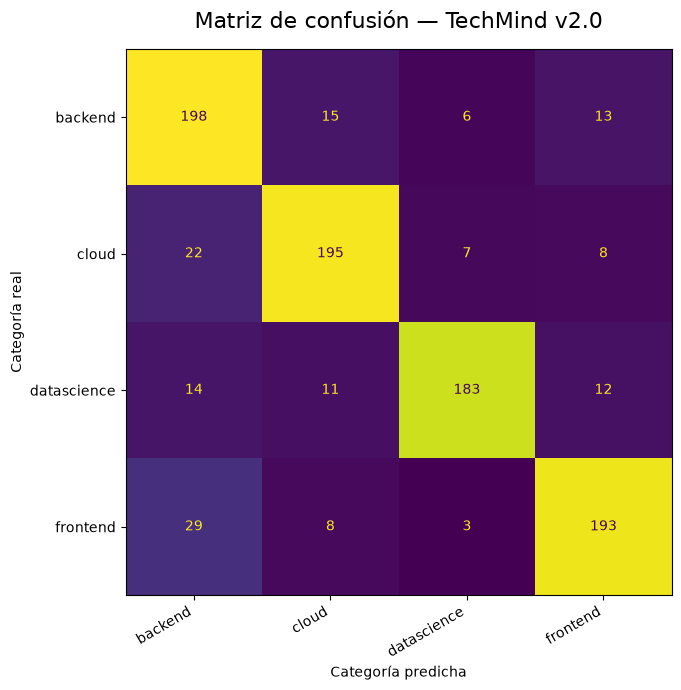

In [154]:
# ==============================================================================
# CELDA 142
# GRÁFICO DE MATRIZ DE CONFUSIÓN
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_final,
    display_labels=CLASES_FINALES
).plot(
    ax=ax,
    values_format="d",
    cmap=None,
    colorbar=False
)

ax.set_title(
    "Matriz de confusión — TechMind v2.0",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Categoría predicha"
)

ax.set_ylabel(
    "Categoría real"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

In [155]:
# ==============================================================================
# CELDA 143
# MATRIZ DE CONFUSIÓN NORMALIZADA
# ==============================================================================

matriz_confusion_normalizada = confusion_matrix(
    y_test_final,
    predicciones_test_final,
    labels=CLASES_FINALES,
    normalize="true"
)

df_matriz_confusion_normalizada = pd.DataFrame(
    matriz_confusion_normalizada,
    index=[
        f"Real_{clase}"
        for clase in CLASES_FINALES
    ],
    columns=[
        f"Pred_{clase}"
        for clase in CLASES_FINALES
    ]
)

display(
    df_matriz_confusion_normalizada.style.format(
        "{:.2%}"
    )
)

,Pred_backend,Pred_cloud,Pred_datascience,Pred_frontend
Real_backend,85.34%,6.47%,2.59%,5.60%
Real_cloud,9.48%,84.05%,3.02%,3.45%
Real_datascience,6.36%,5.00%,83.18%,5.45%
Real_frontend,12.45%,3.43%,1.29%,82.83%


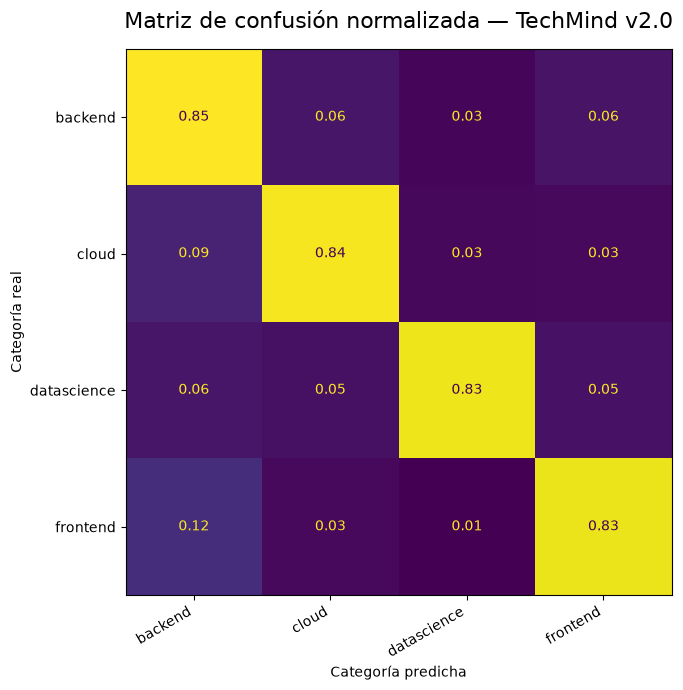

In [156]:
# ==============================================================================
# CELDA 144
# GRÁFICO NORMALIZADO
# ==============================================================================

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_normalizada,
    display_labels=CLASES_FINALES
).plot(
    ax=ax,
    values_format=".2f",
    cmap=None,
    colorbar=False
)

ax.set_title(
    "Matriz de confusión normalizada — TechMind v2.0",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Categoría predicha"
)

ax.set_ylabel(
    "Categoría real"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

In [157]:
# ==============================================================================
# CELDA 145
# GENERALIZACIÓN: CV VS. TEST
# ==============================================================================

diferencia_test_cv = (
    f1_macro_test_final
    - F1_CANDIDATO_FINAL
)

diferencia_absoluta_test_cv = abs(
    diferencia_test_cv
)

limite_inferior_cv_aproximado = (
    F1_CANDIDATO_FINAL
    - 2 * STD_CANDIDATO_FINAL
)

limite_superior_cv_aproximado = (
    F1_CANDIDATO_FINAL
    + 2 * STD_CANDIDATO_FINAL
)

test_dentro_rango_cv = (
    limite_inferior_cv_aproximado
    <= f1_macro_test_final
    <= limite_superior_cv_aproximado
)

df_comparacion_cv_test = pd.DataFrame({
    "Conjunto": [
        "Validación cruzada",
        "Prueba final"
    ],
    "F1_macro": [
        F1_CANDIDATO_FINAL,
        f1_macro_test_final
    ],
    "Desviacion": [
        STD_CANDIDATO_FINAL,
        np.nan
    ]
})

display(
    df_comparacion_cv_test.style.format({
        "F1_macro": "{:.4f}",
        "Desviacion": (
            lambda valor:
            "-"
            if pd.isna(valor)
            else f"{valor:.4f}"
        )
    })
)

print("=" * 90)
print("COMPARACIÓN CV VS. PRUEBA")
print("=" * 90)

print(
    f"F1 Macro CV: "
    f"{F1_CANDIDATO_FINAL:.4f}"
)

print(
    f"F1 Macro prueba: "
    f"{f1_macro_test_final:.4f}"
)

print(
    f"Diferencia prueba-CV: "
    f"{diferencia_test_cv:+.4f}"
)

print(
    f"Diferencia absoluta: "
    f"{diferencia_absoluta_test_cv:.4f}"
)

print(
    f"Rango aproximado CV: "
    f"[{limite_inferior_cv_aproximado:.4f}, "
    f"{limite_superior_cv_aproximado:.4f}]"
)

print(
    f"Resultado dentro del rango esperado: "
    f"{test_dentro_rango_cv}"
)

,Conjunto,F1_macro,Desviacion
0,Validación cruzada,0.8432,0.0116
1,Prueba final,0.8401,-


COMPARACIÓN CV VS. PRUEBA
F1 Macro CV: 0.8432
F1 Macro prueba: 0.8401
Diferencia prueba-CV: -0.0031
Diferencia absoluta: 0.0031
Rango aproximado CV: [0.8201, 0.8664]
Resultado dentro del rango esperado: True


In [158]:
# ==============================================================================
# CELDA 146
# PARES DE CONFUSIÓN MÁS FRECUENTES
# ==============================================================================

confusiones = []

for indice_real, categoria_real in enumerate(
    CLASES_FINALES
):

    for indice_pred, categoria_predicha in enumerate(
        CLASES_FINALES
    ):

        if categoria_real == categoria_predicha:
            continue

        cantidad = int(
            matriz_confusion_final[
                indice_real,
                indice_pred
            ]
        )

        confusiones.append({
            "Categoria_real": categoria_real,
            "Categoria_predicha": categoria_predicha,
            "Cantidad": cantidad
        })

df_confusiones = (
    pd.DataFrame(confusiones)
    .sort_values(
        "Cantidad",
        ascending=False
    )
    .reset_index(drop=True)
)

df_confusiones = df_confusiones[
    df_confusiones["Cantidad"] > 0
].reset_index(drop=True)

df_confusiones.insert(
    0,
    "Posicion",
    np.arange(
        1,
        len(df_confusiones) + 1
    )
)

display(
    df_confusiones.head(10)
)

,Posicion,Categoria_real,Categoria_predicha,Cantidad
0,1,frontend,backend,29
1,2,cloud,backend,22
2,3,backend,cloud,15
3,4,datascience,backend,14
4,5,backend,frontend,13
5,6,datascience,frontend,12
6,7,datascience,cloud,11
7,8,cloud,frontend,8
8,9,frontend,cloud,8
9,10,cloud,datascience,7


In [159]:
# ==============================================================================
# CELDA 147
# TABLA COMPLETA DE PREDICCIONES
# ==============================================================================

df_predicciones_finales = pd.DataFrame({
    "Categoria_real": (
        y_test_final
        .reset_index(drop=True)
    ),

    "Categoria_predicha": (
        predicciones_test_final
    ),

    "Texto": (
        X_test_final
        .reset_index(drop=True)
    )
})

if "id_documento" in df_test.columns:

    df_predicciones_finales.insert(
        0,
        "id_documento",
        df_test[
            "id_documento"
        ].reset_index(drop=True)
    )

df_predicciones_finales[
    "Prediccion_correcta"
] = (
    df_predicciones_finales[
        "Categoria_real"
    ]
    ==
    df_predicciones_finales[
        "Categoria_predicha"
    ]
)

print(
    f"Predicciones correctas: "
    f"{df_predicciones_finales['Prediccion_correcta'].sum():,}"
)

print(
    f"Predicciones incorrectas: "
    f"{(~df_predicciones_finales['Prediccion_correcta']).sum():,}"
)

display(
    df_predicciones_finales.head()
)

Predicciones correctas: 769
Predicciones incorrectas: 148


,id_documento,Categoria_real,Categoria_predicha,Texto,Prediccion_correcta
0,2137,backend,backend,7 best backend tools for vibe coders in 2026 7 best backend tools for vibe coders in 2026 vibe coding building applications through ai prompting r...,True
1,1640,cloud,cloud,detecting and managing terraform drift detecting and managing terraform drift terraform assumes it s the only thing managing your infrastructure. ...,True
2,3991,frontend,frontend,instant ux: optimistic ui with next.js server actions instant ux: optimistic ui with next.js server actions liquid syntax error: variable raw was ...,True
3,4333,backend,backend,5 python tricks every backend dev should know 5 python tricks every backend dev should know as backend developers we re constantly seeking ways to...,True
4,1933,cloud,cloud,netdata s intrusive cloud account prompts: how to disable and regain focus on system monitoring netdata s intrusive cloud account prompts: how to ...,True


In [160]:
# ==============================================================================
# CELDA 148
# MARGEN DE DECISIÓN
# ==============================================================================

puntuaciones_ordenadas = np.sort(
    puntuaciones_test_final,
    axis=1
)

margen_decision = (
    puntuaciones_ordenadas[:, -1]
    - puntuaciones_ordenadas[:, -2]
)

indice_mejor_puntuacion = np.argmax(
    puntuaciones_test_final,
    axis=1
)

puntuacion_maxima = np.max(
    puntuaciones_test_final,
    axis=1
)

df_predicciones_finales[
    "Puntuacion_maxima"
] = puntuacion_maxima

df_predicciones_finales[
    "Margen_decision"
] = margen_decision

print(
    f"Margen medio: "
    f"{margen_decision.mean():.4f}"
)

print(
    f"Margen mediano: "
    f"{np.median(margen_decision):.4f}"
)

print(
    f"Margen mínimo: "
    f"{margen_decision.min():.4f}"
)

print(
    f"Margen máximo: "
    f"{margen_decision.max():.4f}"
)

Margen medio: 1.8410
Margen mediano: 1.7854
Margen mínimo: 0.0040
Margen máximo: 5.6229


In [161]:
# ==============================================================================
# CELDA 149
# MARGEN SEGÚN RESULTADO
# ==============================================================================

df_margen_resultado = (
    df_predicciones_finales
    .groupby(
        "Prediccion_correcta"
    )["Margen_decision"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
    .reset_index()
    .rename(
        columns={
            "count": "Cantidad",
            "mean": "Media",
            "median": "Mediana",
            "min": "Minimo",
            "max": "Maximo"
        }
    )
)

display(
    df_margen_resultado.style.format({
        "Media": "{:.4f}",
        "Mediana": "{:.4f}",
        "Minimo": "{:.4f}",
        "Maximo": "{:.4f}"
    })
)

,Prediccion_correcta,Cantidad,Media,Mediana,Minimo,Maximo
0,False,148,0.5998,0.4149,0.0100,3.1159
1,True,769,2.0799,2.0840,0.0040,5.6229


In [162]:
# ==============================================================================
# CELDA 150
# ERRORES CON MENOR MARGEN DE DECISIÓN
# ==============================================================================

df_errores_finales = (
    df_predicciones_finales[
        ~df_predicciones_finales[
            "Prediccion_correcta"
        ]
    ]
    .copy()
    .sort_values(
        "Margen_decision",
        ascending=True
    )
    .reset_index(drop=True)
)

df_errores_finales.insert(
    0,
    "Posicion_error",
    np.arange(
        1,
        len(df_errores_finales) + 1
    )
)

df_errores_finales[
    "Texto_resumido"
] = (
    df_errores_finales[
        "Texto"
    ]
    .str.slice(
        0,
        250
    )
)

columnas_errores_mostrar = [
    columna
    for columna in [
        "Posicion_error",
        "id_documento",
        "Categoria_real",
        "Categoria_predicha",
        "Margen_decision",
        "Texto_resumido"
    ]
    if columna in df_errores_finales.columns
]

display(
    df_errores_finales[
        columnas_errores_mostrar
    ]
    .head(20)
    .style.format({
        "Margen_decision": "{:.4f}"
    })
)

,Posicion_error,id_documento,Categoria_real,Categoria_predicha,Margen_decision,Texto_resumido
0,1,3166,datascience,frontend,0.0100,building knn from scratch because import sklearn feels like cheating building knn from scratch because import sklearn feels like cheating building k-nearest neighbors knn from scratch let s be real: in a production machine. k-nearest neighbors knn k-
1,2,3282,frontend,cloud,0.0122,доктрина 1 позиционная сетка для построения блочных элементов с правильной регулировкой жирности:box-sizing доктрина 1 позиционная сетка для построения блочных элементов с правильной регулировкой жирности:box-sizing border-box коробка с вычислением ж
2,3,3575,cloud,datascience,0.0260,unlocking the potential of it services for business growth unlocking the potential of it services for business growth unlocking the potential of it services for business growth in today s fast-paced digital. the potential of it services for business
3,4,77,cloud,backend,0.0351,your first oracle autonomous database on oci always free your first oracle autonomous database on oci always free the single best way to keep your oracle skills sharp without a license a server or a. oracle oracle
4,5,2761,cloud,frontend,0.0375,technologies and concepts: cheat sheet for developer associate dva-c02 technologies and concepts: cheat sheet for developer associate dva-c02 exam guide: developer-associate technologies and concepts cheat sheet cheat sheet 1
5,6,610,backend,cloud,0.0388,what goes into building an event management platform in 2026 what goes into building an event management platform in 2026 event management platforms are a genuinely interesting engineering challenge they combine.
6,7,2201,frontend,backend,0.0486,burnlink: an open-source end-to-end encrypted file sharing platform burnlink: an open-source end-to-end encrypted file sharing platform executive summary i built burnlink an open-source file sharing service that prioritizes.
7,8,4175,backend,datascience,0.0510,decoupling domain from persistence: implementing the repository pattern in python decoupling domain from persistence: implementing the repository pattern in python introduction and context in enterprise applications one of the most common anti-patter
8,9,167,cloud,backend,0.0635,fix business email dns settings usa step-by-step fix business email dns settings usa step-by-step fix business email dns settings usa involves correcting your domain s dns records so that email. usa dns usa dns
9,10,1939,datascience,backend,0.0775,we rebuilt a securities firm s ficc data stack queries got 10x faster we rebuilt a securities firm s ficc data stack queries got 10x faster the investment research data team at a leading publicly listed securities firm had long struggled.


In [163]:
# ==============================================================================
# CELDA 151
# ERRORES CON MAYOR MARGEN
# ==============================================================================

df_errores_alto_margen = (
    df_errores_finales
    .sort_values(
        "Margen_decision",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    df_errores_alto_margen[
        columnas_errores_mostrar
    ]
    .head(20)
    .style.format({
        "Margen_decision": "{:.4f}"
    })
)

,Posicion_error,id_documento,Categoria_real,Categoria_predicha,Margen_decision,Texto_resumido
0,148,2733,backend,cloud,3.1159,when to move your app from shared hosting to cloud vps when to move your app from shared hosting to cloud vps moving your app from shared hosting to cloud vps is the right call the moment your traffic vps vps
1,147,4000,frontend,cloud,2.7613,why local system monitoring still beats the cloud and how i built my own dashboard to prove it why local system monitoring still beats the cloud and how i built my own dashboard to prove it over the past few years the technology industry has moved al
2,146,4363,datascience,backend,2.4792,the disk-level architecture of oltp vs. olap the disk-level architecture of oltp vs. olap every backend engineer has seen this happen you build an application on a relational database like.
3,145,595,frontend,cloud,2.1764,edge ai vs. cloud ai: understanding the distributed intelligence landscape edge ai vs. cloud ai: understanding the distributed intelligence landscape edge ai vs. cloud ai: understanding the distributed intelligence landscape the rapid. ai ai
4,144,1099,frontend,backend,2.0710,multi-device adaptive statistics backend: development practice for mobile/tablet operations dashboard adaptation multi-device adaptive statistics backend: development practice for mobile/tablet operations dashboard adaptation many cross-border purcha
5,143,4302,datascience,frontend,2.0448,how a javascript pivot table can handle 10 million rows in the browser how a javascript pivot table can handle 10 million rows in the browser a technical look at browser-local pivot table performance columnar ingestion web workers typedarrays and the
6,142,2241,frontend,backend,2.0327,where should you store your jwt where should you store your jwt one of the first questions developers face when implementing an authentication flow is: where should.
7,141,770,cloud,backend,1.7719,system design: how do we host an app that runs a job every 5 minutes system design: how do we host an app that runs a job every 5 minutes imagine you re building an app that needs to perform a task every 5 minutes. examples: send. every 5 minutes eve
8,140,1474,backend,frontend,1.7429,why we stop injecting code into shopify themes for b2b wholesale why we stop injecting code into shopify themes for b2b wholesale most traditional shopify wholesale apps inject hundreds of lines of messy javascript directly into. shopify javascript a
9,139,2822,frontend,backend,1.6107,slaying the n+1 dragon: a database optimization quest inspired by the lord of the rings slaying the n+1 dragon: a database optimization quest inspired by the lord of the rings the quest begins the why honestly i was just trying to get a simple blog f


In [164]:
# ==============================================================================
# CELDA 152
# DISTRIBUCIÓN REAL VS. PREDICHA
# ==============================================================================

distribucion_real_test = (
    pd.Series(
        y_test_final
    )
    .value_counts()
    .sort_index()
)

distribucion_predicha_test = (
    pd.Series(
        predicciones_test_final
    )
    .value_counts()
    .sort_index()
)

df_distribucion_real_predicha = pd.DataFrame({
    "Categoria": CLASES_FINALES,
    "Cantidad_real": [
        distribucion_real_test.get(
            categoria,
            0
        )
        for categoria in CLASES_FINALES
    ],
    "Cantidad_predicha": [
        distribucion_predicha_test.get(
            categoria,
            0
        )
        for categoria in CLASES_FINALES
    ]
})

df_distribucion_real_predicha[
    "Diferencia"
] = (
    df_distribucion_real_predicha[
        "Cantidad_predicha"
    ]
    -
    df_distribucion_real_predicha[
        "Cantidad_real"
    ]
)

display(df_distribucion_real_predicha)

,Categoria,Cantidad_real,Cantidad_predicha,Diferencia
0,backend,232,263,31
1,cloud,232,229,-3
2,datascience,220,199,-21
3,frontend,233,226,-7


In [165]:
# ==============================================================================
# CELDA 153
# DIAGNÓSTICO FINAL DE GENERALIZACIÓN
# ==============================================================================

if diferencia_test_cv >= -0.01:

    diagnostico_generalizacion_final = (
        "Generalización consistente"
    )

elif diferencia_test_cv >= -0.03:

    diagnostico_generalizacion_final = (
        "Disminución ligera frente a CV"
    )

elif diferencia_test_cv >= -0.05:

    diagnostico_generalizacion_final = (
        "Disminución moderada frente a CV"
    )

else:

    diagnostico_generalizacion_final = (
        "Disminución considerable frente a CV"
    )


resultado_final_supera_baseline = (
    f1_macro_test_final
    > f1_baseline_estratificado
)

resultado_final_aprobado = (
    0 <= f1_macro_test_final <= 1
    and
    resultado_final_supera_baseline
    and
    predicciones_validas
    and
    len(CLASES_FINALES) == 4
)

print("=" * 90)
print("DIAGNÓSTICO FINAL")
print("=" * 90)

print(
    f"Diagnóstico de generalización: "
    f"{diagnostico_generalizacion_final}"
)

print(
    f"Supera el baseline estratificado: "
    f"{resultado_final_supera_baseline}"
)

print(
    f"Resultado final aprobado: "
    f"{resultado_final_aprobado}"
)

if not resultado_final_aprobado:
    raise RuntimeError(
        "La evaluación final no superó las validaciones mínimas."
    )

DIAGNÓSTICO FINAL
Diagnóstico de generalización: Generalización consistente
Supera el baseline estratificado: True
Resultado final aprobado: True


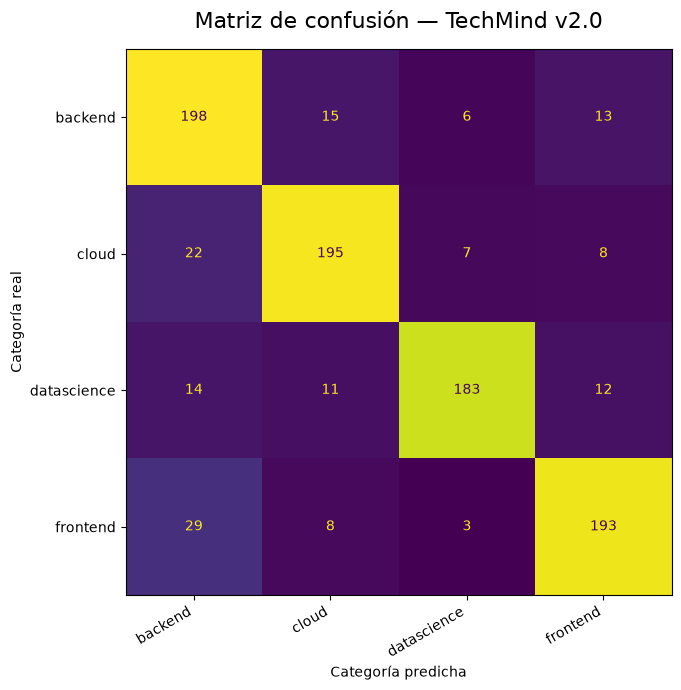

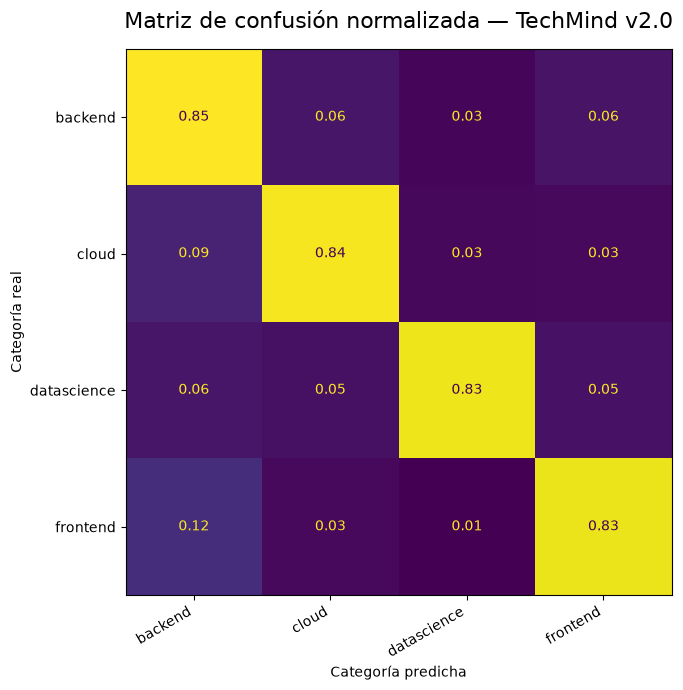

In [166]:
# ==============================================================================
# CELDA 154
# EXPORTACIÓN DE MATRICES DE CONFUSIÓN
# ==============================================================================

PATH_MATRIZ_CONFUSION_PNG = (
    RESULTS_DIR
    / "matriz_confusion_final.png"
)

PATH_MATRIZ_CONFUSION_NORMALIZADA_PNG = (
    RESULTS_DIR
    / "matriz_confusion_final_normalizada.png"
)


fig, ax = plt.subplots(
    figsize=(9, 7)
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_final,
    display_labels=CLASES_FINALES
).plot(
    ax=ax,
    values_format="d",
    cmap=None,
    colorbar=False
)

ax.set_title(
    "Matriz de confusión — TechMind v2.0",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Categoría predicha"
)

ax.set_ylabel(
    "Categoría real"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    PATH_MATRIZ_CONFUSION_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


fig, ax = plt.subplots(
    figsize=(9, 7)
)

ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_normalizada,
    display_labels=CLASES_FINALES
).plot(
    ax=ax,
    values_format=".2f",
    cmap=None,
    colorbar=False
)

ax.set_title(
    "Matriz de confusión normalizada — TechMind v2.0",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Categoría predicha"
)

ax.set_ylabel(
    "Categoría real"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    PATH_MATRIZ_CONFUSION_NORMALIZADA_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [167]:
# ==============================================================================
# CELDA 155
# RUTAS DE EXPORTACIÓN
# ==============================================================================

PATH_METRICAS_FINALES = (
    RESULTS_DIR
    / "metricas_finales_test.json"
)

PATH_REPORTE_CLASIFICACION = (
    RESULTS_DIR
    / "reporte_clasificacion_final.csv"
)

PATH_METRICAS_CATEGORIAS = (
    RESULTS_DIR
    / "metricas_finales_por_categoria.csv"
)

PATH_MATRIZ_CONFUSION = (
    RESULTS_DIR
    / "matriz_confusion_final.csv"
)

PATH_MATRIZ_CONFUSION_NORMALIZADA = (
    RESULTS_DIR
    / "matriz_confusion_final_normalizada.csv"
)

PATH_PREDICCIONES_FINALES = (
    RESULTS_DIR
    / "predicciones_test_final.csv"
)

PATH_ERRORES_FINALES = (
    RESULTS_DIR
    / "errores_clasificacion_final.csv"
)

PATH_CONFUSIONES_FRECUENTES = (
    RESULTS_DIR
    / "confusiones_frecuentes_final.csv"
)

PATH_MODELO_FINAL = (
    MODELS_DIR
    / "techmind_modelo_final.joblib"
)

PATH_METADATA_FINAL = (
    MODELS_DIR
    / "techmind_modelo_final_metadata.json"
)

In [168]:
# ==============================================================================
# CELDA 156
# EXPORTACIÓN DE TABLAS
# ==============================================================================

df_reporte_clasificacion.to_csv(
    PATH_REPORTE_CLASIFICACION,
    encoding="utf-8-sig"
)

df_metricas_categorias.to_csv(
    PATH_METRICAS_CATEGORIAS,
    index=False,
    encoding="utf-8-sig"
)

df_matriz_confusion.to_csv(
    PATH_MATRIZ_CONFUSION,
    encoding="utf-8-sig"
)

df_matriz_confusion_normalizada.to_csv(
    PATH_MATRIZ_CONFUSION_NORMALIZADA,
    encoding="utf-8-sig"
)

df_predicciones_finales.to_csv(
    PATH_PREDICCIONES_FINALES,
    index=False,
    encoding="utf-8-sig"
)

df_errores_finales.to_csv(
    PATH_ERRORES_FINALES,
    index=False,
    encoding="utf-8-sig"
)

df_confusiones.to_csv(
    PATH_CONFUSIONES_FRECUENTES,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Tablas finales exportadas correctamente."
)

Tablas finales exportadas correctamente.


In [169]:
# ==============================================================================
# CELDA 157
# RESUMEN DE MÉTRICAS FINALES
# ==============================================================================

metricas_finales_test = {
    "proyecto": "TechMind v2.0",

    "modelo": (
        NOMBRE_CANDIDATO_FINAL
    ),

    "variante_textual": (
        MEJOR_VARIANTE_TEXTO
    ),

    "registros_entrenamiento": int(
        len(X_train_final)
    ),

    "registros_prueba": int(
        len(X_test_final)
    ),

    "numero_features_tfidf": int(
        len(nombres_features_final)
    ),

    "metricas_validacion_cruzada": {
        "f1_macro_media": float(
            F1_CANDIDATO_FINAL
        ),
        "f1_macro_std": float(
            STD_CANDIDATO_FINAL
        )
    },

    "metricas_prueba": {
        "accuracy": float(
            accuracy_test_final
        ),
        "precision_macro": float(
            precision_macro_test_final
        ),
        "recall_macro": float(
            recall_macro_test_final
        ),
        "f1_macro": float(
            f1_macro_test_final
        ),
        "precision_weighted": float(
            precision_weighted_test_final
        ),
        "recall_weighted": float(
            recall_weighted_test_final
        ),
        "f1_weighted": float(
            f1_weighted_test_final
        )
    },

    "comparacion_cv_test": {
        "diferencia_test_cv": float(
            diferencia_test_cv
        ),
        "diferencia_absoluta": float(
            diferencia_absoluta_test_cv
        ),
        "limite_inferior_aproximado": float(
            limite_inferior_cv_aproximado
        ),
        "limite_superior_aproximado": float(
            limite_superior_cv_aproximado
        ),
        "test_dentro_rango_cv": bool(
            test_dentro_rango_cv
        ),
        "diagnostico": (
            diagnostico_generalizacion_final
        )
    },

    "mejor_categoria": {
        "categoria": str(
            mejor_categoria_test[
                "Categoria"
            ]
        ),
        "f1": float(
            mejor_categoria_test[
                "F1"
            ]
        )
    },

    "categoria_mas_dificil": {
        "categoria": str(
            categoria_mas_dificil_test[
                "Categoria"
            ]
        ),
        "f1": float(
            categoria_mas_dificil_test[
                "F1"
            ]
        )
    },

    "tiempo_prediccion_segundos": float(
        tiempo_prediccion_final
    ),

    "resultado_final_aprobado": bool(
        resultado_final_aprobado
    ),

    "conjunto_prueba_utilizado": True
}

with open(
    PATH_METRICAS_FINALES,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        metricas_finales_test,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print(
    f"Métricas finales exportadas en:\n"
    f"{PATH_METRICAS_FINALES.resolve()}"
)

Métricas finales exportadas en:
C:\Users\MAMÁ\Downloads\results\metricas_finales_test.json


In [170]:
# ==============================================================================
# CELDA 158
# EXPORTACIÓN DEL MODELO FINAL
# ==============================================================================

joblib.dump(
    modelo_candidato_final,
    PATH_MODELO_FINAL
)

print(
    f"Modelo definitivo guardado en:\n"
    f"{PATH_MODELO_FINAL.resolve()}"
)

Modelo definitivo guardado en:
C:\Users\MAMÁ\Downloads\models\techmind_modelo_final.joblib


In [171]:
# ==============================================================================
# CELDA 159
# METADATOS DEL MODELO FINAL
# ==============================================================================

metadata_modelo_final = {
    **metadata_modelo_candidato,

    "estado": (
        "Modelo final evaluado"
    ),

    "accuracy_test": float(
        accuracy_test_final
    ),

    "precision_macro_test": float(
        precision_macro_test_final
    ),

    "recall_macro_test": float(
        recall_macro_test_final
    ),

    "f1_macro_test": float(
        f1_macro_test_final
    ),

    "f1_weighted_test": float(
        f1_weighted_test_final
    ),

    "diferencia_f1_test_cv": float(
        diferencia_test_cv
    ),

    "diagnostico_generalizacion": (
        diagnostico_generalizacion_final
    ),

    "resultado_final_aprobado": bool(
        resultado_final_aprobado
    ),

    "conjunto_prueba_utilizado": True
}

with open(
    PATH_METADATA_FINAL,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        metadata_modelo_final,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print(
    f"Metadatos definitivos guardados en:\n"
    f"{PATH_METADATA_FINAL.resolve()}"
)

Metadatos definitivos guardados en:
C:\Users\MAMÁ\Downloads\models\techmind_modelo_final_metadata.json


In [172]:
# ==============================================================================
# CELDA 160
# VERIFICACIÓN FINAL DEL ARCHIVO
# ==============================================================================

modelo_final_recargado = joblib.load(
    PATH_MODELO_FINAL
)

predicciones_verificacion_final = (
    modelo_final_recargado.predict(
        X_test_final.iloc[:25]
    )
)

verificacion_modelo_final = np.array_equal(
    predicciones_verificacion_final,
    predicciones_test_final[:25]
)

print(
    f"Archivo del modelo reproducible: "
    f"{verificacion_modelo_final}"
)

if not verificacion_modelo_final:
    raise RuntimeError(
        "El archivo definitivo no reproduce las predicciones."
    )

Archivo del modelo reproducible: True


In [173]:
# ==============================================================================
# CELDA 161
# CONCLUSIÓN DE LA EVALUACIÓN FINAL
# ==============================================================================

print("=" * 90)
print("CONCLUSIÓN FINAL — TECHMIND V2.0")
print("=" * 90)

print(
    f"Modelo definitivo: "
    f"{NOMBRE_CANDIDATO_FINAL}"
)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Documentos de prueba: "
    f"{len(X_test_final):,}"
)

print(
    f"Accuracy final: "
    f"{accuracy_test_final:.4f}"
)

print(
    f"Precision Macro final: "
    f"{precision_macro_test_final:.4f}"
)

print(
    f"Recall Macro final: "
    f"{recall_macro_test_final:.4f}"
)

print(
    f"F1 Macro final: "
    f"{f1_macro_test_final:.4f}"
)

print(
    f"F1 Weighted final: "
    f"{f1_weighted_test_final:.4f}"
)

print(
    f"F1 Macro CV: "
    f"{F1_CANDIDATO_FINAL:.4f}"
)

print(
    f"Diferencia test-CV: "
    f"{diferencia_test_cv:+.4f}"
)

print(
    f"Diagnóstico: "
    f"{diagnostico_generalizacion_final}"
)

print(
    f"Mejor categoría: "
    f"{mejor_categoria_test['Categoria']} "
    f"({mejor_categoria_test['F1']:.4f})"
)

print(
    f"Categoría más difícil: "
    f"{categoria_mas_dificil_test['Categoria']} "
    f"({categoria_mas_dificil_test['F1']:.4f})"
)

print(
    f"Modelo reproducible: "
    f"{verificacion_modelo_final}"
)

print(
    f"Evaluación final aprobada: "
    f"{resultado_final_aprobado}"
)

if not resultado_final_aprobado:
    raise RuntimeError(
        "El modelo final no superó las validaciones."
    )

print(f"""
El modelo '{NOMBRE_CANDIDATO_FINAL}' fue evaluado por primera vez sobre los
{len(X_test_final):,} documentos del conjunto de prueba.

El modelo obtuvo un F1 Macro final de {f1_macro_test_final:.4f}. La diferencia
frente al resultado de validación cruzada fue de {diferencia_test_cv:+.4f},
clasificada como '{diagnostico_generalizacion_final}'.

La categoría con mejor desempeño fue
'{mejor_categoria_test["Categoria"]}', mientras que la categoría que presentó
mayor dificultad fue '{categoria_mas_dificil_test["Categoria"]}'.

El pipeline completo fue exportado como modelo definitivo y puede utilizarse
posteriormente desde una API o interfaz de clasificación.

A partir de este momento, el conjunto de prueba no debe utilizarse para realizar
nuevos ajustes de hiperparámetros.
""")

CONCLUSIÓN FINAL — TECHMIND V2.0
Modelo definitivo: TF-IDF + SGDClassifier optimizado
Variante textual: texto_combinado_ponderado
Documentos de prueba: 917
Accuracy final: 0.8386
Precision Macro final: 0.8445
Recall Macro final: 0.8385
F1 Macro final: 0.8401
F1 Weighted final: 0.8397
F1 Macro CV: 0.8432
Diferencia test-CV: -0.0031
Diagnóstico: Generalización consistente
Mejor categoría: datascience (0.8735)
Categoría más difícil: backend (0.8000)
Modelo reproducible: True
Evaluación final aprobada: True

El modelo 'TF-IDF + SGDClassifier optimizado' fue evaluado por primera vez sobre los
917 documentos del conjunto de prueba.

El modelo obtuvo un F1 Macro final de 0.8401. La diferencia
frente al resultado de validación cruzada fue de -0.0031,
clasificada como 'Generalización consistente'.

La categoría con mejor desempeño fue
'datascience', mientras que la categoría que presentó
mayor dificultad fue 'backend'.

El pipeline completo fue exportado como modelo definitivo y puede utilizars

In [174]:
# ==============================================================================
# CELDA 162
# RESUMEN EJECUTIVO Y CIERRE DEL NOTEBOOK 03
# ==============================================================================

import hashlib
from datetime import datetime

print("=" * 90)
print("RESUMEN EJECUTIVO — NOTEBOOK 03")
print("=" * 90)

RESUMEN EJECUTIVO — NOTEBOOK 03


In [175]:
# ==============================================================================
# CELDA 163
# EVOLUCIÓN DEL RENDIMIENTO
# ==============================================================================

etapas_modelado = [
    {
        "Etapa": "Baseline mayoritario",
        "Modelo": "DummyClassifier",
        "Tipo_evaluacion": "Validación cruzada",
        "F1_macro": float(
            resultado_baseline_mayoritario[
                "F1_macro_media"
            ]
        ),
        "Desviacion": float(
            resultado_baseline_mayoritario[
                "F1_macro_std"
            ]
        )
    },
    {
        "Etapa": "Baseline estratificado",
        "Modelo": "DummyClassifier",
        "Tipo_evaluacion": "Validación cruzada",
        "F1_macro": float(
            resultado_baseline_estratificado[
                "F1_macro_media"
            ]
        ),
        "Desviacion": float(
            resultado_baseline_estratificado[
                "F1_macro_std"
            ]
        )
    },
    {
        "Etapa": "Modelo textual inicial",
        "Modelo": "TF-IDF + Regresión Logística",
        "Tipo_evaluacion": "Validación cruzada",
        "F1_macro": float(
            resultado_logistica_base[
                "F1_macro_media"
            ]
        ),
        "Desviacion": float(
            resultado_logistica_base[
                "F1_macro_std"
            ]
        )
    },
    {
        "Etapa": "Mejor variante textual",
        "Modelo": (
            "Regresión Logística + "
            f"{MEJOR_VARIANTE_TEXTO}"
        ),
        "Tipo_evaluacion": "Validación cruzada",
        "F1_macro": float(
            MEJOR_F1_VARIANTE
        ),
        "Desviacion": float(
            MEJOR_STD_VARIANTE
        )
    },
    {
        "Etapa": "Mejor algoritmo base",
        "Modelo": MEJOR_MODELO_NOMBRE,
        "Tipo_evaluacion": "Validación cruzada",
        "F1_macro": float(
            MEJOR_F1_ALGORITMO
        ),
        "Desviacion": float(
            MEJOR_STD_ALGORITMO
        )
    },
    {
        "Etapa": "Modelo textual optimizado",
        "Modelo": MEJOR_MODELO_OPTIMIZADO_NOMBRE,
        "Tipo_evaluacion": "Validación cruzada",
        "F1_macro": float(
            MEJOR_F1_OPTIMIZADO
        ),
        "Desviacion": float(
            MEJOR_STD_OPTIMIZADO
        )
    },
    {
        "Etapa": "Modelo híbrido",
        "Modelo": NOMBRE_MODELO_HIBRIDO,
        "Tipo_evaluacion": "Validación cruzada",
        "F1_macro": float(
            f1_hibrido
        ),
        "Desviacion": float(
            std_hibrido
        )
    },
    {
        "Etapa": "Modelo definitivo",
        "Modelo": NOMBRE_CANDIDATO_FINAL,
        "Tipo_evaluacion": "Prueba final",
        "F1_macro": float(
            f1_macro_test_final
        ),
        "Desviacion": np.nan
    }
]

df_evolucion_modelado = pd.DataFrame(
    etapas_modelado
)

df_evolucion_modelado.insert(
    0,
    "Orden",
    np.arange(
        1,
        len(df_evolucion_modelado) + 1
    )
)

display(
    df_evolucion_modelado.style.format({
        "F1_macro": "{:.4f}",
        "Desviacion": (
            lambda valor:
            "-"
            if pd.isna(valor)
            else f"{valor:.4f}"
        )
    })
)

,Orden,Etapa,Modelo,Tipo_evaluacion,F1_macro,Desviacion
0,1,Baseline mayoritario,DummyClassifier,Validación cruzada,0.1013,0.0002
1,2,Baseline estratificado,DummyClassifier,Validación cruzada,0.2512,0.0066
2,3,Modelo textual inicial,TF-IDF + Regresión Logística,Validación cruzada,0.8167,0.0167
3,4,Mejor variante textual,Regresión Logística + texto_combinado_ponderado,Validación cruzada,0.8260,0.0159
4,5,Mejor algoritmo base,TF-IDF + LinearSVC,Validación cruzada,0.8357,0.0110
5,6,Modelo textual optimizado,TF-IDF + SGDClassifier optimizado,Validación cruzada,0.8432,0.0116
6,7,Modelo híbrido,TF-IDF + numéricas + SGDClassifier optimizado,Validación cruzada,0.8282,0.0197
7,8,Modelo definitivo,TF-IDF + SGDClassifier optimizado,Prueba final,0.8401,-


In [176]:
# ==============================================================================
# CELDA 164
# MEJORAS DEL PROYECTO
# ==============================================================================

f1_baseline_inicial = float(
    resultado_baseline_estratificado[
        "F1_macro_media"
    ]
)

mejora_vs_baseline = (
    f1_macro_test_final
    - f1_baseline_inicial
)

mejora_vs_baseline_relativa = (
    mejora_vs_baseline
    / f1_baseline_inicial
    * 100
)

mejora_modelo_inicial = (
    f1_macro_test_final
    - resultado_logistica_base[
        "F1_macro_media"
    ]
)

mejora_optimizacion = (
    MEJOR_F1_OPTIMIZADO
    - MEJOR_F1_ALGORITMO
)

diferencia_hibrido_textual = (
    f1_hibrido
    - MEJOR_F1_OPTIMIZADO
)

print("=" * 90)
print("EVOLUCIÓN DEL RENDIMIENTO")
print("=" * 90)

print(
    f"F1 Macro baseline estratificado: "
    f"{f1_baseline_inicial:.4f}"
)

print(
    f"F1 Macro modelo textual inicial: "
    f"{resultado_logistica_base['F1_macro_media']:.4f}"
)

print(
    f"F1 Macro modelo optimizado CV: "
    f"{MEJOR_F1_OPTIMIZADO:.4f}"
)

print(
    f"F1 Macro modelo definitivo: "
    f"{f1_macro_test_final:.4f}"
)

print(
    f"\nMejora frente al baseline: "
    f"{mejora_vs_baseline:+.4f}"
)

print(
    f"Mejora relativa frente al baseline: "
    f"{mejora_vs_baseline_relativa:+.2f}%"
)

print(
    f"Mejora frente al modelo textual inicial: "
    f"{mejora_modelo_inicial:+.4f}"
)

print(
    f"Mejora obtenida por optimización: "
    f"{mejora_optimizacion:+.4f}"
)

print(
    f"Diferencia híbrido-textual: "
    f"{diferencia_hibrido_textual:+.4f}"
)

EVOLUCIÓN DEL RENDIMIENTO
F1 Macro baseline estratificado: 0.2512
F1 Macro modelo textual inicial: 0.8167
F1 Macro modelo optimizado CV: 0.8432
F1 Macro modelo definitivo: 0.8401

Mejora frente al baseline: +0.5889
Mejora relativa frente al baseline: +234.48%
Mejora frente al modelo textual inicial: +0.0235
Mejora obtenida por optimización: +0.0076
Diferencia híbrido-textual: -0.0150


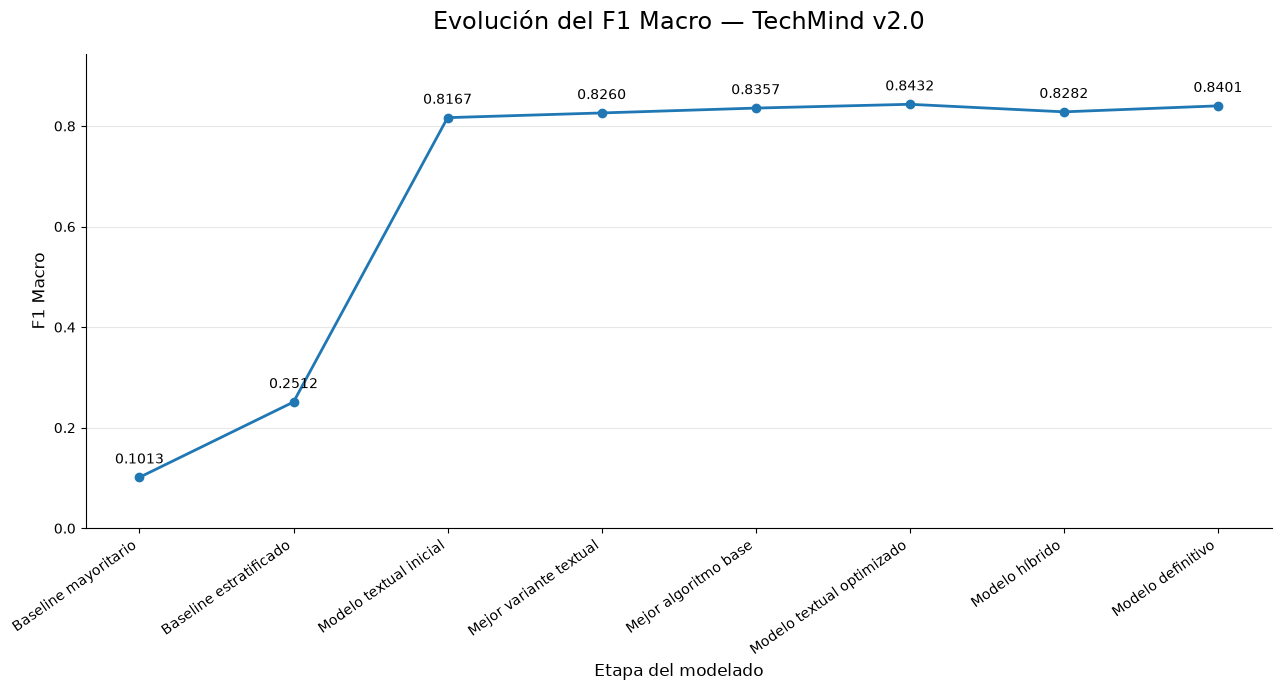

Gráfico exportado en:
C:\Users\MAMÁ\Downloads\results\evolucion_f1_macro_notebook03.png


In [177]:
# ==============================================================================
# CELDA 165
# GRÁFICO DE EVOLUCIÓN
# ==============================================================================

PATH_EVOLUCION_F1 = (
    RESULTS_DIR
    / "evolucion_f1_macro_notebook03.png"
)

fig, ax = plt.subplots(
    figsize=(13, 7)
)

posiciones = np.arange(
    len(df_evolucion_modelado)
)

ax.plot(
    posiciones,
    df_evolucion_modelado["F1_macro"],
    marker="o",
    linewidth=2
)

for posicion, valor in zip(
    posiciones,
    df_evolucion_modelado["F1_macro"]
):

    ax.annotate(
        f"{valor:.4f}",
        xy=(posicion, valor),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Evolución del F1 Macro — TechMind v2.0",
    fontsize=17,
    pad=18
)

ax.set_xlabel(
    "Etapa del modelado",
    fontsize=12
)

ax.set_ylabel(
    "F1 Macro",
    fontsize=12
)

ax.set_xticks(
    posiciones
)

ax.set_xticklabels(
    df_evolucion_modelado["Etapa"],
    rotation=35,
    ha="right"
)

ax.set_ylim(
    0,
    min(
        1,
        df_evolucion_modelado[
            "F1_macro"
        ].max() + 0.10
    )
)

ax.grid(
    axis="y",
    alpha=0.3
)

for borde in [
    "top",
    "right"
]:
    ax.spines[borde].set_visible(False)

plt.tight_layout()

plt.savefig(
    PATH_EVOLUCION_F1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfico exportado en:\n"
    f"{PATH_EVOLUCION_F1.resolve()}"
)

In [178]:
# ==============================================================================
# CELDA 166
# TABLA EJECUTIVA DE RESULTADOS
# ==============================================================================

df_resumen_metricas_finales = pd.DataFrame({
    "Indicador": [
        "Registros de entrenamiento",
        "Registros de prueba",
        "Categorías",
        "Características TF-IDF",
        "Accuracy final",
        "Precision Macro final",
        "Recall Macro final",
        "F1 Macro final",
        "F1 Weighted final",
        "F1 Macro CV",
        "Desviación F1 Macro CV",
        "Diferencia test-CV",
        "Mejor categoría",
        "F1 mejor categoría",
        "Categoría más difícil",
        "F1 categoría más difícil",
        "Generalización",
        "Modelo reproducible"
    ],

    "Resultado": [
        f"{len(X_train_final):,}",
        f"{len(X_test_final):,}",
        str(len(CLASES_FINALES)),
        f"{len(nombres_features_final):,}",
        f"{accuracy_test_final:.4f}",
        f"{precision_macro_test_final:.4f}",
        f"{recall_macro_test_final:.4f}",
        f"{f1_macro_test_final:.4f}",
        f"{f1_weighted_test_final:.4f}",
        f"{F1_CANDIDATO_FINAL:.4f}",
        f"{STD_CANDIDATO_FINAL:.4f}",
        f"{diferencia_test_cv:+.4f}",
        str(
            mejor_categoria_test[
                "Categoria"
            ]
        ),
        f"{mejor_categoria_test['F1']:.4f}",
        str(
            categoria_mas_dificil_test[
                "Categoria"
            ]
        ),
        (
            f"{categoria_mas_dificil_test['F1']:.4f}"
        ),
        diagnostico_generalizacion_final,
        str(verificacion_modelo_final)
    ]
})

display(
    df_resumen_metricas_finales
)

,Indicador,Resultado
0,Registros de entrenamiento,"3,666"
1,Registros de prueba,917
2,Categorías,4
3,Características TF-IDF,"30,000"
4,Accuracy final,0.8386
5,Precision Macro final,0.8445
6,Recall Macro final,0.8385
7,F1 Macro final,0.8401
8,F1 Weighted final,0.8397
9,F1 Macro CV,0.8432


In [179]:
# ==============================================================================
# CELDA 167
# DESEMPEÑO POR CATEGORÍA
# ==============================================================================

df_resumen_categorias_final = (
    df_metricas_categorias[
        [
            "Categoria",
            "Precision",
            "Recall",
            "F1",
            "Soporte"
        ]
    ]
    .copy()
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    df_resumen_categorias_final.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Categoria,Precision,Recall,F1,Soporte
0,datascience,0.9196,0.8318,0.8735,220
1,cloud,0.8515,0.8405,0.8460,232
2,frontend,0.8540,0.8283,0.8410,233
3,backend,0.7529,0.8534,0.8000,232


In [180]:
# ==============================================================================
# CELDA 168
# RESUMEN EJECUTIVO EN DICCIONARIO
# ==============================================================================

resumen_ejecutivo_notebook03 = {
    "proyecto": "TechMind v2.0",

    "notebook": (
        "03_entrenamiento_comparacion_modelos"
    ),

    "fecha_generacion": datetime.now().isoformat(
        timespec="seconds"
    ),

    "objetivo": (
        "Clasificar contenido tecnológico en backend, "
        "cloud, datascience y frontend."
    ),

    "dataset": {
        "registros_totales": int(
            len(df_modelos)
        ),
        "registros_entrenamiento": int(
            len(X_train_final)
        ),
        "registros_prueba": int(
            len(X_test_final)
        ),
        "categorias": (
            CLASES_FINALES
        ),
        "variable_textual": (
            MEJOR_VARIANTE_TEXTO
        )
    },

    "seleccion_modelo": {
        "modelo_definitivo": (
            NOMBRE_CANDIDATO_FINAL
        ),
        "tipo_entrada": (
            TIPO_CANDIDATO_FINAL
        ),
        "numero_features_tfidf": int(
            len(nombres_features_final)
        ),
        "hiperparametros": (
            convertir_json_seguro(
                MEJORES_PARAMETROS_OPTIMIZADOS
            )
        )
    },

    "resultados_validacion_cruzada": {
        "f1_macro": float(
            F1_CANDIDATO_FINAL
        ),
        "desviacion": float(
            STD_CANDIDATO_FINAL
        ),
        "brecha_train_cv": float(
            brecha_train_cv_final
        )
    },

    "resultados_prueba": {
        "accuracy": float(
            accuracy_test_final
        ),
        "precision_macro": float(
            precision_macro_test_final
        ),
        "recall_macro": float(
            recall_macro_test_final
        ),
        "f1_macro": float(
            f1_macro_test_final
        ),
        "f1_weighted": float(
            f1_weighted_test_final
        )
    },

    "generalizacion": {
        "diferencia_test_cv": float(
            diferencia_test_cv
        ),
        "diagnostico": (
            diagnostico_generalizacion_final
        ),
        "resultado_dentro_rango_cv": bool(
            test_dentro_rango_cv
        )
    },

    "categorias": {
        "mejor": {
            "nombre": str(
                mejor_categoria_test[
                    "Categoria"
                ]
            ),
            "f1": float(
                mejor_categoria_test[
                    "F1"
                ]
            )
        },
        "mas_dificil": {
            "nombre": str(
                categoria_mas_dificil_test[
                    "Categoria"
                ]
            ),
            "f1": float(
                categoria_mas_dificil_test[
                    "F1"
                ]
            )
        }
    },

    "comparacion_hibrida": {
        "f1_textual": float(
            MEJOR_F1_OPTIMIZADO
        ),
        "f1_hibrido": float(
            f1_hibrido
        ),
        "diferencia": float(
            diferencia_hibrido_textual
        ),
        "folds_ganados_hibrido": int(
            folds_ganados_hibrido
        ),
        "modelo_seleccionado": (
            "Solo texto"
        )
    },

    "estado": {
        "evaluacion_final_aprobada": bool(
            resultado_final_aprobado
        ),
        "modelo_reproducible": bool(
            verificacion_modelo_final
        ),
        "notebook_completado": True
    }
}

In [181]:
# ==============================================================================
# CELDA 169
# EXPORTACIÓN DEL RESUMEN EJECUTIVO
# ==============================================================================

PATH_RESUMEN_NOTEBOOK03_JSON = (
    REPORTS_DIR
    / "resumen_ejecutivo_notebook03.json"
)

PATH_RESUMEN_NOTEBOOK03_CSV = (
    RESULTS_DIR
    / "resumen_ejecutivo_notebook03.csv"
)

PATH_EVOLUCION_MODELOS_CSV = (
    RESULTS_DIR
    / "evolucion_modelado_notebook03.csv"
)

PATH_RESUMEN_CATEGORIAS_CSV = (
    RESULTS_DIR
    / "resumen_categorias_notebook03.csv"
)

with open(
    PATH_RESUMEN_NOTEBOOK03_JSON,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen_ejecutivo_notebook03,
        archivo,
        ensure_ascii=False,
        indent=4
    )

df_resumen_metricas_finales.to_csv(
    PATH_RESUMEN_NOTEBOOK03_CSV,
    index=False,
    encoding="utf-8-sig"
)

df_evolucion_modelado.to_csv(
    PATH_EVOLUCION_MODELOS_CSV,
    index=False,
    encoding="utf-8-sig"
)

df_resumen_categorias_final.to_csv(
    PATH_RESUMEN_CATEGORIAS_CSV,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Resumen ejecutivo exportado correctamente."
)

Resumen ejecutivo exportado correctamente.


In [182]:
!pip install tabulate

In [184]:
# ==============================================================================
# CELDA 170
# REPORTE MARKDOWN
# ===============================================================================

if "REPORTS_DIR" not in globals():
    from pathlib import Path

    REPORTS_DIR = Path("..") / "reports"
    REPORTS_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

PATH_REPORTE_NOTEBOOK03_MD = (
    REPORTS_DIR
    / "resumen_notebook03.md"
)

tabla_categorias_markdown = (
    df_resumen_categorias_final
    .round({
        "Precision": 4,
        "Recall": 4,
        "F1": 4
    })
    .to_markdown(
        index=False
    )
)

contenido_markdown = f"""# TechMind v2.0

## Resumen del Notebook 03

### Modelo definitivo

- **Modelo:** {NOMBRE_CANDIDATO_FINAL}
- **Variante textual:** `{MEJOR_VARIANTE_TEXTO}`
- **Clasificador:** `{clasificador_final.__class__.__name__}`
- **Características TF-IDF:** {len(nombres_features_final):,}
- **Registros de entrenamiento:** {len(X_train_final):,}
- **Registros de prueba:** {len(X_test_final):,}

### Resultados finales

| Métrica | Resultado |
|---|---:|
| Accuracy | {accuracy_test_final:.4f} |
| Precision Macro | {precision_macro_test_final:.4f} |
| Recall Macro | {recall_macro_test_final:.4f} |
| F1 Macro | {f1_macro_test_final:.4f} |
| F1 Weighted | {f1_weighted_test_final:.4f} |
| F1 Macro CV | {F1_CANDIDATO_FINAL:.4f} |
| Diferencia test-CV | {diferencia_test_cv:+.4f} |

### Generalización

El resultado fue clasificado como **{diagnostico_generalizacion_final}**.
La diferencia entre validación cruzada y prueba fue de
`{diferencia_test_cv:+.4f}`.

### Rendimiento por categoría

{tabla_categorias_markdown}

### Comparación del modelo híbrido

El modelo textual obtuvo un F1 Macro de `{MEJOR_F1_OPTIMIZADO:.4f}`,
mientras que el modelo híbrido obtuvo `{f1_hibrido:.4f}`.

La incorporación de las 19 características numéricas produjo una diferencia
de `{diferencia_hibrido_textual:+.4f}`. Por ello, se seleccionó el modelo
exclusivamente textual.

### Conclusión

El modelo definitivo superó las validaciones de reproducibilidad y evaluación.
El pipeline puede avanzar a la etapa de interpretabilidad, pruebas funcionales
y preparación para despliegue.

El conjunto de prueba no debe utilizarse para realizar nuevos ajustes de
hiperparámetros.
"""

with open(
    PATH_REPORTE_NOTEBOOK03_MD,
    "w",
    encoding="utf-8"
) as archivo:

    archivo.write(
        contenido_markdown
    )

print(
    f"Reporte Markdown exportado en:\n"
    f"{PATH_REPORTE_NOTEBOOK03_MD.resolve()}"
)

Reporte Markdown exportado en:
C:\Users\MAMÁ\Downloads\reports\resumen_notebook03.md


In [185]:
# ==============================================================================
# CELDA 171
# MANIFIESTO DE ARCHIVOS DEL NOTEBOOK 03
# ==============================================================================

def calcular_sha256(ruta):
    """
    Calcula la firma SHA-256 de un archivo.
    """

    hash_sha256 = hashlib.sha256()

    with open(
        ruta,
        "rb"
    ) as archivo:

        for bloque in iter(
            lambda: archivo.read(8_192),
            b""
        ):
            hash_sha256.update(
                bloque
            )

    return hash_sha256.hexdigest()

In [186]:
archivos_notebook03 = [
    PATH_MODELO_FINAL,
    PATH_METADATA_FINAL,
    PATH_METRICAS_FINALES,
    PATH_REPORTE_CLASIFICACION,
    PATH_METRICAS_CATEGORIAS,
    PATH_MATRIZ_CONFUSION,
    PATH_MATRIZ_CONFUSION_NORMALIZADA,
    PATH_PREDICCIONES_FINALES,
    PATH_ERRORES_FINALES,
    PATH_CONFUSIONES_FRECUENTES,
    PATH_MATRIZ_CONFUSION_PNG,
    PATH_MATRIZ_CONFUSION_NORMALIZADA_PNG,
    PATH_EVOLUCION_F1,
    PATH_RESUMEN_NOTEBOOK03_JSON,
    PATH_RESUMEN_NOTEBOOK03_CSV,
    PATH_EVOLUCION_MODELOS_CSV,
    PATH_RESUMEN_CATEGORIAS_CSV,
    PATH_REPORTE_NOTEBOOK03_MD
]

registros_manifiesto = []

for ruta in archivos_notebook03:

    if ruta.exists():

        registros_manifiesto.append({
            "Archivo": ruta.name,
            "Extension": ruta.suffix.lower(),
            "Tamaño_KB": round(
                ruta.stat().st_size / 1024,
                2
            ),
            "SHA256": calcular_sha256(
                ruta
            ),
            "Ruta": str(
                ruta.resolve()
            )
        })

    else:

        registros_manifiesto.append({
            "Archivo": ruta.name,
            "Extension": ruta.suffix.lower(),
            "Tamaño_KB": 0,
            "SHA256": None,
            "Ruta": str(
                ruta.resolve()
            )
        })


df_manifiesto_notebook03 = pd.DataFrame(
    registros_manifiesto
)

display(
    df_manifiesto_notebook03
)

,Archivo,Extension,Tamaño_KB,SHA256,Ruta
0,techmind_modelo_final.joblib,.joblib,"2,017.3500",488ec7d47f7697f870fde6877d8df54e5ce1fedbc29842dd669a1014c7715cfb,C:\Users\MAMÁ\Downloads\models\techmind_modelo_final.joblib
1,techmind_modelo_final_metadata.json,.json,1.4400,240d14eaf128fce2f8fb0fb19da9958dd693a75ac2984e20d9435aecdc610a6c,C:\Users\MAMÁ\Downloads\models\techmind_modelo_final_metadata.json
2,metricas_finales_test.json,.json,1.3900,1a4f221ea0c2654220b5e4c838afb2f4976d29286f01edcc7f099fb7f2e08a71,C:\Users\MAMÁ\Downloads\results\metricas_finales_test.json
3,reporte_clasificacion_final.csv,.csv,0.5300,b3cdd8193978b4d1a64ae4cb713f6768a62276e091277939cfe6fb01d03618c7,C:\Users\MAMÁ\Downloads\results\reporte_clasificacion_final.csv
4,metricas_finales_por_categoria.csv,.csv,0.3200,73559194b0e4c27baac4e4977f53a1a41322e7a9fc3312b453b332ebd834d73f,C:\Users\MAMÁ\Downloads\results\metricas_finales_por_categoria.csv
5,matriz_confusion_final.csv,.csv,0.1600,7f482793dc79b5e8b38515251ca5cefe9470e97bef5b0211dce1c6f779d33406,C:\Users\MAMÁ\Downloads\results\matriz_confusion_final.csv
6,matriz_confusion_final_normalizada.csv,.csv,0.4100,15c325437ad008c90539e6ae58744fa761c132ec680033573ba308b7f43bd490,C:\Users\MAMÁ\Downloads\results\matriz_confusion_final_normalizada.csv
7,predicciones_test_final.csv,.csv,286.5600,a69af4e70c0d9de402e188ab55c625a5fcfc44f770592a1ebf9c084e22731645,C:\Users\MAMÁ\Downloads\results\predicciones_test_final.csv
8,errores_clasificacion_final.csv,.csv,80.6300,ebe55ba637f484fbfb633648c6e0bc5823b1fab6a2f6dcfc9964ac331db9c9ae,C:\Users\MAMÁ\Downloads\results\errores_clasificacion_final.csv
9,confusiones_frecuentes_final.csv,.csv,0.3300,e901ea4ad21bf0ea7a28fe6e831fb4f6eda5054f0c058108519d993665c63722,C:\Users\MAMÁ\Downloads\results\confusiones_frecuentes_final.csv


In [187]:
# ==============================================================================
# CELDA 173
# CONTROL DE ARCHIVOS OBLIGATORIOS
# ==============================================================================

ARCHIVOS_OBLIGATORIOS_NOTEBOOK03 = [
    PATH_MODELO_FINAL,
    PATH_METADATA_FINAL,
    PATH_METRICAS_FINALES,
    PATH_PREDICCIONES_FINALES,
    PATH_REPORTE_CLASIFICACION,
    PATH_MATRIZ_CONFUSION_PNG,
    PATH_MATRIZ_CONFUSION_NORMALIZADA_PNG,
    PATH_RESUMEN_NOTEBOOK03_JSON,
    PATH_REPORTE_NOTEBOOK03_MD
]

archivos_obligatorios_faltantes = [
    str(ruta.resolve())
    for ruta in ARCHIVOS_OBLIGATORIOS_NOTEBOOK03
    if not ruta.exists()
]

archivos_obligatorios_correctos = (
    len(
        archivos_obligatorios_faltantes
    )
    == 0
)

print(
    f"Archivos obligatorios correctos: "
    f"{archivos_obligatorios_correctos}"
)

if archivos_obligatorios_faltantes:

    print(
        "\nArchivos faltantes:"
    )

    for archivo in (
        archivos_obligatorios_faltantes
    ):
        print(
            f"- {archivo}"
        )

Archivos obligatorios correctos: True


In [188]:
# ==============================================================================
# CELDA 174
# EXPORTACIÓN DEL MANIFIESTO
# ==============================================================================

PATH_MANIFIESTO_NOTEBOOK03_CSV = (
    REPORTS_DIR
    / "manifiesto_notebook03.csv"
)

PATH_MANIFIESTO_NOTEBOOK03_JSON = (
    REPORTS_DIR
    / "manifiesto_notebook03.json"
)

df_manifiesto_notebook03.to_csv(
    PATH_MANIFIESTO_NOTEBOOK03_CSV,
    index=False,
    encoding="utf-8-sig"
)

with open(
    PATH_MANIFIESTO_NOTEBOOK03_JSON,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        registros_manifiesto,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print(
    "Manifiesto del Notebook 03 exportado correctamente."
)

Manifiesto del Notebook 03 exportado correctamente.


In [189]:
# ==============================================================================
# CELDA 175
# PRUEBA FUNCIONAL CON TEXTOS NUEVOS
# ==============================================================================

ejemplos_funcionales = pd.Series([
    (
        "spring boot rest api java microservices "
        "database backend development"
    ),
    (
        "aws kubernetes cloud infrastructure "
        "docker deployment monitoring"
    ),
    (
        "machine learning pandas scikit-learn "
        "data analysis predictive model"
    ),
    (
        "react css javascript responsive interface "
        "frontend web components"
    )
])

predicciones_funcionales = (
    modelo_final_recargado.predict(
        ejemplos_funcionales
    )
)

puntuaciones_funcionales = (
    modelo_final_recargado
    .decision_function(
        ejemplos_funcionales
    )
)

margenes_funcionales = (
    np.sort(
        puntuaciones_funcionales,
        axis=1
    )[:, -1]
    -
    np.sort(
        puntuaciones_funcionales,
        axis=1
    )[:, -2]
)

df_prueba_funcional_final = pd.DataFrame({
    "Texto": ejemplos_funcionales,
    "Categoria_predicha": (
        predicciones_funcionales
    ),
    "Margen_decision": (
        margenes_funcionales
    )
})

display(
    df_prueba_funcional_final.style.format({
        "Margen_decision": "{:.4f}"
    })
)

,Texto,Categoria_predicha,Margen_decision
0,spring boot rest api java microservices database backend development,backend,5.9490
1,aws kubernetes cloud infrastructure docker deployment monitoring,cloud,9.8097
2,machine learning pandas scikit-learn data analysis predictive model,datascience,5.7588
3,react css javascript responsive interface frontend web components,frontend,8.6206


In [190]:
# ==============================================================================
# CELDA 176
# CONCLUSIÓN EJECUTIVA
# ==============================================================================

notebook03_completado = (
    resultado_final_aprobado
    and
    verificacion_modelo_final
    and
    archivos_obligatorios_correctos
    and
    len(df_metricas_categorias) == 4
    and
    len(predicciones_test_final)
    == len(X_test_final)
)

print("=" * 90)
print("CIERRE DEL NOTEBOOK 03 — TECHMIND V2.0")
print("=" * 90)

print(
    f"Modelo definitivo: "
    f"{NOMBRE_CANDIDATO_FINAL}"
)

print(
    f"Variante textual: "
    f"{MEJOR_VARIANTE_TEXTO}"
)

print(
    f"Registros de entrenamiento: "
    f"{len(X_train_final):,}"
)

print(
    f"Registros de prueba: "
    f"{len(X_test_final):,}"
)

print(
    f"Características TF-IDF: "
    f"{len(nombres_features_final):,}"
)

print(
    f"Accuracy final: "
    f"{accuracy_test_final:.4f}"
)

print(
    f"F1 Macro final: "
    f"{f1_macro_test_final:.4f}"
)

print(
    f"F1 Macro CV: "
    f"{F1_CANDIDATO_FINAL:.4f}"
)

print(
    f"Diferencia test-CV: "
    f"{diferencia_test_cv:+.4f}"
)

print(
    f"Generalización: "
    f"{diagnostico_generalizacion_final}"
)

print(
    f"Mejor categoría: "
    f"{mejor_categoria_test['Categoria']} "
    f"({mejor_categoria_test['F1']:.4f})"
)

print(
    f"Categoría más difícil: "
    f"{categoria_mas_dificil_test['Categoria']} "
    f"({categoria_mas_dificil_test['F1']:.4f})"
)

print(
    f"Modelo reproducible: "
    f"{verificacion_modelo_final}"
)

print(
    f"Archivos obligatorios: "
    f"{archivos_obligatorios_correctos}"
)

print(
    f"Notebook 03 completado: "
    f"{notebook03_completado}"
)

if not notebook03_completado:
    raise RuntimeError(
        "El Notebook 03 no superó todas las "
        "validaciones de cierre."
    )

print(f"""
El Notebook 03 fue completado correctamente.

Se compararon variantes textuales, algoritmos lineales, configuraciones
optimizadas y un modelo híbrido. El modelo seleccionado fue
'{NOMBRE_CANDIDATO_FINAL}', utilizando la entrada
'{MEJOR_VARIANTE_TEXTO}'.

El modelo obtuvo un F1 Macro de validación cruzada de
{F1_CANDIDATO_FINAL:.4f} y un F1 Macro final de
{f1_macro_test_final:.4f} sobre {len(X_test_final):,} documentos no vistos.

La diferencia de {diferencia_test_cv:+.4f} confirma una generalización
consistente. El pipeline fue guardado, recargado y verificado correctamente.

El modelo está listo para avanzar al Notebook 04, dedicado a interpretabilidad,
análisis detallado de errores, pruebas del pipeline y preparación de los
artefactos necesarios para su despliegue.
""")

CIERRE DEL NOTEBOOK 03 — TECHMIND V2.0
Modelo definitivo: TF-IDF + SGDClassifier optimizado
Variante textual: texto_combinado_ponderado
Registros de entrenamiento: 3,666
Registros de prueba: 917
Características TF-IDF: 30,000
Accuracy final: 0.8386
F1 Macro final: 0.8401
F1 Macro CV: 0.8432
Diferencia test-CV: -0.0031
Generalización: Generalización consistente
Mejor categoría: datascience (0.8735)
Categoría más difícil: backend (0.8000)
Modelo reproducible: True
Archivos obligatorios: True
Notebook 03 completado: True

El Notebook 03 fue completado correctamente.

Se compararon variantes textuales, algoritmos lineales, configuraciones
optimizadas y un modelo híbrido. El modelo seleccionado fue
'TF-IDF + SGDClassifier optimizado', utilizando la entrada
'texto_combinado_ponderado'.

El modelo obtuvo un F1 Macro de validación cruzada de
0.8432 y un F1 Macro final de
0.8401 sobre 917 documentos no vistos.

La diferencia de -0.0031 confirma una generalización
consistente. El pipeline fue gu